In [1]:
import numpy as np
import pandas as pd
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import random
import os
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, StopTrainingOnNoModelImprovement
from collections import deque


In [2]:
DEVICE = "cpu"
print("Using device:", DEVICE)

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Stronger determinism (may slow down)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


Using device: cpu


Changes: 1) expanded state features with EMA, RIS, MACD
End dates (3) to test: "2025-7-11 10:01:00+00:00", "2025-6-01 10:01:00+00:00", "2024-6-01 10:01:00+00:00" , "2024-8-03 10:01:00+00:00", "2024-11-11 10:01:00+00:00"

Load + prep the event dataframe

In [3]:
# Load raw parquet
# raw = pd.read_parquet("DC_events_1h.parquet")
raw = pd.read_parquet("DC_events_1min.parquet")
print("raw shape:", raw.shape)
print(raw.head())
print(raw.isna().mean().sort_values(ascending=False).head(10)) 


raw shape: (136062, 79)
                              event   theta    ret_5m   ret_10m   ret_15m  \
t                                                                           
2019-07-09 14:25:00+00:00  down_dcc  0.0025 -0.001982 -0.001032  0.001034   
2019-07-09 14:56:00+00:00    up_dcc  0.0025  0.002552  0.001674 -0.000397   
2019-07-09 14:59:00+00:00  down_dcc  0.0025  0.000797  0.002154 -0.000079   
2019-07-09 15:07:00+00:00    up_dcc  0.0025  0.004543  0.000556  0.005184   
2019-07-09 15:35:00+00:00  down_dcc  0.0025 -0.001011  0.004536  0.008322   

                            ret_30m    ret_1h  ret_1d  ret_30d  ret_60d  ...  \
t                                                                        ...   
2019-07-09 14:25:00+00:00       NaN       NaN     NaN      NaN      NaN  ...   
2019-07-09 14:56:00+00:00 -0.001748       NaN     NaN      NaN      NaN  ...   
2019-07-09 14:59:00+00:00 -0.001509       NaN     NaN      NaN      NaN  ...   
2019-07-09 15:07:00+00:00  0.000556 

In [4]:
PATH = "DC_events_1min.parquet"

REWARD_COL = "ret_next_exec"       # scaled reward signal for PPO (based on executable trades)
RAW_RETURN_COL = "ret_next_exec_raw"

# Auto-liquidation execution lag config (use minute bars from DF_MIN_PATH)
DF_MIN_PATH = "df_min.parquet"
STOP_TP_EXEC_LAG_MINUTES = 1
USE_STOP_TP_EXEC_LAG_PRICE = True
STOP_TP_LAG_PRICE_COL = "p_t_execute_stop_tp_lag"

# Use durations instead of raw datetimes in state
# Use stationary transforms instead (log-ratios/returns) to reduce train->test distribution shift.
STATE_COLS_SAFE = [
    "event_code",                      # encoded from event (object)
    "theta",
    "log_p_ratio_to_prior",            # log(p_t / p_prior_extreme)
    "log_ret_confirm",                 # log return between confirmations (proxy trend)
    "dcc_move_log",
    "dcc_move_ret",
    "dcc_move_abs_ret",
    "n_obs_between_priorextreme_confirm",
    "dcc_dir",                         # already int64 in your data
    "dt_prior_to_confirm_sec",          # derived from timestamps

    # --- Prior-period returns (assumed known at t_confirm) ---
    "ret_5m",
    "ret_10m",
    "ret_15m",
    "ret_30m",
    "ret_1h",
    "ret_1d",
    "ret_30d",
    "ret_60d",

    # --- Prior-period volatility (assumed computed from history up to t_confirm) ---
    "vol_5m",
    "vol_10m",
    "vol_15m",
    "vol_30m",
    "vol_1h",
    "vol_1d",
    "vol_30d",
    "vol_60d",

    # --- Distance-from-EMA standardized features ---
    "ema_dist_std_5m",
    "ema_dist_std_10m",
    "ema_dist_std_15m",
    "ema_dist_std_30m",
    "ema_dist_std_1h",
    "ema_dist_std_1d",
    "ema_dist_std_30d",
    "ema_dist_std_60d",

    # --- Volatility ratio regime features ---
    "vol_ratio_5m_30m",
    "vol_ratio_15m_1h",
    "vol_ratio_30m_1d",

    # --- RSI regime/momentum context ---
    "rsi_5m",
    "rsi_10m",
    "rsi_15m",
    "rsi_30m",
    "rsi_1h",
    "rsi_1d",

    # --- MACD / signal / histogram across horizons ---
    "macd_5m",
    "macd_signal_5m",
    "macd_hist_5m",
    "macd_10m",
    "macd_signal_10m",
    "macd_hist_10m",
    "macd_15m",
    "macd_signal_15m",
    "macd_hist_15m",
    "macd_30m",
    "macd_signal_30m",
    "macd_hist_30m",
    "macd_1h",
    "macd_signal_1h",
    "macd_hist_1h",
    "macd_1d",
    "macd_signal_1d",
    "macd_hist_1d",

    # --- Prior-period average tick volume (history up to t_confirm) ---
    "tickvol_avg_5m",
    "tickvol_avg_10m",
    "tickvol_avg_15m",
    "tickvol_avg_30m",
    "tickvol_avg_1h",
    "tickvol_avg_1d",
    # "tickvol_avg_30d",
    # "tickvol_avg_60d",
]

def load_dc_events_for_rl(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path).copy()

    # Sort by decision time
    df = df.sort_values("t_confirm").reset_index(drop=True)

    # Encode categorical event -> numeric code
    df["event_code"] = df["event"].astype("category").cat.codes.astype(np.float32)

    # Ensure timestamps are datetime (they are in your file)
    df["t_prior_extreme"] = pd.to_datetime(df["t_prior_extreme"], errors="coerce")
    df["t_confirm"] = pd.to_datetime(df["t_confirm"], errors="coerce")
    if "t_execute" in df.columns:
        df["t_execute"] = pd.to_datetime(df["t_execute"], utc=True, errors="coerce")

    # Numeric time-delta feature (seconds)
    df["dt_prior_to_confirm_sec"] = (df["t_confirm"] - df["t_prior_extreme"]).dt.total_seconds()

    # Coerce numeric columns that should be numeric (NOT the raw event string)
    # Note: we keep p_t and p_prior_extreme in df for reward construction, but we do NOT feed
    # raw price levels into the policy state (see STATE_COLS_SAFE).
    numeric_cols = [
        "theta",
        "p_prior_extreme", "p_t",
        "p_t_execute",
        "dcc_move_log", "dcc_move_ret", "dcc_move_abs_ret",
        "n_obs_between_priorextreme_confirm",
        "dcc_dir",
        "dt_prior_to_confirm_sec",
        "ret_5m", "ret_10m", "ret_15m", "ret_30m",
        "ret_1h", "ret_1d", "ret_30d", "ret_60d",
        "vol_5m", "vol_10m", "vol_15m", "vol_30m",
        "vol_1h", "vol_1d", "vol_30d", "vol_60d",
        "ema_dist_std_5m", "ema_dist_std_10m", "ema_dist_std_15m", "ema_dist_std_30m",
        "ema_dist_std_1h", "ema_dist_std_1d", "ema_dist_std_30d", "ema_dist_std_60d",
        "vol_ratio_5m_30m", "vol_ratio_15m_1h", "vol_ratio_30m_1d",
        "rsi_5m", "rsi_10m", "rsi_15m", "rsi_30m", "rsi_1h", "rsi_1d",
        "macd_5m", "macd_signal_5m", "macd_hist_5m",
        "macd_10m", "macd_signal_10m", "macd_hist_10m",
        "macd_15m", "macd_signal_15m", "macd_hist_15m",
        "macd_30m", "macd_signal_30m", "macd_hist_30m",
        "macd_1h", "macd_signal_1h", "macd_hist_1h",
        "macd_1d", "macd_signal_1d", "macd_hist_1d",
        "tickvol_avg_5m", "tickvol_avg_10m", "tickvol_avg_15m", "tickvol_avg_30m",
        "tickvol_avg_1h", "tickvol_avg_1d", # "tickvol_avg_30d", "tickvol_avg_60d",
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Optional: build 1-min-lag execution price for auto stop-loss / take-profit liquidation.
    # Price is looked up from minute bars at/after (t_execute + STOP_TP_EXEC_LAG_MINUTES).
    if USE_STOP_TP_EXEC_LAG_PRICE and ("t_execute" in df.columns) and ("p_t_execute" in df.columns):
        lag_price = pd.Series(np.nan, index=df.index, dtype=float)
        try:
            if os.path.exists(DF_MIN_PATH):
                df_min = pd.read_parquet(DF_MIN_PATH).copy()
                if "timestamp" in df_min.columns:
                    df_min["timestamp"] = pd.to_datetime(df_min["timestamp"], utc=True, errors="coerce")
                    df_min = df_min.dropna(subset=["timestamp"]).set_index("timestamp")
                else:
                    df_min.index = pd.to_datetime(df_min.index, utc=True, errors="coerce")

                df_min = df_min.sort_index()
                if "close" not in df_min.columns:
                    raise KeyError("df_min must contain a 'close' column for stop/tp lag pricing.")

                px = df_min[["close"]].dropna().reset_index()
                ts_col = px.columns[0]
                px = px.rename(columns={ts_col: "ts"}).sort_values("ts")

                q = pd.DataFrame({
                    "_idx": np.arange(len(df), dtype=int),
                    "target_time": pd.to_datetime(df["t_execute"], utc=True, errors="coerce") + pd.Timedelta(minutes=int(STOP_TP_EXEC_LAG_MINUTES)),
                }).dropna(subset=["target_time"]).sort_values("target_time")

                if len(q) and len(px):
                    m = pd.merge_asof(
                        q,
                        px,
                        left_on="target_time",
                        right_on="ts",
                        direction="forward",
                        tolerance=pd.Timedelta("10min"),
                    )
                    lag_price.loc[m["_idx"].to_numpy(dtype=int)] = pd.to_numeric(m["close"], errors="coerce").to_numpy(dtype=float)
            else:
                print(f"[WARN] DF_MIN_PATH not found for stop/tp lag pricing: {DF_MIN_PATH}. Fallback to p_t_execute.")
        except Exception as e:
            print(f"[WARN] Failed to build stop/tp lag prices from DF_MIN_PATH='{DF_MIN_PATH}': {e}. Fallback to p_t_execute.")

        base_exec = pd.to_numeric(df.get("p_t_execute"), errors="coerce")
        df[STOP_TP_LAG_PRICE_COL] = pd.to_numeric(lag_price, errors="coerce").fillna(base_exec).astype(float)

    # tradable flag (True means a trade can be executed at t_execute / p_t_execute)
    df["tradable_flag"] = df["tradable_flag"].astype(bool)

    # --- Executable-trade returns ---
    # We only realize PnL between executable points.
    # Define returns on rows where tradable_flag == True:
    #   ret_next_exec_raw[t] = p_t_execute(next tradable) / p_t_execute(this tradable) - 1
    # Non-tradable rows get 0 return (no execution / no PnL realization at that step).
    trad_idx = np.flatnonzero(df["tradable_flag"].to_numpy())
    ret_exec = np.zeros(len(df), dtype=float)
    if len(trad_idx) >= 2:
        pexec = df["p_t_execute"].to_numpy(dtype=float)
        r = (pexec[trad_idx[1:]] / pexec[trad_idx[:-1]]) - 1.0
        ret_exec[trad_idx[:-1]] = r
        ret_exec[trad_idx[-1]] = np.nan  # no next executable point
    else:
        # not enough tradable points to form returns
        ret_exec[:] = np.nan

    df["ret_next_exec_raw"] = ret_exec
    df["ret_next_exec"] = 100.0 * df["ret_next_exec_raw"]

    # --- Stationary state transforms (reduce train->test price-level shift) ---
    # Avoid feeding raw price levels into the policy; use log-ratios/returns instead.
    df["log_p_ratio_to_prior"] = np.log(df["p_t"] / df["p_prior_extreme"])
    df["log_ret_confirm"] = np.log(df["p_t"]).diff()

    # Ensure numeric (defensive)
    df["ret_next_exec_raw"] = pd.to_numeric(df["ret_next_exec_raw"], errors="coerce")
    df["ret_next_exec"] = pd.to_numeric(df["ret_next_exec"], errors="coerce")
    df["log_p_ratio_to_prior"] = pd.to_numeric(df["log_p_ratio_to_prior"], errors="coerce")
    df["log_ret_confirm"] = pd.to_numeric(df["log_ret_confirm"], errors="coerce")

    # Drop rows missing required state inputs.
    # For reward/return, only tradable rows need a valid next-exec return; we drop tail rows with NaN ret_next_exec_raw.
    df = df.dropna(subset=STATE_COLS_SAFE).reset_index(drop=True)
    df = df.dropna(subset=["ret_next_exec_raw"]).reset_index(drop=True)
    return df
    return df


df = load_dc_events_for_rl(PATH)
print("df shape:", df.shape)
print("reward non-null:", df[REWARD_COL].notna().sum())
print(df[STATE_COLS_SAFE + [REWARD_COL]].head())


df shape: (131031, 86)
reward non-null: 131031
   event_code   theta  log_p_ratio_to_prior  log_ret_confirm  dcc_move_log  \
0         1.0  0.0025              0.002503        -0.000379      0.002503   
1         0.0  0.0025             -0.003731        -0.002502     -0.003731   
2         1.0  0.0025              0.003164         0.003164      0.003164   
3         0.0  0.0025             -0.002750        -0.002750     -0.002750   
4         1.0  0.0025              0.002656         0.002656      0.002656   

   dcc_move_ret  dcc_move_abs_ret  n_obs_between_priorextreme_confirm  \
0      0.002507          0.002507                                15.0   
1     -0.003725          0.003725                                28.0   
2      0.003169          0.003169                                11.0   
3     -0.002747          0.002747                                16.0   
4      0.002659          0.002659                                25.0   

   dcc_dir  dt_prior_to_confirm_sec  ...    m

### Custom event-based trading env (short/hold/long)

In [5]:
# Reward shaping (aggregate)
# We combine:
#  - downside penalty on per-step PnL
#  - rolling drawdown penalty on prior X decisions
# into ONE aggregate reward function (see env.step).
USE_AGG_REWARD = True

# Legacy toggle: whether to include the per-step downside penalty term in the aggregate reward
USE_DOWNSIDE_PENALTY = True

PNL_SCALE = 100.0          # scales the full objective (pnl - cost + shaping) to O(1)
DOWNSIDE_PENALTY = 1.5    # quadratic downside coefficient on pnl_used
TURNOVER_PENALTY = 0.000015  # penalty per executed position-change unit (discourages overtrading)

# Option C: rolling drawdown penalty based on PRIOR X decisions
# If rolling cumulative PnL over the last X steps drops below -5%, add extra penalty.
USE_ROLLING_DD_PENALTY = True
ROLL_WINDOW_X = 50              # number of prior decisions to look back
ROLL_DD_THRESHOLD = -0.06       # -5% cumulative PnL threshold (over the rolling window)
ROLL_DD_PENALTY = 0.35          # penalty coefficient on drawdown excess below threshold
ROLL_DD_PENALTY_POW = 2.0       # 1.0 linear, 2.0 quadratic penalty growth

# Option D: dynamic HOLD penalty (discourage staying flat when signal is strong)
# HOLD is action==1 in this env (flat/no exposure).
USE_HOLD_PENALTY = False
HOLD_PENALTY = 0.001              # max penalty per step when strength==1
HOLD_SIGNAL_SCALE = 0.008         # abs(scaled_r) level at which HOLD penalty reaches max (tune)
HOLD_PEN_MIN_STRENGTH = 0.25    # only penalize HOLD when signal strength is meaningfully high
HOLD_PEN_STRENGTH_POW = 1.0     # >1 increases penalty only at very strong signals

# Reward objective toggle (active PnL vs absolute PnL)
USE_ACTIVE_PNL_REWARD = True 
BENCHMARK_POS = 1.0

# Auto liquidation controls
USE_STEP_LOSS_LIQUIDATION = False
STEP_LOSS_LIQUIDATION_PCT = 0.002
USE_STEP_TAKE_PROFIT_LIQUIDATION = False
STEP_TAKE_PROFIT_LIQUIDATION_PCT = 0.01
USE_STOP_TP_EXEC_LAG_PRICE = True
STOP_TP_LAG_PRICE_COL = "p_t_execute_stop_tp_lag"

# Include minimal internal-agent state in obs to improve Markov property:
# [executed_pos, pending_target_pos, tradable_flag]
USE_AGENT_STATE_FEATURES = True

class DCEventTradingEnv(gym.Env):
    """Directional-change event-based trading environment."""

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        df: pd.DataFrame,
        state_cols: list,
        reward_col: str = REWARD_COL,
        transaction_cost: float = 0.0,
        max_position: int = 1,
        render_mode: str | None = None,
        # reward shaping toggles
        use_downside_penalty: bool = False,
        pnl_scale: float = 1.0,
        downside_penalty: float = 0.0,
        turnover_penalty: float = TURNOVER_PENALTY,
        # Option C: rolling drawdown penalty
        use_rolling_dd_penalty: bool = False,
        roll_window_x: int = 200,
        roll_dd_threshold: float = -0.02,
        roll_dd_penalty: float = 0.1,
        roll_dd_penalty_pow: float = 1.0,
        # Option D: HOLD penalty
        use_hold_penalty: bool = False,
        hold_penalty: float = 0.0,
        hold_signal_scale: float = 0.0,
        hold_pen_min_strength: float = HOLD_PEN_MIN_STRENGTH,
        hold_pen_strength_pow: float = HOLD_PEN_STRENGTH_POW,
        # Reward objective
        use_active_pnl_reward: bool = USE_ACTIVE_PNL_REWARD,
        benchmark_pos: float = BENCHMARK_POS,
        # Auto liquidation
        use_step_loss_liquidation: bool = USE_STEP_LOSS_LIQUIDATION,
        step_loss_liquidation_pct: float = STEP_LOSS_LIQUIDATION_PCT,
        use_step_take_profit_liquidation: bool = USE_STEP_TAKE_PROFIT_LIQUIDATION,
        step_take_profit_liquidation_pct: float = STEP_TAKE_PROFIT_LIQUIDATION_PCT,
        use_stop_tp_exec_lag_price: bool = USE_STOP_TP_EXEC_LAG_PRICE,
        stop_tp_lag_price_col: str = STOP_TP_LAG_PRICE_COL,
        # Markov helper state
        include_agent_state: bool = USE_AGENT_STATE_FEATURES,
    ):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.state_cols = state_cols
        self.reward_col = reward_col
        self.transaction_cost = float(transaction_cost)
        self.max_position = int(max_position)
        self.render_mode = render_mode

        self.use_downside_penalty = use_downside_penalty
        self.pnl_scale = float(pnl_scale)
        self.downside_penalty = float(downside_penalty)
        self.turnover_penalty = float(turnover_penalty)

        self.use_rolling_dd_penalty = use_rolling_dd_penalty
        self.roll_window_x = int(roll_window_x)
        self.roll_dd_threshold = float(roll_dd_threshold)
        self.roll_dd_penalty = float(roll_dd_penalty)
        self.roll_dd_penalty_pow = float(roll_dd_penalty_pow)

        self.use_hold_penalty = use_hold_penalty
        self.hold_penalty = float(hold_penalty)
        self.hold_signal_scale = float(hold_signal_scale)
        self.hold_pen_min_strength = float(hold_pen_min_strength)
        self.hold_pen_strength_pow = float(hold_pen_strength_pow)

        self.use_active_pnl_reward = bool(use_active_pnl_reward)
        self.benchmark_pos = float(benchmark_pos)

        self.use_step_loss_liquidation = bool(use_step_loss_liquidation)
        self.step_loss_liquidation_pct = float(max(0.0, step_loss_liquidation_pct))
        self.use_step_take_profit_liquidation = bool(use_step_take_profit_liquidation)
        self.step_take_profit_liquidation_pct = float(max(0.0, step_take_profit_liquidation_pct))
        self.use_stop_tp_exec_lag_price = bool(use_stop_tp_exec_lag_price)
        self.stop_tp_lag_price_col = str(stop_tp_lag_price_col)

        self.include_agent_state = bool(include_agent_state)

        # Actions: 0=short, 1=hold(flat), 2=long
        self.action_space = spaces.Discrete(3)

        # Observations
        self.base_obs_dim = len(self.state_cols)
        self.agent_obs_dim = 3 if self.include_agent_state else 0
        obs_dim = self.base_obs_dim + self.agent_obs_dim
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32,
        )

        self._reset_internal_state()

    def _reset_internal_state(self):
        self.i = 0
        self.position = 0  # -1 short, 0 flat, +1 long
        self.pending_target_pos = self.position  # last requested target (applied when tradable_flag is True)
        self.position_entry_price = np.nan
        self.equity = 1.0
        self.episode_returns = []
        self._equity_hist = deque(maxlen=self.roll_window_x)

        # episode window controls
        self.start_idx = 0
        self.end_idx = len(self.df)
        self._episode_end_i = max(0, len(self.df) - 1)

    def _resolve_episode_window(self, options=None):
        opts = {} if options is None else dict(options)
        T = len(self.df)

        start_idx = int(opts.get("start_idx", 0))
        start_idx = int(np.clip(start_idx, 0, max(0, T - 1)))

        horizon_opt = opts.get("horizon", None)
        if horizon_opt is None:
            horizon = T - start_idx
        else:
            horizon = max(1, int(horizon_opt))

        end_idx = min(T, start_idx + horizon)  # exclusive
        episode_end_i = min(max(0, end_idx - 1), max(0, T - 1))
        return start_idx, end_idx, episode_end_i

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_internal_state()

        self.start_idx, self.end_idx, self._episode_end_i = self._resolve_episode_window(options)
        self.i = int(self.start_idx)

        obs = self._get_obs()
        info = {
            "equity": self.equity,
            "start_idx": int(self.start_idx),
            "end_idx": int(self.end_idx),
            "horizon": int(self.end_idx - self.start_idx),
        }
        return obs, info

    def _get_obs(self):
        base_x = self.df.loc[self.i, self.state_cols].astype(float).values.astype(np.float32)

        if not self.include_agent_state:
            return base_x

        tradable = bool(self.df.loc[self.i, "tradable_flag"]) if "tradable_flag" in self.df.columns else True
        agent_x = np.array([float(self.position), float(self.pending_target_pos), float(tradable)], dtype=np.float32)
        return np.concatenate([base_x, agent_x], axis=0)

    def step(self, action):
        idx = int(self.i)
        act = int(action)
        # Actions: 0=short, 1=hold, 2=long
        target_pos = {0: -1, 1: 0, 2: 1}[act]
        target_pos = int(np.clip(target_pos, -self.max_position, self.max_position))

        # Only execute position changes when tradable_flag is True.
        tradable = bool(self.df.loc[self.i, "tradable_flag"]) if "tradable_flag" in self.df.columns else True

        exec_price = np.nan
        if "p_t_execute" in self.df.columns:
            exec_price = float(self.df.loc[idx, "p_t_execute"])
        elif "p_t" in self.df.columns:
            exec_price = float(self.df.loc[idx, "p_t"])

        stop_tp_exec_price = exec_price
        if self.use_stop_tp_exec_lag_price and (self.stop_tp_lag_price_col in self.df.columns):
            _lag_px = pd.to_numeric(self.df.loc[idx, self.stop_tp_lag_price_col], errors="coerce")
            if np.isfinite(_lag_px):
                stop_tp_exec_price = float(_lag_px)

        pos_before_step = int(self.position)
        entry_price_before_step = float(self.position_entry_price) if np.isfinite(self.position_entry_price) else np.nan

        # Update the pending target every step ("order intent")
        self.pending_target_pos = target_pos

        # Auto liquidation checks evaluated at lagged stop/tp execution price.
        auto_liquidated = False
        auto_liq_reason = ""
        auto_liq_open_trade_ret = np.nan
        if (
            tradable
            and self.position != 0
            and np.isfinite(self.position_entry_price)
            and np.isfinite(stop_tp_exec_price)
            and (self.position_entry_price > 0.0)
        ):
            auto_liq_open_trade_ret = float(self.position * ((stop_tp_exec_price / self.position_entry_price) - 1.0))
            if (
                self.use_step_loss_liquidation
                and (self.step_loss_liquidation_pct > 0.0)
                and (auto_liq_open_trade_ret <= -self.step_loss_liquidation_pct)
            ):
                auto_liquidated = True
                auto_liq_reason = "step_loss"
                self.pending_target_pos = 0
            elif (
                self.use_step_take_profit_liquidation
                and (self.step_take_profit_liquidation_pct > 0.0)
                and (auto_liq_open_trade_ret >= self.step_take_profit_liquidation_pct)
            ):
                auto_liquidated = True
                auto_liq_reason = "step_take_profit"
                self.pending_target_pos = 0

        # Transaction cost should apply only when we actually execute a position change
        cost = 0.0
        if tradable and (self.pending_target_pos != self.position):
            cost = self.transaction_cost * abs(self.pending_target_pos - self.position)
        turnover_pen = 0.0
        if tradable and (self.pending_target_pos != self.position):
            turnover_pen = self.turnover_penalty * abs(self.pending_target_pos - self.position)

        # Apply the pending target only if tradable
        if tradable:
            prev_pos = int(self.position)
            self.position = int(self.pending_target_pos)
            if self.position == 0:
                self.position_entry_price = np.nan
            else:
                if (prev_pos != self.position) or (not np.isfinite(self.position_entry_price)):
                    if np.isfinite(exec_price):
                        self.position_entry_price = float(exec_price)
        # else: keep self.position unchanged

        # Reward return signal (scaled)
        scaled_r = float(self.df.loc[self.i, self.reward_col])

        # Raw return for equity compounding (based on executable trades)
        raw_r = float(self.df.loc[idx, RAW_RETURN_COL]) if RAW_RETURN_COL in self.df.columns else (scaled_r / 100.0)

        # Extra realized pnl when auto-liquidation exits 1 minute after current exec price.
        auto_liq_pnl_adjust = 0.0
        if (
            auto_liquidated
            and np.isfinite(exec_price)
            and np.isfinite(stop_tp_exec_price)
            and (exec_price > 0.0)
        ):
            auto_liq_pnl_adjust = float(pos_before_step * ((stop_tp_exec_price / exec_price) - 1.0))

        # Real strategy pnl (for equity curve)
        pnl = self.position * raw_r + auto_liq_pnl_adjust

        # Benchmark-relative pnl (for learning objective)
        active_pnl = pnl - (self.benchmark_pos * raw_r)
        
        # Choose which pnl drives REWARD + penalties/logging (blened pnl_used)
        alpha = 0.3 # active pnl weight
        pnl_used = alpha * active_pnl + (1-alpha) * pnl if self.use_active_pnl_reward else pnl
        
        # --- component logging (init) ---
        pnl_scaled_term = self.pnl_scale * pnl_used
        cost_term = cost
        turnover_pen_term = turnover_pen
        hold_pen_term = 0.0
        downside_pen_term = 0.0
        roll_dd_pen_term = 0.0
        
        # Optional: downside penalty (apply to pnl_used to match objective)
        shaping = 0.0
        if self.use_downside_penalty and pnl_used < 0:
            downside_pen_term = self.downside_penalty * (abs(pnl_used) ** 2)
            shaping -= downside_pen_term
        
        # Option C: rolling drawdown penalty (if used) Ã¢â‚¬â€ leave based on strategy equity
        if self.use_rolling_dd_penalty:
            self._equity_hist.append(self.equity)
            if len(self._equity_hist) >= 2:
                peak = max(self._equity_hist)
                dd = (self.equity / peak) - 1.0 if peak > 0 else 0.0
                if dd < self.roll_dd_threshold:
                    dd_excess = abs(dd - self.roll_dd_threshold)
                    roll_dd_pen_term = self.roll_dd_penalty * (dd_excess ** self.roll_dd_penalty_pow)
                    shaping -= roll_dd_pen_term
        
        # Option D: HOLD penalty
        if self.use_hold_penalty and tradable and self.position == 0:
            sig_ret = abs(float(self.df.loc[idx, "dcc_move_abs_ret"])) if "dcc_move_abs_ret" in self.df.columns else 0.0
            sig_vol = float(self.df.loc[idx, "vol_1h"]) if "vol_1h" in self.df.columns else 0.0
        
            denom = max(1e-12, self.hold_signal_scale)
            strength_ret = min(1.0, sig_ret / denom)
            strength_vol = min(1.0, abs(sig_vol) / denom)
            strength = max(strength_ret, strength_vol)
        
            if strength >= self.hold_pen_min_strength:
                hold_pen_term = self.hold_penalty * (strength ** self.hold_pen_strength_pow)
                shaping -= hold_pen_term
        
        # Final reward (keep all terms in same raw-return units, then scale)
        reward = self.pnl_scale * (pnl_used - cost - turnover_pen_term + shaping)
        
        # Update equity with REAL strategy pnl (not active)
        self.equity *= (1.0 + pnl - cost)
        self.episode_returns.append(reward)
        
        # Advance time
        self.i += 1

        reached_data_end = self.i >= (len(self.df) - 1)
        reached_episode_end = self.i >= self._episode_end_i
        terminated = bool(reached_data_end)
        truncated = bool(reached_episode_end and not reached_data_end)

        if terminated or truncated:
            obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        else:
            obs = self._get_obs()
        
        info = {
            "idx": idx,  # <-- key fix
            "action": int(act),
            "new_pos": float(self.pending_target_pos),
            "pos": float(self.position),
            "pos_before_step": float(pos_before_step),
            "position_entry_price": float(self.position_entry_price) if np.isfinite(self.position_entry_price) else np.nan,
            "position_entry_price_pre": float(entry_price_before_step) if np.isfinite(entry_price_before_step) else np.nan,
            "auto_liquidated": bool(auto_liquidated),
            "auto_liq_reason": str(auto_liq_reason),
            "auto_liq_open_trade_ret": float(auto_liq_open_trade_ret) if np.isfinite(auto_liq_open_trade_ret) else np.nan,
            "auto_liq_pnl_adjust": float(auto_liq_pnl_adjust),
            "exec_price": float(exec_price) if np.isfinite(exec_price) else np.nan,
            "stop_tp_exec_price": float(stop_tp_exec_price) if np.isfinite(stop_tp_exec_price) else np.nan,
            "step_loss_liquidation_pct": float(self.step_loss_liquidation_pct),
            "step_take_profit_liquidation_pct": float(self.step_take_profit_liquidation_pct),
            "equity": float(self.equity),
        
            "reward_input": float(scaled_r),
            "ret_next_exec_raw": float(raw_r),
        
            # log both for clarity
            "pnl": float(pnl),
            "active_pnl": float(active_pnl),
            "pnl_used": float(pnl_used),
            "reward": float(reward),
            "use_active_pnl_reward": bool(self.use_active_pnl_reward),
            "benchmark_pos": float(self.benchmark_pos),
        
            "tradable_flag": bool(tradable),
            "t_execute": self.df.loc[idx, "t_execute"] if "t_execute" in self.df.columns else None,
            "p_t_execute": float(self.df.loc[idx, "p_t_execute"]) if "p_t_execute" in self.df.columns else np.nan,
            "t_confirm": self.df.loc[idx, "t_confirm"] if "t_confirm" in self.df.columns else None,
            "p_t": float(self.df.loc[idx, "p_t"]) if "p_t" in self.df.columns else np.nan,
        
            "cost": float(cost),
            "pnl_scaled_term": float(pnl_scaled_term),
            "cost_term": float(cost_term),
            "turnover_pen_term": float(turnover_pen_term),
            "hold_pen_term": float(hold_pen_term),
            "downside_pen_term": float(downside_pen_term),
            "roll_dd_pen_term": float(roll_dd_pen_term),
            "shaping_total": float(shaping),
        }
        return obs, reward, terminated, truncated, info

class RandomWindowWrapper(gym.Wrapper):
    def __init__(self, env, horizon=10000, seed=123):
        super().__init__(env)
        self.horizon = int(horizon)
        self.rng = np.random.default_rng(seed)

    def reset(self, *, seed=None, options=None):
        base = self.env
        T = len(base.df)

        opts = {} if options is None else dict(options)
        user_window = ("start_idx" in opts) or ("horizon" in opts)

        if user_window:
            H = max(1, int(opts.get("horizon", self.horizon)))
            max_start = max(0, T - H)
            start_idx = int(np.clip(int(opts.get("start_idx", 0)), 0, max_start))
        else:
            H = max(1, int(self.horizon))
            max_start = max(0, T - H)
            start_idx = int(self.rng.integers(0, max_start + 1)) if max_start > 0 else 0

        opts.update({"start_idx": start_idx, "horizon": H})
        return self.env.reset(seed=seed, options=opts)



### Train PPO (Stable-Baselines3)

In [6]:
# Early stopping setup:
# - Create a VALIDATION split from the tail of the training window (time-ordered)
# - Evaluate periodically on validation and stop if no improvement for a while
VAL_FRAC = 0.15          # last 15% of the training window used as validation
EVAL_FREQ = 10_000       # evaluate every N training timesteps
PATIENCE_EVALS = 10       # stop after this many evals w/ no improvement
MIN_EVALS = 5            # don't stop too early
N_VAL_EPISODES = 5       # evaluate over multiple random validation windows

# Risk-aware checkpoint selection (absolute vs excess scoring on random val windows)
RISK_EVAL_MODE = "absolute"   # "absolute" | "excess"
RISK_SCORE_GUARDRAIL_PENALTY = 0.0
REJECT_NONPOS_EXCESS_CHECKPOINT = False

# Recommendation 3: lower/decay entropy and keep inference near long-only unless confidence is strong
ENT_COEF_START = 0.001
ENT_COEF_END = 0.0001

# Symmetric confidence gate: Long bias -> lONG
USE_LONG_BIAS_GATE = True 
LONG_BIAS_HOLD_SWITCH_MARGIN = 0.05
LONG_BIAS_HOLD_MIN_PROB = 0.45
LONG_BIAS_SHORT_SWITCH_MARGIN = 0.10
LONG_BIAS_SHORT_MIN_PROB = 0.65

# Symmetric confidence gate: low confidence -> HOLD
USE_CONFIDENCE_HOLD_GATE = False
CONF_HOLD_MIN_TOP_PROB = 0.42
CONF_HOLD_MIN_MARGIN = 0.04

# SHORT-specific confidence gate: weak SHORT -> HOLD (flat)
USE_SHORT_CONFIDENCE_GATE = False
SHORT_CONF_MIN_PROB = 0.70
SHORT_CONF_MIN_MARGIN = 0.25

def linear_schedule(start: float, end: float):
    start = float(start)
    end = float(end)
    def _sched(progress_remaining: float) -> float:
        return end + (start - end) * float(progress_remaining)
    return _sched

n = len(df)

# --- HFT-style time split (recommended for non-stationary intraday data) ---
# If enabled, split by recent calendar days (not fractions), using time order.
# Validation window is typically short (1-5 days).
USE_HFT_TIME_SPLIT = True
HFT_SPLIT_STYLE = "rolling"      # "expanding" | "rolling"
HFT_VAL_DAYS = 14                    # typical HFT tuning: 1-5 days
HFT_TEST_DAYS = 120             # holdout horizon after validation
HFT_TEST_END_OVERRIDE = None # "2025-04-12 10:01:00+00:00" # "2025-03-07 10:01:00+00:00"    # set None to use latest timestamp
HFT_TEST_END_CLIP_TO_DATA = True
HFT_TRAIN_DAYS = 120                 # used only when HFT_SPLIT_STYLE == "rolling"
HFT_MIN_TRAIN_ROWS = 10_000         # configured guardrail target
HFT_AUTO_SCALE_MIN_TRAIN_ROWS = True # auto-scale minimum when dataset is small
HFT_MIN_TRAIN_ROWS_FLOOR = 500       # never scale below this floor
HFT_MIN_TRAIN_ROWS_RATIO = 0.20      # scaled min = max(floor, ratio * len(df)); capped by configured target
HFT_STRICT_MIN_TRAIN_ROWS = False    # if True, raise error when train rows < effective minimum

if USE_HFT_TIME_SPLIT:
    if "t_confirm" not in df.columns:
        raise ValueError("HFT time split requires 't_confirm' column in df")

    _t = pd.to_datetime(df["t_confirm"], utc=True, errors="coerce")
    if _t.isna().any():
        raise ValueError("HFT time split found NaT in t_confirm; fix timestamps before splitting")

    # Keep strict time order
    _ord = np.argsort(_t.to_numpy())
    df = df.iloc[_ord].reset_index(drop=True)
    _t = pd.to_datetime(df["t_confirm"], utc=True, errors="coerce")

    _data_t_end = _t.iloc[-1]
    if HFT_TEST_END_OVERRIDE is None:
        t_end = _data_t_end
    else:
        _t_end_override = pd.to_datetime(HFT_TEST_END_OVERRIDE, utc=True, errors="coerce")
        if pd.isna(_t_end_override):
            raise ValueError(f"Invalid HFT_TEST_END_OVERRIDE={HFT_TEST_END_OVERRIDE!r}")
        if HFT_TEST_END_CLIP_TO_DATA:
            t_end = min(_t_end_override, _data_t_end)
        else:
            t_end = _t_end_override
        if t_end <= _t.iloc[0]:
            raise ValueError(
                f"HFT_TEST_END_OVERRIDE={HFT_TEST_END_OVERRIDE} is before data start {_t.iloc[0]}"
            )
    test_start = t_end - pd.Timedelta(days=int(HFT_TEST_DAYS))
    val_start = test_start - pd.Timedelta(days=int(HFT_VAL_DAYS))

    if str(HFT_SPLIT_STYLE).lower().strip() == "rolling":
        train_start = val_start - pd.Timedelta(days=int(HFT_TRAIN_DAYS))
        train_full_df = df[(_t >= train_start) & (_t < val_start)].copy()
    else:
        # Expanding: use all history before validation
        train_full_df = df[_t < val_start].copy()

    val_df = df[(_t >= val_start) & (_t < test_start)].copy()
    test_df = df[(_t >= test_start) & (_t <= t_end)].copy()
    train_df = train_full_df.copy()

    # Effective minimum train rows (auto-scaled for small datasets)
    if HFT_AUTO_SCALE_MIN_TRAIN_ROWS:
        _auto_from_n = int(max(HFT_MIN_TRAIN_ROWS_FLOOR, round(float(HFT_MIN_TRAIN_ROWS_RATIO) * len(df))))
        HFT_MIN_TRAIN_ROWS_EFFECTIVE = min(int(HFT_MIN_TRAIN_ROWS), _auto_from_n)
    else:
        HFT_MIN_TRAIN_ROWS_EFFECTIVE = int(HFT_MIN_TRAIN_ROWS)

    if len(train_df) < int(HFT_MIN_TRAIN_ROWS_EFFECTIVE):
        _msg = (
            f"HFT split produced too few train rows: {len(train_df)} < {HFT_MIN_TRAIN_ROWS_EFFECTIVE} "
            f"(configured={HFT_MIN_TRAIN_ROWS}, auto_scale={HFT_AUTO_SCALE_MIN_TRAIN_ROWS}). "
            f"Consider reducing HFT_MIN_TRAIN_ROWS / HFT_VAL_DAYS / HFT_TEST_DAYS."
        )
        if HFT_STRICT_MIN_TRAIN_ROWS:
            raise ValueError(_msg)
        print("[WARN]", _msg, "Proceeding because HFT_STRICT_MIN_TRAIN_ROWS=False.")
    if len(val_df) == 0 or len(test_df) == 0:
        raise ValueError(
            f"HFT split produced empty window(s): len(val_df)={len(val_df)}, len(test_df)={len(test_df)}. "
            f"Adjust HFT_VAL_DAYS/HFT_TEST_DAYS."
        )

    print(
        f"HFT split ({HFT_SPLIT_STYLE}): "
        f"train={len(train_df)} rows, val={len(val_df)} rows, test={len(test_df)} rows"
    )
    print(
        f"HFT min-train guard: effective={int(HFT_MIN_TRAIN_ROWS_EFFECTIVE)} "
        f"(configured={int(HFT_MIN_TRAIN_ROWS)}, auto_scale={HFT_AUTO_SCALE_MIN_TRAIN_ROWS})"
    )
    print(f"Split anchor: t_end={t_end} (override={HFT_TEST_END_OVERRIDE})")
    print(
        "Time windows:",
        f"train [{train_df['t_confirm'].min()} -> {train_df['t_confirm'].max()}],",
        f"val [{val_df['t_confirm'].min()} -> {val_df['t_confirm'].max()}],",
        f"test [{test_df['t_confirm'].min()} -> {test_df['t_confirm'].max()}]",
    )
else:
    # Legacy fraction-based split (longer windows)
    n_train = int(n * 0.60)  # first 60% train (time order), last 40% test
    train_full_df = df.iloc[:n_train].copy()
    test_df = df.iloc[n_train:].copy()

    # Validation split from the TAIL of train_full_df (still time-ordered)
    n_val = max(1, int(len(train_full_df) * VAL_FRAC))
    train_df = train_full_df.iloc[:-n_val].copy()
    val_df = train_full_df.iloc[-n_val:].copy()

# --- Run-scoped artifact paths (prevents cross-notebook/model collisions) ---
import re
from pathlib import Path
# Optional manual overrides:
# - RUN_GROUP_OVERRIDE: e.g. "v21"
# - RUN_NAME_OVERRIDE: full run folder name
RUN_GROUP_OVERRIDE = ""
RUN_NAME_OVERRIDE = ""


def _infer_notebook_name() -> str:
    candidates = []

    # VS Code commonly exposes the absolute notebook path in this variable.
    try:
        _vsc_nb = __vsc_ipynb_file__
        if isinstance(_vsc_nb, str) and _vsc_nb.strip():
            candidates.append(_vsc_nb.strip())
    except NameError:
        pass

    # Common notebook runtime env keys.
    for _k in ("JPY_SESSION_NAME", "NOTEBOOK_NAME", "COLAB_NOTEBOOK_NAME"):
        _v = os.environ.get(_k, "")
        if isinstance(_v, str) and _v.strip():
            candidates.append(_v.strip())

    if candidates:
        return Path(candidates[0]).name
    return "notebook.ipynb"


def _infer_run_group_from_notebook(name: str, default: str = "v_auto") -> str:
    stem = Path(str(name)).stem.lower()
    m = re.search(r"(v\d+(?:[_-]\d+)*)", stem)
    if m:
        return m.group(1).replace("-", "_")
    return default


NOTEBOOK_NAME = _infer_notebook_name()
NOTEBOOK_STEM = Path(NOTEBOOK_NAME).stem

if isinstance(RUN_GROUP_OVERRIDE, str) and RUN_GROUP_OVERRIDE.strip():
    RUN_GROUP = RUN_GROUP_OVERRIDE.strip()
else:
    RUN_GROUP = _infer_run_group_from_notebook(NOTEBOOK_NAME, default="v_auto")

if isinstance(RUN_NAME_OVERRIDE, str) and RUN_NAME_OVERRIDE.strip():
    RUN_NAME = RUN_NAME_OVERRIDE.strip()
else:
    _ts = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    RUN_NAME = f"{RUN_GROUP}_{_ts}_seed{SEED}_n{n}_tr{len(train_df)}_val{len(val_df)}_te{len(test_df)}"

RUN_ROOT = os.path.join(".", "sb3_runs", RUN_NAME)
SB3_BEST_DIR = os.path.join(RUN_ROOT, "sb3_best")
SB3_LOG_DIR = os.path.join(RUN_ROOT, "sb3_logs")
BEST_MODEL_PATH = os.path.join(SB3_BEST_DIR, "best_model.zip")
FINAL_MODEL_PATH = os.path.join(SB3_BEST_DIR, "final_model.zip")
VECNORM_PATH = os.path.join(SB3_BEST_DIR, "vecnormalize.pkl")

os.makedirs(SB3_BEST_DIR, exist_ok=True)
os.makedirs(SB3_LOG_DIR, exist_ok=True)

print(f"Run group: {RUN_GROUP}")
print(f"RUN_NAME: {RUN_NAME}")
print(f"Best artifacts dir: {SB3_BEST_DIR}")

# Walk-forward uses these defaults when not explicitly overridden.
TOTAL_ROLLOUT = 4096
N_ENVS = 8
HORIZON = 2000
N_STEPS = TOTAL_ROLLOUT // N_ENVS
NET_ARCH = [256, 256]

# Reusable callbacks/wrapper for walk-forward + OOS
def _unwrap_attr(env, attr: str, default=np.nan):
    cur = env
    for _ in range(16):
        if hasattr(cur, attr):
            return getattr(cur, attr)
        cur = getattr(cur, "env", None)
        if cur is None:
            break
    return default

class ExcessReturnEvalCallback(BaseCallback):
    """Select best checkpoint by risk-adjusted score over random validation windows."""

    def __init__(self, train_env, eval_env, eval_freq=10000, n_eval_episodes=5,
                 patience_evals=10, min_evals=5, save_path="./sb3_best",
                 deterministic=True, eval_mode="absolute", guardrail_penalty=1.0,
                 reject_if_nonpositive_excess=True, verbose=0):
        super().__init__(verbose)
        self.train_env = train_env
        self.eval_env = eval_env
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.patience_evals = int(patience_evals)
        self.min_evals = int(min_evals)
        self.save_path = save_path
        self.deterministic = bool(deterministic)
        _mode = str(eval_mode).lower().strip()
        self.eval_mode = _mode if _mode in {"absolute", "excess"} else "absolute"
        self.guardrail_penalty = float(guardrail_penalty)
        self.reject_if_nonpositive_excess = bool(reject_if_nonpositive_excess)
        self.best_score = -np.inf
        self.no_improve = 0
        self.n_evals = 0

    @staticmethod
    def _finite_values(x):
        a = np.asarray(x, dtype=float)
        return a[np.isfinite(a)]

    @classmethod
    def _nanmean(cls, x):
        a = cls._finite_values(x)
        return float(np.mean(a)) if a.size else np.nan

    @classmethod
    def _nanmedian(cls, x):
        a = cls._finite_values(x)
        return float(np.median(a)) if a.size else np.nan

    @staticmethod
    def _risk_metrics(step_rets):
        r = np.asarray(step_rets, dtype=float)
        r = r[np.isfinite(r)]
        if r.size < 2:
            return {
                "sharpe": np.nan,
                "sortino": np.nan,
                "calmar": np.nan,
                "max_dd": np.nan,
                "total_ret": np.nan,
            }

        mu = float(np.mean(r))
        vol = float(np.std(r, ddof=1))
        sharpe = (mu / vol) if vol > 1e-12 else np.nan

        downside = np.minimum(r, 0.0)
        downside_dev = float(np.sqrt(np.mean(np.square(downside))))
        sortino = (mu / downside_dev) if downside_dev > 1e-12 else np.nan

        eq = np.cumprod(1.0 + r)
        peaks = np.maximum.accumulate(eq)
        dd = eq / np.maximum(peaks, 1e-12) - 1.0
        max_dd = float(-np.min(dd)) if dd.size else np.nan
        total_ret = float(eq[-1] - 1.0) if eq.size else np.nan
        calmar = (total_ret / max_dd) if (np.isfinite(max_dd) and max_dd > 1e-12) else np.nan

        return {
            "sharpe": float(sharpe) if np.isfinite(sharpe) else np.nan,
            "sortino": float(sortino) if np.isfinite(sortino) else np.nan,
            "calmar": float(calmar) if np.isfinite(calmar) else np.nan,
            "max_dd": float(max_dd) if np.isfinite(max_dd) else np.nan,
            "total_ret": float(total_ret) if np.isfinite(total_ret) else np.nan,
        }

    def _on_step(self) -> bool:
        if self.eval_freq <= 0 or (self.n_calls % self.eval_freq != 0):
            return True

        # Keep normalization stats aligned
        self.eval_env.obs_rms = self.train_env.obs_rms

        agent_eq, long_eq = [], []
        agent_sh, long_sh = [], []
        agent_so, long_so = [], []
        agent_ca, long_ca = [], []

        for _ in range(self.n_eval_episodes):
            obs = self.eval_env.reset()
            done = False
            long_equity = 1.0
            agent_step_rets = []
            long_step_rets = []

            while not done:
                action, _ = self.model.predict(obs, deterministic=self.deterministic)
                obs, r, dones, infos = self.eval_env.step(action)
                info0 = infos[0]

                trad = bool(info0.get("tradable_flag", True))
                if trad:
                    raw_r = float(info0.get("ret_next_exec_raw", np.nan))
                    if np.isfinite(raw_r):
                        long_equity *= (1.0 + raw_r)
                        long_step_rets.append(raw_r)

                    pnl = float(info0.get("pnl", np.nan))
                    cost = float(info0.get("cost", 0.0))
                    if np.isfinite(pnl):
                        agent_step_rets.append(pnl - cost)

                done = bool(dones[0])

            base_env = self.eval_env.venv.envs[0]
            agent_equity = float(_unwrap_attr(base_env, "equity", np.nan))
            agent_eq.append(agent_equity)
            long_eq.append(long_equity)

            m_agent = self._risk_metrics(agent_step_rets)
            m_long = self._risk_metrics(long_step_rets)
            agent_sh.append(m_agent["sharpe"])
            long_sh.append(m_long["sharpe"])
            agent_so.append(m_agent["sortino"])
            long_so.append(m_long["sortino"])
            agent_ca.append(m_agent["calmar"])
            long_ca.append(m_long["calmar"])

        agent_eq = np.asarray(agent_eq, dtype=float)
        long_eq = np.asarray(long_eq, dtype=float)
        excess_eq = agent_eq - long_eq

        med_agent_sh = self._nanmedian(agent_sh)
        med_agent_so = self._nanmedian(agent_so)
        med_agent_ca = self._nanmedian(agent_ca)

        delta_sh = np.asarray(agent_sh, dtype=float) - np.asarray(long_sh, dtype=float)
        delta_so = np.asarray(agent_so, dtype=float) - np.asarray(long_so, dtype=float)
        delta_ca = np.asarray(agent_ca, dtype=float) - np.asarray(long_ca, dtype=float)

        med_delta_sh = self._nanmedian(delta_sh)
        med_delta_so = self._nanmedian(delta_so)
        med_delta_ca = self._nanmedian(delta_ca)

        if self.eval_mode == "absolute":
            raw_risk_score = (
                float(med_agent_so) + 0.5 * float(med_agent_sh) + 0.25 * float(med_agent_ca)
                if np.all(np.isfinite([med_agent_sh, med_agent_so, med_agent_ca]))
                else np.nan
            )
        else:
            raw_risk_score = (
                float(med_delta_so) + 0.5 * float(med_delta_sh) + 0.25 * float(med_delta_ca)
                if np.all(np.isfinite([med_delta_sh, med_delta_so, med_delta_ca]))
                else np.nan
            )

        mean_agent_eq = self._nanmean(agent_eq)
        mean_excess = self._nanmean(excess_eq)
        guardrail_hit = bool(self.eval_mode == "excess" and np.isfinite(mean_excess) and mean_excess <= 0.0)
        score = raw_risk_score - self.guardrail_penalty if (guardrail_hit and np.isfinite(raw_risk_score)) else raw_risk_score

        self.n_evals += 1

        self.logger.record("val/mean_agent_equity", mean_agent_eq)
        self.logger.record("val/mean_long_equity", self._nanmean(long_eq))
        self.logger.record("val/mean_excess_equity", mean_excess)
        self.logger.record("val/median_agent_sharpe", med_agent_sh)
        self.logger.record("val/median_agent_sortino", med_agent_so)
        self.logger.record("val/median_agent_calmar", med_agent_ca)
        self.logger.record("val/median_delta_sharpe", med_delta_sh)
        self.logger.record("val/median_delta_sortino", med_delta_so)
        self.logger.record("val/median_delta_calmar", med_delta_ca)
        self.logger.record("val/risk_score_raw", raw_risk_score)
        self.logger.record("val/risk_score_guarded", score)
        self.logger.record("val/eval_mode_excess", float(self.eval_mode == "excess"))
        self.logger.record("val/guardrail_hit", float(guardrail_hit))

        eligible_for_save = True
        if self.reject_if_nonpositive_excess and guardrail_hit:
            eligible_for_save = False

        improved = bool(np.isfinite(score) and eligible_for_save and (score > self.best_score + 1e-12))

        if improved:
            self.best_score = score
            self.no_improve = 0
            os.makedirs(self.save_path, exist_ok=True)
            self.model.save(os.path.join(self.save_path, "best_model.zip"))
            self.train_env.save(os.path.join(self.save_path, "vecnormalize.pkl"))
            if self.verbose > 0:
                if self.eval_mode == "absolute":
                    _metric_msg = (
                        f"(aSortino={med_agent_so:.6f}, aSharpe={med_agent_sh:.6f}, "
                        f"aCalmar={med_agent_ca:.6f}, agent_eq={mean_agent_eq:.6f}, excess={mean_excess:.6f})"
                    )
                else:
                    _metric_msg = (
                        f"(dSortino={med_delta_so:.6f}, dSharpe={med_delta_sh:.6f}, "
                        f"dCalmar={med_delta_ca:.6f}, excess={mean_excess:.6f})"
                    )
                print(
                    f"[RiskEval] improved @eval={self.n_evals}: score={score:.6f} mode={self.eval_mode} "
                    f"{_metric_msg}"
                )
        else:
            self.no_improve += 1
            if self.verbose > 0:
                reason = "guardrail-reject" if (self.reject_if_nonpositive_excess and guardrail_hit) else "no-improve"
                print(
                    f"[RiskEval] {reason} {self.no_improve}/{self.patience_evals} @eval={self.n_evals}; "
                    f"mode={self.eval_mode}; score={score:.6f}; best={self.best_score:.6f}; "
                    f"agent_eq={mean_agent_eq:.6f}; excess={mean_excess:.6f}"
                )

        if self.n_evals >= self.min_evals and self.no_improve >= self.patience_evals:
            if self.verbose > 0:
                print("[RiskEval] early stopping triggered")
            return False

        return True

class LongBiasModelWrapper:
    """Inference wrapper with independently-switchable gates.

    Gates:
      1) long-bias gate: optional (fallback can force LONG)
      2) low-confidence gate: optional (low confidence -> HOLD)
      3) short-confidence gate: optional (weak SHORT -> HOLD)
    """
    def __init__(
        self,
        model,
        long_bias_enabled=True,
        hold_switch_margin=0.08,
        hold_min_prob=0.45,
        short_switch_margin=0.14,
        short_min_prob=0.55,
        confidence_hold_enabled=False,
        confidence_hold_min_top_prob=0.45,
        confidence_hold_min_margin=0.05,
        short_confidence_enabled=False,
        short_confidence_min_prob=0.60,
        short_confidence_min_margin=0.08,
    ):
        self.model = model
        self.long_bias_enabled = bool(long_bias_enabled)
        self.hold_switch_margin = float(hold_switch_margin)
        self.hold_min_prob = float(hold_min_prob)
        self.short_switch_margin = float(short_switch_margin)
        self.short_min_prob = float(short_min_prob)
        self.confidence_hold_enabled = bool(confidence_hold_enabled)
        self.confidence_hold_min_top_prob = float(confidence_hold_min_top_prob)
        self.confidence_hold_min_margin = float(confidence_hold_min_margin)
        self.short_confidence_enabled = bool(short_confidence_enabled)
        self.short_confidence_min_prob = float(short_confidence_min_prob)
        self.short_confidence_min_margin = float(short_confidence_min_margin)

        # Gate diagnostics (updated on each predict call)
        self.last_raw_action = None
        self.last_gated_action = None
        self.last_gate_overrode = False
        self.last_gate_candidate = None
        self.last_gate_margin = np.nan
        self.last_gate_min_prob = np.nan
        self.last_gate_min_margin = np.nan
        self.last_p_short = np.nan
        self.last_p_hold = np.nan
        self.last_p_long = np.nan
        self.last_top_prob = np.nan
        self.last_top_margin = np.nan
        self.last_low_conf_hold_triggered = False
        self.last_short_conf_hold_triggered = False
        self.last_probs = np.array([np.nan, np.nan, np.nan], dtype=float)

    def __getattr__(self, name):
        return getattr(self.model, name)

    def predict(self, obs, deterministic=True):
        action, state = self.model.predict(obs, deterministic=deterministic)
        raw_action = int(action[0])

        if not deterministic:
            self.last_raw_action = raw_action
            self.last_gated_action = raw_action
            self.last_gate_overrode = False
            self.last_gate_candidate = raw_action
            self.last_gate_margin = np.nan
            self.last_gate_min_prob = np.nan
            self.last_gate_min_margin = np.nan
            self.last_p_short = np.nan
            self.last_p_hold = np.nan
            self.last_p_long = np.nan
            self.last_top_prob = np.nan
            self.last_top_margin = np.nan
            self.last_low_conf_hold_triggered = False
            self.last_short_conf_hold_triggered = False
            self.last_probs = np.array([np.nan, np.nan, np.nan], dtype=float)
            return action, state

        obs_t, _ = self.model.policy.obs_to_tensor(obs)
        with torch.no_grad():
            probs = self.model.policy.get_distribution(obs_t).distribution.probs.detach().cpu().numpy().ravel()

        p_short = float(probs[0])
        p_hold = float(probs[1])
        p_long = float(probs[2])

        # Confidence diagnostics
        _sorted_probs = np.sort(np.array([p_short, p_hold, p_long], dtype=float))
        top_prob = float(_sorted_probs[-1])
        top_margin = float(_sorted_probs[-1] - _sorted_probs[-2])

        low_conf_hold = bool(
            self.confidence_hold_enabled
            and (top_prob < self.confidence_hold_min_top_prob and top_margin < self.confidence_hold_min_margin)
        )
        short_conf_hold = False

        gated_action = raw_action
        candidate = raw_action
        min_prob = np.nan
        min_margin = np.nan
        margin = np.nan

        # Gate A: global low confidence -> HOLD
        if low_conf_hold:
            candidate = 1
            min_prob = self.confidence_hold_min_top_prob
            min_margin = self.confidence_hold_min_margin
            margin = top_margin
            gated_action = 1

        # Gate B: optional long-bias routing (keeps existing behavior)
        elif self.long_bias_enabled:
            if p_short >= p_hold:
                candidate = 0
                p_non = p_short
                min_prob = self.short_min_prob
                min_margin = self.short_switch_margin
            else:
                candidate = 1
                p_non = p_hold
                min_prob = self.hold_min_prob
                min_margin = self.hold_switch_margin

            margin = p_non - p_long

            if (p_non >= min_prob) and (margin >= min_margin):
                gated_action = candidate
            else:
                gated_action = 2

            # Gate C: if chosen SHORT, require stronger short confidence or flatten
            if (gated_action == 0) and self.short_confidence_enabled:
                short_margin = p_short - max(p_hold, p_long)
                if (p_short < self.short_confidence_min_prob) or (short_margin < self.short_confidence_min_margin):
                    gated_action = 1
                    short_conf_hold = True
                    candidate = 0
                    min_prob = self.short_confidence_min_prob
                    min_margin = self.short_confidence_min_margin
                    margin = short_margin

        # Gate C (independent mode): no long-bias, only confidence gates
        else:
            if (raw_action == 0) and self.short_confidence_enabled:
                short_margin = p_short - max(p_hold, p_long)
                candidate = 0
                min_prob = self.short_confidence_min_prob
                min_margin = self.short_confidence_min_margin
                margin = short_margin
                if (p_short < min_prob) or (short_margin < min_margin):
                    gated_action = 1
                    short_conf_hold = True

        self.last_raw_action = raw_action
        self.last_gated_action = int(gated_action)
        self.last_gate_overrode = bool(int(gated_action) != raw_action)
        self.last_gate_candidate = int(candidate)
        self.last_gate_margin = float(margin)
        self.last_gate_min_prob = float(min_prob)
        self.last_gate_min_margin = float(min_margin)
        self.last_p_short = float(p_short)
        self.last_p_hold = float(p_hold)
        self.last_p_long = float(p_long)
        self.last_top_prob = float(top_prob)
        self.last_top_margin = float(top_margin)
        self.last_low_conf_hold_triggered = bool(low_conf_hold)
        self.last_short_conf_hold_triggered = bool(short_conf_hold)
        self.last_probs = np.array([p_short, p_hold, p_long], dtype=float)

        return np.array([gated_action], dtype=np.int64), state

class SyncVecNormalizeCallback(BaseCallback):
    """Keeps eval_env VecNormalize stats aligned with train_env during training."""
    def __init__(self, train_env, eval_env, verbose=0):
        super().__init__(verbose)
        self.train_env = train_env
        self.eval_env = eval_env

    def _on_step(self) -> bool:
        # Copy running mean/var of observations
        self.eval_env.obs_rms = self.train_env.obs_rms
        return True


class EntCoefScheduleCallback(BaseCallback):
    """Applies linear decay to PPO entropy coefficient during training."""
    def __init__(self, start: float, end: float, verbose=0):
        super().__init__(verbose)
        self.start = float(start)
        self.end = float(end)

    def _scheduled_value(self) -> float:
        progress = float(getattr(self.model, "_current_progress_remaining", 1.0))
        return self.end + (self.start - self.end) * progress

    def _on_training_start(self) -> None:
        self.model.ent_coef = self._scheduled_value()

    def _on_step(self) -> bool:
        self.model.ent_coef = self._scheduled_value()
        return True



# --- Reward diagnostics helpers (for validation/test rollouts) ---
def summarize_reward_components(df_rollout: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "reward", "pnl", "active_pnl", "pnl_used",
        "cost_term", "turnover_pen_term", "hold_pen_term",
        "downside_pen_term", "roll_dd_pen_term", "shaping_total",
    ]
    have = [c for c in cols if c in df_rollout.columns]
    if not have:
        return pd.DataFrame()

    out = []
    for c in have:
        v = pd.to_numeric(df_rollout[c], errors="coerce")
        out.append({
            "component": c,
            "mean": float(v.mean()),
            "std": float(v.std(ddof=1)) if v.notna().sum() > 1 else np.nan,
            "sum": float(v.sum()),
            "abs_sum": float(v.abs().sum()),
            "non_na": int(v.notna().sum()),
        })
    return pd.DataFrame(out).sort_values("abs_sum", ascending=False).reset_index(drop=True)


def plot_reward_components(df_rollout: pd.DataFrame, title: str = "Reward Components", rolling: int = 25):
    if df_rollout is None or len(df_rollout) == 0:
        print("[INFO] Empty rollout; nothing to plot.")
        return

    d = df_rollout.copy().reset_index(drop=True)
    for c in ["reward", "pnl", "active_pnl", "pnl_used", "cost_term", "turnover_pen_term", "hold_pen_term", "downside_pen_term", "roll_dd_pen_term", "shaping_total"]:
        if c not in d.columns:
            d[c] = np.nan
        d[c] = pd.to_numeric(d[c], errors="coerce")

    roll = max(1, int(rolling))

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Panel 1: rolling means of core terms
    core = ["reward", "pnl_used", "active_pnl", "pnl"]
    for c in core:
        if d[c].notna().any():
            axes[0].plot(d[c].rolling(roll, min_periods=1).mean(), label=c)
    axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.5)
    axes[0].set_ylabel(f"rolling mean (w={roll})")
    axes[0].set_title(title)
    axes[0].legend(loc="best")
    axes[0].grid(alpha=0.25)

    # Panel 2: penalties / shaping terms
    pen_cols = ["cost_term", "turnover_pen_term", "hold_pen_term", "downside_pen_term", "roll_dd_pen_term", "shaping_total"]
    for c in pen_cols:
        if d[c].notna().any():
            axes[1].plot(d[c].rolling(roll, min_periods=1).mean(), label=c)
    axes[1].axhline(0.0, color="black", lw=0.8, alpha=0.5)
    axes[1].set_ylabel(f"rolling mean (w={roll})")
    axes[1].legend(loc="best")
    axes[1].grid(alpha=0.25)

    # Panel 3: cumulative contributions
    cum_cols = ["reward", "pnl_used", "active_pnl", "pnl"]
    for c in cum_cols:
        if d[c].notna().any():
            axes[2].plot(d[c].fillna(0.0).cumsum(), label=f"cum_{c}")
    axes[2].axhline(0.0, color="black", lw=0.8, alpha=0.5)
    axes[2].set_ylabel("cumulative")
    axes[2].set_xlabel("step")
    axes[2].legend(loc="best")
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

# Base-model training toggle (for reward troubleshooting before WF)
USE_BASE_MODEL_TRAINING = False

# Base-train hyperparameters (kept close to WF defaults)
BASE_TOTAL_TIMESTEPS = 60_000
BASE_N_ENVS = 8
BASE_TOTAL_ROLLOUT = 4096
BASE_N_STEPS = max(32, int(BASE_TOTAL_ROLLOUT // max(1, BASE_N_ENVS)))
BASE_NET_ARCH = [256, 256]
BASE_LR = 1e-4
BASE_BATCH_SIZE = 256
BASE_GAMMA = 0.99
BASE_GAE_LAMBDA = 0.95
BASE_CLIP_RANGE = 0.10
BASE_VF_COEF = 0.80
BASE_TARGET_KL = 0.015
BASE_TRAIN_HORIZON = 2000
BASE_VAL_HORIZON = 2000
BASE_VERBOSE = 1


def _make_dc_env(_df: pd.DataFrame):
    return DCEventTradingEnv(
        _df,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
        turnover_penalty=TURNOVER_PENALTY,
        use_active_pnl_reward=USE_ACTIVE_PNL_REWARD,
        benchmark_pos=BENCHMARK_POS,
        use_step_loss_liquidation=USE_STEP_LOSS_LIQUIDATION,
        step_loss_liquidation_pct=STEP_LOSS_LIQUIDATION_PCT,
        use_step_take_profit_liquidation=USE_STEP_TAKE_PROFIT_LIQUIDATION,
        step_take_profit_liquidation_pct=STEP_TAKE_PROFIT_LIQUIDATION_PCT,
        use_stop_tp_exec_lag_price=USE_STOP_TP_EXEC_LAG_PRICE,
        stop_tp_lag_price_col=STOP_TP_LAG_PRICE_COL,
    )


if USE_BASE_MODEL_TRAINING:
    _train_h = int(max(32, min(BASE_TRAIN_HORIZON, max(32, len(train_df) - 1))))
    _val_h = int(max(32, min(BASE_VAL_HORIZON, max(32, len(val_df) - 1))))

    # TensorBoard is optional in some runtimes (e.g., Kaggle images without tensorboard pkg)
    try:
        from torch.utils.tensorboard import SummaryWriter as _TBWriter  # noqa: F401
        _tb_log_dir = SB3_LOG_DIR
    except Exception:
        _tb_log_dir = None
        print("[WARN] tensorboard not installed; disabling tensorboard logging for base training.")

    def _make_train_env(rank: int):
        _env = _make_dc_env(train_df)
        _env = RandomWindowWrapper(_env, horizon=_train_h, seed=int(SEED) + int(rank))
        return _env

    def _make_val_env():
        _env = _make_dc_env(val_df)
        _env = RandomWindowWrapper(_env, horizon=_val_h, seed=int(SEED) + 10_000)
        return _env

    train_env = DummyVecEnv([lambda r=i: _make_train_env(r) for i in range(int(BASE_N_ENVS))])
    train_env = VecNormalize(train_env, training=True, norm_obs=True, norm_reward=False)

    val_env = DummyVecEnv([_make_val_env])
    val_env = VecNormalize(val_env, training=False, norm_obs=True, norm_reward=False)
    val_env.obs_rms = train_env.obs_rms

    test_env = DummyVecEnv([lambda: _make_dc_env(test_df)])
    test_env = VecNormalize(test_env, training=False, norm_obs=True, norm_reward=False)
    test_env.obs_rms = train_env.obs_rms

    model = PPO(
        "MlpPolicy",
        train_env,
        policy_kwargs=dict(net_arch=BASE_NET_ARCH),
        learning_rate=BASE_LR,
        n_steps=BASE_N_STEPS,
        batch_size=BASE_BATCH_SIZE,
        gamma=BASE_GAMMA,
        gae_lambda=BASE_GAE_LAMBDA,
        ent_coef=float(ENT_COEF_START),
        clip_range=BASE_CLIP_RANGE,
        vf_coef=BASE_VF_COEF,
        target_kl=BASE_TARGET_KL,
        seed=SEED,
        device=DEVICE,
        verbose=BASE_VERBOSE,
        tensorboard_log=_tb_log_dir,
    )

    sync_callback = SyncVecNormalizeCallback(train_env, val_env)
    ent_coef_callback = EntCoefScheduleCallback(start=float(ENT_COEF_START), end=float(ENT_COEF_END))
    risk_eval_callback = ExcessReturnEvalCallback(
        train_env=train_env,
        eval_env=val_env,
        eval_freq=int(EVAL_FREQ),
        n_eval_episodes=int(N_VAL_EPISODES),
        patience_evals=int(PATIENCE_EVALS),
        min_evals=int(MIN_EVALS),
        save_path=SB3_BEST_DIR,
        deterministic=True,
        eval_mode=RISK_EVAL_MODE,
        guardrail_penalty=float(RISK_SCORE_GUARDRAIL_PENALTY),
        reject_if_nonpositive_excess=bool(REJECT_NONPOS_EXCESS_CHECKPOINT),
        verbose=1,
    )

    model.learn(
        total_timesteps=int(BASE_TOTAL_TIMESTEPS),
        callback=[sync_callback, ent_coef_callback, risk_eval_callback],
        progress_bar=False,
    )

    train_env.save(VECNORM_PATH)
    model.save(FINAL_MODEL_PATH)

    if os.path.exists(BEST_MODEL_PATH):
        model = PPO.load(BEST_MODEL_PATH, device=DEVICE)
        print(f"[INFO] Loaded best base model: {BEST_MODEL_PATH}")
    else:
        print(f"[WARN] No best checkpoint found; using final model: {FINAL_MODEL_PATH}")

    print(f"[INFO] Base training finished. VecNormalize saved: {VECNORM_PATH}")
else:
    train_env = None
    val_env = None
    test_env = None
    model = None
    print("[INFO] Base model training disabled (USE_BASE_MODEL_TRAINING=False).")


[WARN] HFT split produced too few train rows: 6909 < 10000 (configured=10000, auto_scale=True). Consider reducing HFT_MIN_TRAIN_ROWS / HFT_VAL_DAYS / HFT_TEST_DAYS. Proceeding because HFT_STRICT_MIN_TRAIN_ROWS=False.
HFT split (rolling): train=6909 rows, val=446 rows, test=3272 rows
HFT min-train guard: effective=10000 (configured=10000, auto_scale=True)
Split anchor: t_end=2025-09-15 09:43:00+00:00 (override=None)
Time windows: train [2025-01-04 13:30:00+00:00 -> 2025-05-04 08:46:00+00:00], val [2025-05-04 12:32:00+00:00 -> 2025-05-18 09:26:00+00:00], test [2025-05-18 10:26:00+00:00 -> 2025-09-15 09:43:00+00:00]
Run group: v20
RUN_NAME: v20_20260217_203319_seed2026_n131031_tr6909_val446_te3272
Best artifacts dir: ./sb3_runs/v20_20260217_203319_seed2026_n131031_tr6909_val446_te3272/sb3_best
[INFO] Base model training disabled (USE_BASE_MODEL_TRAINING=False).


In [7]:
ACTION_NAME = {0: "SHORT", 1: "HOLD", 2: "LONG"}  # HOLD = flat/no exposure

def _name_from_pos(p: float) -> str:
    if p > 0:
        return "LONG"
    if p < 0:
        return "SHORT"
    return "HOLD"


class FoldActionMixController:
    """Inference-time action mix controller for a finite rollout horizon."""

    def __init__(self, horizon: int, min_long_frac=0.35, max_long_frac=0.70, max_short_frac=0.70, policy="deterministic_ranked", min_top_prob=0.0, min_top_margin=0.0, require_confidence_for_ranked=False):
        self.horizon = max(1, int(horizon))
        self.min_long_frac = float(np.clip(min_long_frac, 0.0, 1.0))
        self.max_long_frac = float(np.clip(max_long_frac, 0.0, 1.0))
        self.max_short_frac = float(np.clip(max_short_frac, 0.0, 1.0))
        self.policy = str(policy).strip().lower()
        self.min_top_prob = float(np.clip(min_top_prob, 0.0, 1.0))
        self.min_top_margin = float(max(min_top_margin, 0.0))
        self.require_confidence_for_ranked = bool(require_confidence_for_ranked)

        self.min_long_count = int(np.ceil(self.min_long_frac * self.horizon - 1e-12))
        self.max_long_count = int(np.floor(self.max_long_frac * self.horizon + 1e-12))
        self.max_short_count = int(np.floor(self.max_short_frac * self.horizon + 1e-12))

        self.t = 0
        self.n_short = 0
        self.n_hold = 0
        self.n_long = 0
        self.n_overrides = 0

    def _counts_after(self, a: int):
        return (
            self.n_short + (1 if a == 0 else 0),
            self.n_hold + (1 if a == 1 else 0),
            self.n_long + (1 if a == 2 else 0),
        )

    def feasible_actions(self):
        if self.t >= self.horizon:
            return [0, 1, 2]

        remaining_after = self.horizon - (self.t + 1)
        feasible = []
        for a in (0, 1, 2):
            s_next, _h_next, l_next = self._counts_after(a)
            if s_next > self.max_short_count:
                continue
            if l_next > self.max_long_count:
                continue
            if (l_next + remaining_after) < self.min_long_count:
                continue
            feasible.append(a)
        return feasible

    def project(self, action: int, probs=None):
        feasible = self.feasible_actions()
        a = int(action)
        if a in feasible:
            return a, False

        if not feasible:
            needed = self.min_long_count - self.n_long
            if needed > 0:
                return 2, bool(a != 2)
            if self.n_short >= self.max_short_count:
                return 1, bool(a != 1)
            if self.n_long >= self.max_long_count:
                return 1, bool(a != 1)
            return a, False

        if probs is not None:
            try:
                p = np.asarray(probs, dtype=float).ravel()
                if p.size >= 3 and np.isfinite(p[:3]).all():
                    if self.policy == "deterministic_ranked":
                        p3 = np.asarray(p[:3], dtype=float)
                        p_sorted = np.sort(p3)
                        top_prob = float(p_sorted[-1])
                        top_margin = float(p_sorted[-1] - p_sorted[-2])
                        conf_ok = True
                        if self.require_confidence_for_ranked:
                            conf_ok = bool(
                                (top_prob >= self.min_top_prob)
                                and (top_margin >= self.min_top_margin)
                            )
                        if conf_ok:
                            best = max(feasible, key=lambda k: float(p3[k]))
                            return int(best), bool(int(best) != a)
            except Exception:
                pass

        needed = self.min_long_count - self.n_long
        if (needed > 0) and (2 in feasible):
            return 2, bool(a != 2)
        fallback = 1 if 1 in feasible else feasible[0]
        return int(fallback), bool(int(fallback) != a)

    def update(self, action: int):
        a = int(action)
        if a == 0:
            self.n_short += 1
        elif a == 2:
            self.n_long += 1
        else:
            self.n_hold += 1
        self.t += 1


def evaluate_with_action_stats(
    model,
    env,
    deterministic=True,
    max_steps=None,
    tradable_only_stats=True,
    force_long_min_frac=None,
    action_mix_enabled=False,
    action_mix_min_long_frac=None,
    action_mix_max_long_frac=None,
    action_mix_max_short_frac=None,
    action_mix_policy="deterministic_ranked",
    action_mix_min_top_prob=None,
    action_mix_min_top_margin=None,
    action_mix_require_confidence_for_ranked=False,
):
    """Works with a VecEnv (DummyVecEnv/VecNormalize) of size 1.

    Notes under exec-lag:
      - info['new_pos'] is the *intent* (pending target)
      - info['pos'] is the *executed/held* position after tradable gating
      - returns are in info['ret_next_exec_raw'] (not confirm-based)
      - tradable_flag marks whether a position change could execute at that step

    If tradable_only_stats=True, per-action stats are computed on tradable steps only
    (i.e., steps where PnL can actually be realized). The full df_rollout is still returned.
    """
    obs = env.reset()
    done = False

    _force_long_floor_enabled = bool(np.isfinite(force_long_min_frac)) if force_long_min_frac is not None else False
    _force_long_floor_target = float(force_long_min_frac) if _force_long_floor_enabled else np.nan
    _n_action_seen = 0
    _n_action_long = 0

    _mix_ctrl = None
    if bool(action_mix_enabled):
        _env_horizon = None
        try:
            _env_horizon = max(1, int(len(env.get_attr("df")[0]) - 1))
        except Exception:
            _env_horizon = None

        if (max_steps is not None) and (int(max_steps) > 0):
            _max_h = int(max_steps)
            if _env_horizon is not None:
                _mix_horizon = max(1, min(_max_h, _env_horizon))
            else:
                _mix_horizon = max(1, _max_h)
        else:
            _mix_horizon = _env_horizon if _env_horizon is not None else 1

        _mix_min_long = float(action_mix_min_long_frac) if action_mix_min_long_frac is not None else 0.0
        if _force_long_floor_enabled and np.isfinite(_force_long_floor_target):
            _mix_min_long = max(_mix_min_long, float(_force_long_floor_target))

        _mix_ctrl = FoldActionMixController(
            horizon=_mix_horizon,
            min_long_frac=_mix_min_long,
            max_long_frac=float(action_mix_max_long_frac) if action_mix_max_long_frac is not None else 1.0,
            max_short_frac=float(action_mix_max_short_frac) if action_mix_max_short_frac is not None else 1.0,
            policy=str(action_mix_policy),
            min_top_prob=float(action_mix_min_top_prob) if action_mix_min_top_prob is not None else 0.0,
            min_top_margin=float(action_mix_min_top_margin) if action_mix_min_top_margin is not None else 0.0,
            require_confidence_for_ranked=bool(action_mix_require_confidence_for_ranked),
        )

    actions, raw_actions, rewards = [], [], []
    pnl_vals, active_pnl_vals, pnl_used_vals = [], [], []
    cost_terms, turnover_pen_terms = [], []
    hold_pen_terms, downside_pen_terms, roll_dd_pen_terms = [], [], []
    shaping_totals = []
    os_rets, positions, intents = [], [], []
    raw_rets, trad_flags = [], []
    auto_liqs, auto_liq_reasons, auto_liq_open_rets = [], [], []
    auto_liq_pnl_adjusts, stop_tp_exec_prices = [], []
    gate_overrides, gate_candidates = [], []
    gate_margins, gate_min_probs, gate_min_margins = [], [], []
    p_shorts, p_holds, p_longs = [], [], []
    forced_long_floor = []
    mix_overrides = []
    idxs, equities = [], []

    def _extract_action_probs(_model, _obs):
        """Return action probs [SHORT, HOLD, LONG] when available, else None."""
        _cands = [_model]
        _inner = getattr(_model, "model", None)
        if _inner is not None:
            _cands.append(_inner)
        for _m in _cands:
            try:
                _obs_t, _ = _m.policy.obs_to_tensor(_obs)
                with torch.no_grad():
                    _p = _m.policy.get_distribution(_obs_t).distribution.probs.detach().cpu().numpy().ravel()
                if (_p.size >= 3) and np.isfinite(_p[:3]).all():
                    return np.asarray(_p[:3], dtype=float)
            except Exception:
                pass
        return None

    steps = 0
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        _raw_action_model = int(action[0])
        a0 = _raw_action_model
        _mix_overrode = False
        _step_probs = _extract_action_probs(model, obs) if deterministic else None

        if _mix_ctrl is not None:
            _probs = getattr(model, "last_probs", None)
            _probs_valid = False
            try:
                _p_arr = np.asarray(_probs, dtype=float).ravel() if _probs is not None else np.array([], dtype=float)
                _probs_valid = (_p_arr.size >= 3) and np.isfinite(_p_arr[:3]).all()
            except Exception:
                _p_arr = np.array([], dtype=float)

            if (not _probs_valid) and (_step_probs is not None):
                _p_arr = np.asarray(_step_probs, dtype=float).ravel()
                _probs_valid = (_p_arr.size >= 3) and np.isfinite(_p_arr[:3]).all()

            _proj_action, _mix_overrode = _mix_ctrl.project(a0, probs=(_p_arr[:3] if _probs_valid else None))
            if int(_proj_action) != a0:
                action = np.array([int(_proj_action)], dtype=np.int64)
                a0 = int(_proj_action)

        _forced_long_floor = False
        if _force_long_floor_enabled and (_mix_ctrl is None):
            _n_next = _n_action_seen + 1
            _n_long_next = _n_action_long + (1 if a0 == 2 else 0)
            if (_n_next > 0) and ((_n_long_next / float(_n_next)) < _force_long_floor_target) and (a0 != 2):
                action = np.array([2], dtype=np.int64)
                a0 = 2
                _forced_long_floor = True
        elif _force_long_floor_enabled and (_mix_ctrl is not None) and _mix_overrode and (a0 == 2):
            _forced_long_floor = True

        obs, r, dones, infos = env.step(action)
        done = bool(dones[0])

        info0 = infos[0]

        # Gate diagnostics (if model is wrapped by LongBiasModelWrapper)
        raw_a0 = int(getattr(model, "last_raw_action", _raw_action_model))
        gate_over = bool(getattr(model, "last_gate_overrode", False))
        gate_cand = getattr(model, "last_gate_candidate", np.nan)
        gate_margin = float(getattr(model, "last_gate_margin", np.nan))
        gate_min_prob = float(getattr(model, "last_gate_min_prob", np.nan))
        gate_min_margin = float(getattr(model, "last_gate_min_margin", np.nan))
        p_short = float(getattr(model, "last_p_short", np.nan))
        p_hold = float(getattr(model, "last_p_hold", np.nan))
        p_long = float(getattr(model, "last_p_long", np.nan))
        if (not np.isfinite(p_short) or not np.isfinite(p_hold) or not np.isfinite(p_long)) and (_step_probs is not None):
            p_short = float(_step_probs[0])
            p_hold = float(_step_probs[1])
            p_long = float(_step_probs[2])

        actions.append(a0)
        raw_actions.append(raw_a0)
        rewards.append(float(r[0]))

        idxs.append(int(info0.get("idx", steps)))
        equities.append(float(info0.get("equity", np.nan)))

        # executed vs intent
        positions.append(float(info0.get("pos", np.nan)))
        intents.append(float(info0.get("new_pos", np.nan)))

        # exec-return semantics
        raw_rets.append(float(info0.get("ret_next_exec_raw", np.nan)))
        trad_flags.append(bool(info0.get("tradable_flag", True)))
        auto_liqs.append(bool(info0.get("auto_liquidated", False)))
        auto_liq_reasons.append(str(info0.get("auto_liq_reason", "")))
        auto_liq_open_rets.append(float(info0.get("auto_liq_open_trade_ret", np.nan)))
        auto_liq_pnl_adjusts.append(float(info0.get("auto_liq_pnl_adjust", 0.0)))
        stop_tp_exec_prices.append(float(info0.get("stop_tp_exec_price", np.nan)))

        gate_overrides.append(gate_over)
        gate_candidates.append(gate_cand)
        gate_margins.append(gate_margin)
        gate_min_probs.append(gate_min_prob)
        gate_min_margins.append(gate_min_margin)
        p_shorts.append(p_short)
        p_holds.append(p_hold)
        p_longs.append(p_long)
        forced_long_floor.append(bool(_forced_long_floor))
        mix_overrides.append(bool(_mix_overrode))

        pnl_vals.append(float(info0.get("pnl", np.nan)))
        active_pnl_vals.append(float(info0.get("active_pnl", np.nan)))
        pnl_used_vals.append(float(info0.get("pnl_used", np.nan)))
        cost_terms.append(float(info0.get("cost_term", np.nan)))
        turnover_pen_terms.append(float(info0.get("turnover_pen_term", np.nan)))
        hold_pen_terms.append(float(info0.get("hold_pen_term", np.nan)))
        downside_pen_terms.append(float(info0.get("downside_pen_term", np.nan)))
        roll_dd_pen_terms.append(float(info0.get("roll_dd_pen_term", np.nan)))
        shaping_totals.append(float(info0.get("shaping_total", np.nan)))

        os_rets.append(float(info0.get("os_after_ret", np.nan)))

        _n_action_seen += 1
        if a0 == 2:
            _n_action_long += 1
        if _mix_ctrl is not None:
            _mix_ctrl.update(a0)

        steps += 1
        if max_steps is not None and steps >= max_steps:
            break

    df_rollout = pd.DataFrame({
        "idx": idxs,
        "action": actions,
        "raw_action": raw_actions,
        "gate_overrode": gate_overrides,
        "gate_candidate": gate_candidates,
        "gate_margin": gate_margins,
        "gate_min_prob": gate_min_probs,
        "gate_min_margin": gate_min_margins,
        "p_short": p_shorts,
        "p_hold": p_holds,
        "p_long": p_longs,
        "forced_long_floor": forced_long_floor,
        "mix_overrode": mix_overrides,
        "reward": rewards,
        "pnl": pnl_vals,
        "active_pnl": active_pnl_vals,
        "pnl_used": pnl_used_vals,
        "cost_term": cost_terms,
        "turnover_pen_term": turnover_pen_terms,
        "hold_pen_term": hold_pen_terms,
        "downside_pen_term": downside_pen_terms,
        "roll_dd_pen_term": roll_dd_pen_terms,
        "shaping_total": shaping_totals,
        "ret_next_exec_raw": raw_rets,
        "tradable_flag": trad_flags,
        "auto_liquidated": auto_liqs,
        "auto_liq_reason": auto_liq_reasons,
        "auto_liq_open_trade_ret": auto_liq_open_rets,
        "auto_liq_pnl_adjust": auto_liq_pnl_adjusts,
        "stop_tp_exec_price": stop_tp_exec_prices,
        "os_after_ret": os_rets,
        "pos": positions,
        "new_pos": intents,
        "equity": equities,
    })

    # Keep both intent action name and executed-position action name
    df_rollout["action_intent_name"] = df_rollout["action"].map(ACTION_NAME).fillna("NA")
    df_rollout["raw_action_name"] = df_rollout["raw_action"].map(ACTION_NAME).fillna("NA")
    df_rollout["action_exec_name"] = df_rollout["pos"].apply(lambda p: _name_from_pos(float(p)) if np.isfinite(p) else "NA")
    # Backward compatibility: action_name remains execution-aligned
    df_rollout["action_name"] = df_rollout["action_exec_name"]

    # Profit fraction per step using RAW exec return
    df_rollout["pnl_frac_raw"] = df_rollout["pos"].astype(float) * df_rollout["ret_next_exec_raw"].astype(float)

    # (Optional) how often intent differs from executed (useful under lag)
    df_rollout["intent_mismatch"] = (df_rollout["new_pos"].astype(float) != df_rollout["pos"].astype(float))

    # Stats sample: by default, compute on tradable steps only
    if tradable_only_stats:
        df_stats = df_rollout[df_rollout["tradable_flag"]].copy()
    else:
        df_stats = df_rollout.copy()

    per_action = (
        df_stats
        .groupby("action_name")
        .agg(
            n=("reward", "size"),
            freq=("reward", lambda x: len(x) / len(df_stats) if len(df_stats) else np.nan),
            avg_reward=("reward", "mean"),
            med_reward=("reward", "median"),
            win_rate=("reward", lambda x: float(np.mean(np.array(x) > 0)) if len(x) else np.nan),
            avg_pnl_frac_raw=("pnl_frac_raw", "mean"),
            med_pnl_frac_raw=("pnl_frac_raw", "median"),
            pnl_win_rate_raw=("pnl_frac_raw", lambda x: float(np.mean(np.array(x) > 0)) if len(x) else np.nan),
            avg_raw_ret_unadj=("ret_next_exec_raw", "mean"),
        )
        .sort_index()
    )

    vc = df_rollout["action"].value_counts(normalize=True)
    action_entropy = float(-(vc * np.log(vc + 1e-12)).sum()) if len(vc) else np.nan

    # extra: tradable rate + mismatch rate + gate diagnostics
    trad_rate = float(df_rollout["tradable_flag"].mean()) if len(df_rollout) else np.nan
    mismatch_rate = float(df_rollout["intent_mismatch"].mean()) if len(df_rollout) else np.nan
    auto_liq_rate = float(df_rollout["auto_liquidated"].mean()) if len(df_rollout) else np.nan
    gate_override_rate = float(df_rollout["gate_overrode"].mean()) if len(df_rollout) else np.nan
    mix_override_rate = float(df_rollout["mix_overrode"].mean()) if len(df_rollout) else np.nan

    overall = {
        "n_steps": int(len(df_rollout)),
        "n_tradable": int(df_rollout["tradable_flag"].sum()) if len(df_rollout) else 0,
        "tradable_rate": trad_rate,
        "intent_mismatch_rate": mismatch_rate,
        "n_auto_liquidated": int(df_rollout["auto_liquidated"].sum()) if len(df_rollout) else 0,
        "auto_liquidation_rate": auto_liq_rate,
        "n_gate_overrode": int(df_rollout["gate_overrode"].sum()) if len(df_rollout) else 0,
        "gate_override_rate": gate_override_rate,
        "n_mix_overrode": int(df_rollout["mix_overrode"].sum()) if len(df_rollout) else 0,
        "mix_override_rate": mix_override_rate,
        "n_forced_long_floor": int(df_rollout["forced_long_floor"].sum()) if len(df_rollout) else 0,
        "forced_long_floor_rate": float(df_rollout["forced_long_floor"].mean()) if len(df_rollout) else np.nan,
        "long_action_rate": float((df_rollout["action"] == 2).mean()) if len(df_rollout) else np.nan,
        "avg_reward": float(df_rollout["reward"].mean()) if len(df_rollout) else np.nan,
        "win_rate": float((df_rollout["reward"] > 0).mean()) if len(df_rollout) else np.nan,
        "action_entropy": action_entropy,
        "final_equity": float(df_rollout["equity"].iloc[-1]) if len(df_rollout) else np.nan,
    }

    return df_rollout, per_action, overall


### Validation outputs (execution log + baseline long-only + P&L plot)

In [8]:
_BASE_READY = (model is not None) and (train_env is not None)
if not _BASE_READY:
    print("[INFO] Base validation block skipped (no base model/train_env). Run walk-forward section instead.")
    exec_log = pd.DataFrame()
else:
    # Compact validation block for current trained model (single-run test split)
    # Produces:
    # 1) execution log (exec-to-exec semantics)
    # 2) baseline long-only comparison
    # 3) cumulative P&L plot

    VAL_USE_TEST_SPLIT = True   # set False to use val_df
    VAL_DETERMINISTIC = True
    VAL_SHOW_EXEC_HEAD = 12
    VAL_PLOT_REWARD_COMPONENTS = True
    VAL_REWARD_PLOT_ROLLING = 25

    _eval_df = test_df if VAL_USE_TEST_SPLIT else val_df

    # Build eval env with same reward/env config and same obs normalization stats from train_env
    _val_env = DummyVecEnv([
        lambda: DCEventTradingEnv(
            _eval_df,
            STATE_COLS_SAFE,
            reward_col=REWARD_COL,
            use_downside_penalty=USE_DOWNSIDE_PENALTY,
            pnl_scale=PNL_SCALE,
            downside_penalty=DOWNSIDE_PENALTY,
            use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
            roll_window_x=ROLL_WINDOW_X,
            roll_dd_threshold=ROLL_DD_THRESHOLD,
            roll_dd_penalty=ROLL_DD_PENALTY,
            roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
            use_hold_penalty=USE_HOLD_PENALTY,
            hold_penalty=HOLD_PENALTY,
            hold_signal_scale=HOLD_SIGNAL_SCALE,
        turnover_penalty=TURNOVER_PENALTY,
        use_active_pnl_reward=USE_ACTIVE_PNL_REWARD,
        benchmark_pos=BENCHMARK_POS,
            use_step_loss_liquidation=USE_STEP_LOSS_LIQUIDATION,
            step_loss_liquidation_pct=STEP_LOSS_LIQUIDATION_PCT,
            use_step_take_profit_liquidation=USE_STEP_TAKE_PROFIT_LIQUIDATION,
            step_take_profit_liquidation_pct=STEP_TAKE_PROFIT_LIQUIDATION_PCT,
            use_stop_tp_exec_lag_price=USE_STOP_TP_EXEC_LAG_PRICE,
            stop_tp_lag_price_col=STOP_TP_LAG_PRICE_COL,
        )
    ])
    _val_env = VecNormalize(_val_env, training=False, norm_obs=True, norm_reward=False)
    _val_env.obs_rms = train_env.obs_rms

    # Rollout (apply inference gates if enabled)
    _eval_model = model
    if (USE_LONG_BIAS_GATE or USE_CONFIDENCE_HOLD_GATE or USE_SHORT_CONFIDENCE_GATE):
        _eval_model = LongBiasModelWrapper(
            model,
            long_bias_enabled=bool(USE_LONG_BIAS_GATE),
            hold_switch_margin=float(LONG_BIAS_HOLD_SWITCH_MARGIN),
            hold_min_prob=float(LONG_BIAS_HOLD_MIN_PROB),
            short_switch_margin=float(LONG_BIAS_SHORT_SWITCH_MARGIN),
            short_min_prob=float(LONG_BIAS_SHORT_MIN_PROB),
            confidence_hold_enabled=bool(USE_CONFIDENCE_HOLD_GATE),
            confidence_hold_min_top_prob=float(CONF_HOLD_MIN_TOP_PROB),
            confidence_hold_min_margin=float(CONF_HOLD_MIN_MARGIN),
            short_confidence_enabled=bool(USE_SHORT_CONFIDENCE_GATE),
            short_confidence_min_prob=float(SHORT_CONF_MIN_PROB),
            short_confidence_min_margin=float(SHORT_CONF_MIN_MARGIN),
        )

    val_rollout, val_per_action, val_overall = evaluate_with_action_stats(
        _eval_model,
        _val_env,
        deterministic=VAL_DETERMINISTIC,
    )

    print("=== Validation overall ===")
    for k, v in val_overall.items():
        print(f"{k}: {v}")

    print("\n=== Validation per-action ===")
    print(val_per_action)

    if VAL_PLOT_REWARD_COMPONENTS:
        _title = f"Reward Components ({'test' if VAL_USE_TEST_SPLIT else 'val'})"
        plot_reward_components(val_rollout, title=_title, rolling=int(VAL_REWARD_PLOT_ROLLING))
        _comp = summarize_reward_components(val_rollout)
        if len(_comp) > 0:
            print("\n=== Reward component summary ===")
            print(_comp)

    # Build execution log from tradable points
    _base = _eval_df.reset_index(drop=True).copy()
    if "tradable_flag" in val_rollout.columns:
        _trad = val_rollout[val_rollout["tradable_flag"]].copy().reset_index(drop=True)
    else:
        _trad = val_rollout.copy().reset_index(drop=True)


    def _risk_metrics(step_rets: np.ndarray) -> dict:
        r = np.asarray(step_rets, dtype=float)
        r = r[np.isfinite(r)]
        if r.size < 2:
            return {"sharpe": np.nan, "sortino": np.nan, "calmar": np.nan, "max_dd": np.nan, "total_ret": np.nan, "std": np.nan}

        mu = float(np.mean(r))
        vol = float(np.std(r, ddof=1))
        sharpe = (mu / vol) if vol > 1e-12 else np.nan

        downside = np.minimum(r, 0.0)
        downside_dev = float(np.sqrt(np.mean(np.square(downside))))
        sortino = (mu / downside_dev) if downside_dev > 1e-12 else np.nan

        eq = np.cumprod(1.0 + r)
        peaks = np.maximum.accumulate(eq)
        dd = eq / np.maximum(peaks, 1e-12) - 1.0
        max_dd = float(-np.min(dd)) if dd.size else np.nan
        total_ret = float(eq[-1] - 1.0) if eq.size else np.nan
        calmar = (total_ret / max_dd) if (np.isfinite(max_dd) and max_dd > 1e-12) else np.nan

        return {"sharpe": sharpe, "sortino": sortino, "calmar": calmar, "max_dd": max_dd, "total_ret": total_ret, "std": vol}

    T_trad = len(_trad)
    T_exec = max(0, T_trad - 1)

    if T_exec == 0:
        print("\n[Validation] Not enough tradable points to build execution log.")
        exec_log = pd.DataFrame()
    else:
        entry_idx = _trad["idx"].iloc[:T_exec].astype(int).to_numpy()
        exit_idx = _trad["idx"].iloc[1:T_exec+1].astype(int).to_numpy()

        max_i = len(_base) - 1
        entry_idx = np.clip(entry_idx, 0, max_i)
        exit_idx = np.clip(exit_idx, 0, max_i)

        decision_time = pd.to_datetime(_base.loc[entry_idx, "t_confirm"].values)
        if "t_execute" in _base.columns:
            entry_time = pd.to_datetime(_base.loc[entry_idx, "t_execute"].values)
            exit_time = pd.to_datetime(_base.loc[exit_idx, "t_execute"].values)
        else:
            entry_time = decision_time
            exit_time = pd.to_datetime(_base.loc[exit_idx, "t_confirm"].values)

        # decision_price at t_confirm (useful to inspect lag impact vs execution price)
        if "p_t" in _base.columns:
            decision_price = pd.to_numeric(_base.loc[entry_idx, "p_t"], errors="coerce").to_numpy(dtype=float)
        else:
            decision_price = np.full(len(entry_idx), np.nan, dtype=float)

        # execution prices (prefer p_t_execute)
        if "p_t_execute" in _base.columns:
            entry_price = pd.to_numeric(_base.loc[entry_idx, "p_t_execute"], errors="coerce").to_numpy(dtype=float)
            exit_price = pd.to_numeric(_base.loc[exit_idx, "p_t_execute"], errors="coerce").to_numpy(dtype=float)
        else:
            entry_price = pd.to_numeric(_base.loc[entry_idx, "p_t"], errors="coerce").to_numpy(dtype=float)
            exit_price = pd.to_numeric(_base.loc[exit_idx, "p_t"], errors="coerce").to_numpy(dtype=float)

        pos_vec = pd.to_numeric(_trad["pos"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float)
        action_vec = _trad["action"].iloc[:T_exec].astype(int).to_numpy()
        action_name_vec = _trad["action_name"].iloc[:T_exec].astype(str).to_numpy()
        auto_liq_vec = _trad["auto_liquidated"].iloc[:T_exec].astype(bool).to_numpy() if "auto_liquidated" in _trad.columns else np.zeros(T_exec, dtype=bool)
        auto_liq_reason_vec = _trad["auto_liq_reason"].iloc[:T_exec].astype(str).to_numpy() if "auto_liq_reason" in _trad.columns else np.array(["" for _ in range(T_exec)], dtype=object)
        auto_liq_open_ret_vec = pd.to_numeric(_trad["auto_liq_open_trade_ret"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float) if "auto_liq_open_trade_ret" in _trad.columns else np.full(T_exec, np.nan, dtype=float)
        auto_liq_pnl_adjust_vec = pd.to_numeric(_trad["auto_liq_pnl_adjust"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float) if "auto_liq_pnl_adjust" in _trad.columns else np.zeros(T_exec, dtype=float)
        stop_tp_exec_price_vec = pd.to_numeric(_trad["stop_tp_exec_price"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float) if "stop_tp_exec_price" in _trad.columns else np.full(T_exec, np.nan, dtype=float)

        valid = (
            np.isfinite(entry_price)
            & np.isfinite(exit_price)
            & np.isfinite(pos_vec)
            & (entry_price != 0.0)
        )
        entry_idx = entry_idx[valid]
        exit_idx = exit_idx[valid]
        decision_time = decision_time[valid]
        entry_time = entry_time[valid]
        exit_time = exit_time[valid]
        decision_price = decision_price[valid]
        entry_price = entry_price[valid]
        exit_price = exit_price[valid]
        pos_vec = pos_vec[valid]
        action_vec = action_vec[valid]
        action_name_vec = action_name_vec[valid]
        auto_liq_vec = auto_liq_vec[valid]
        auto_liq_reason_vec = auto_liq_reason_vec[valid]
        auto_liq_open_ret_vec = auto_liq_open_ret_vec[valid]
        auto_liq_pnl_adjust_vec = auto_liq_pnl_adjust_vec[valid]
        stop_tp_exec_price_vec = stop_tp_exec_price_vec[valid]

        # Interval return and pnl fraction (include stop/tp lag execution adjustment)
        ret_interval = (exit_price / entry_price) - 1.0
        pnl_frac = pos_vec * ret_interval + auto_liq_pnl_adjust_vec

        # Interval-level equity accounting
        equity_end = (1.0 + pd.Series(pnl_frac)).cumprod().to_numpy(dtype=float)
        equity_start = np.r_[1.0, equity_end[:-1]]
        pnl_interval = equity_end - equity_start
        pnl_curve = equity_end - 1.0

        # Baseline long-only on identical intervals
        long_rewards = ret_interval.copy()
        long_equity_curve = (1.0 + pd.Series(long_rewards)).cumprod().reset_index(drop=True)
        long_pnl_curve = long_equity_curve - 1.0

        # Lag diagnostics and link check
        lag_minutes = ((entry_time - decision_time) / np.timedelta64(1, "m")).astype(float)
        next_entry_price = np.r_[entry_price[1:], np.nan]
        is_exit_equal_next_entry = np.isclose(exit_price, next_entry_price, rtol=0.0, atol=1e-12)
        if len(is_exit_equal_next_entry) > 0:
            is_exit_equal_next_entry[-1] = False

        exec_log = pd.DataFrame({
            "k": np.arange(len(ret_interval), dtype=int),
            "idx_entry": entry_idx,
            "idx_exit": exit_idx,
            "decision_time": decision_time,
            "entry_time": entry_time,
            "exit_time": exit_time,
            "lag_minutes": lag_minutes,
            "action": action_vec,
            "action_name": action_name_vec,
            "position": pos_vec,
            "auto_liquidated": auto_liq_vec,
            "auto_liq_reason": auto_liq_reason_vec,
            "auto_liq_open_trade_ret": auto_liq_open_ret_vec,
            "auto_liq_pnl_adjust": auto_liq_pnl_adjust_vec,
            "stop_tp_exec_price": stop_tp_exec_price_vec,
            "decision_price": decision_price,
            "entry_price": entry_price,
            "exit_price": exit_price,
            "next_entry_price": next_entry_price,
            "is_exit_equal_next_entry": is_exit_equal_next_entry,
            "ret_interval": ret_interval,
            "pnl_frac": pnl_frac,
            "equity_start": equity_start,
            "equity_end": equity_end,
            "equity": equity_end,  # backward compatibility with existing plotting code
            "pnl_interval": pnl_interval,
            "pnl": pnl_curve,
        })

        print("\n=== Execution log (head) ===")
        print(exec_log.head(int(VAL_SHOW_EXEC_HEAD)))

        _exec_cols = [
            "decision_time", "entry_time", "exit_time", "lag_minutes",
            "auto_liquidated", "auto_liq_reason", "auto_liq_open_trade_ret", "auto_liq_pnl_adjust", "stop_tp_exec_price",
            "decision_price", "entry_price", "exit_price", "next_entry_price",
            "ret_interval", "pnl_frac", "equity_start", "equity_end", "pnl_interval", "pnl",
        ]
        _exec_cols = [c for c in _exec_cols if c in exec_log.columns]
        print("\n=== Execution key columns (head) ===")
        print(exec_log[_exec_cols].head(int(VAL_SHOW_EXEC_HEAD)))

        print("\n=== Execution consistency checks ===")
        if len(exec_log) > 1:
            _match = float(np.mean(exec_log["is_exit_equal_next_entry"].iloc[:-1]))
            print(f"exit_price == next entry_price match-rate (excluding last interval): {_match:.4f}")
        else:
            print("Not enough intervals for exit/next-entry comparison.")

        _lag = pd.to_numeric(exec_log["lag_minutes"], errors="coerce")
        if _lag.notna().any():
            print(
                "lag_minutes summary:",
                f"min={float(_lag.min()):.3f}, median={float(_lag.median()):.3f}, max={float(_lag.max()):.3f}"
            )

        if "auto_liquidated" in exec_log.columns:
            _n_liq = int(pd.to_numeric(exec_log["auto_liquidated"], errors="coerce").fillna(0).astype(int).sum())
            _n_sl = int((exec_log["auto_liq_reason"] == "step_loss").sum()) if "auto_liq_reason" in exec_log.columns else 0
            _n_tp = int((exec_log["auto_liq_reason"] == "step_take_profit").sum()) if "auto_liq_reason" in exec_log.columns else 0
            print(f"auto-liquidations: {_n_liq}/{len(exec_log)} intervals (stop_loss={_n_sl}, take_profit={_n_tp})")

        print("\n=== Baseline: LONG-only (exec-to-exec) ===")
        print("Intervals:", int(len(long_rewards)))
        print("Win rate:", float(np.mean(long_rewards > 0)) if len(long_rewards) else np.nan)
        print("Agent final equity:", float(exec_log["equity"].iloc[-1]) if len(exec_log) else np.nan)
        print("Long-only final equity:", float(long_equity_curve.iloc[-1]) if len(long_equity_curve) else np.nan)

        agent_risk = _risk_metrics(pnl_frac)
        long_risk = _risk_metrics(long_rewards)
        print("\n=== Test-period risk comparison (per exec interval; non-annualized) ===")
        print(
            f"Agent    Sharpe={agent_risk['sharpe']:.6f}  Sortino={agent_risk['sortino']:.6f}  Calmar={agent_risk['calmar']:.6f}  "
            f"MaxDD={agent_risk['max_dd']:.6f}  Std={agent_risk['std']:.6f}"
        )
        print(
            f"Long-only Sharpe={long_risk['sharpe']:.6f}  Sortino={long_risk['sortino']:.6f}  Calmar={long_risk['calmar']:.6f}  "
            f"MaxDD={long_risk['max_dd']:.6f}  Std={long_risk['std']:.6f}"
        )
        print(
            f"Diff (Agent-Long): MaxDD={agent_risk['max_dd'] - long_risk['max_dd']:.6f}  "
            f"Std={agent_risk['std'] - long_risk['std']:.6f}"
        )

        x = pd.to_datetime(exec_log["entry_time"].values)
        plt.figure(figsize=(12, 5))
        plt.plot(x, exec_log["pnl"].values, label="Agent cumulative P&L")
        plt.plot(x, long_pnl_curve.values, label="Long-only cumulative P&L")

        if "auto_liq_reason" in exec_log.columns:
            _sl = exec_log["auto_liq_reason"].astype(str).eq("step_loss")
            _tp = exec_log["auto_liq_reason"].astype(str).eq("step_take_profit")
            if bool(_sl.any()):
                plt.scatter(x[_sl], exec_log.loc[_sl, "pnl"].astype(float), marker="x", s=55, color="tab:red", label="Stop-loss execution", zorder=6)
            if bool(_tp.any()):
                plt.scatter(x[_tp], exec_log.loc[_tp, "pnl"].astype(float), marker="o", s=45, color="tab:green", label="Take-profit execution", zorder=6)

        plt.title("Validation Cumulative P&L: Agent vs Long-only")
        plt.xlabel("Time")
        plt.ylabel("Cumulative P&L (Equity - 1)")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # -------------------------
        # Random 6-hour execution charts (validation/test window)
        # -------------------------
        DF_MIN_PATH = "df_min.parquet"
        if not os.path.exists(DF_MIN_PATH):
            print(f"[Validation] df_min parquet not found: {DF_MIN_PATH}. Skipping random 6h charts.")
        elif exec_log.empty:
            print("[Validation] exec_log is empty; skipping random 6h charts.")
        else:
            df_min = pd.read_parquet(DF_MIN_PATH).copy()

            # df_min index should be timestamp; ensure tz-aware UTC
            if "timestamp" in df_min.columns:
                df_min["timestamp"] = pd.to_datetime(df_min["timestamp"], utc=True, errors="coerce")
                df_min = df_min.dropna(subset=["timestamp"]).set_index("timestamp")
            else:
                df_min.index = pd.to_datetime(df_min.index, utc=True, errors="coerce")

            df_min = df_min.sort_index()
            if "close" not in df_min.columns:
                raise KeyError("df_min must contain a 'close' column.")

            # 1) Prep eval df for DCC overlay (t_confirm, dcc_dir, tradable_flag)
            _test_plot = _eval_df.reset_index(drop=True).copy()
            _test_plot["t_confirm_utc"] = pd.to_datetime(_test_plot["t_confirm"], utc=True, errors="coerce")
            if "tradable_flag" in _test_plot.columns:
                _test_plot["tradable_flag"] = _test_plot["tradable_flag"].astype(bool)
            else:
                _test_plot["tradable_flag"] = True

            if "dcc_dir" not in _test_plot.columns:
                raise KeyError("eval_df missing 'dcc_dir' column (needed for DCC overlay).")

            # 2) Ensure exec_log has UTC-aligned decision/execution fields
            _exec_plot = exec_log.copy()
            if "decision_time" not in _exec_plot.columns:
                raise KeyError("exec_log missing 'decision_time' (expected t_confirm at idx_entry).")
            _exec_plot["decision_time_utc"] = pd.to_datetime(_exec_plot["decision_time"], utc=True, errors="coerce")

            if "entry_time" in _exec_plot.columns:
                _exec_plot["entry_time_utc"] = pd.to_datetime(_exec_plot["entry_time"], utc=True, errors="coerce")
            else:
                _exec_plot["entry_time_utc"] = pd.NaT

            if "decision_price" not in _exec_plot.columns:
                if "idx_entry" in _exec_plot.columns and "p_t" in _test_plot.columns:
                    ii = _exec_plot["idx_entry"].astype(int).clip(lower=0, upper=len(_test_plot)-1).to_numpy()
                    _exec_plot["decision_price"] = pd.to_numeric(_test_plot.loc[ii, "p_t"], errors="coerce").to_numpy()
                else:
                    _exec_plot["decision_price"] = np.nan

            # 3) Plot settings
            ACTION_COLOR = {"LONG": "tab:blue", "SHORT": "tab:orange", "HOLD": "tab:green"}
            ACTION_MARKER = {"LONG": "^", "SHORT": "v", "HOLD": "o"}

            DCC_MARKER = {1: "^", -1: "v"}
            DCC_COLOR = {1: "tab:purple", -1: "tab:brown"}

            N_EPISODES_TO_PLOT = 5
            EPISODE_HOURS = 6
            EPISODE_LEN = pd.Timedelta(hours=EPISODE_HOURS)
            rng = np.random.default_rng()

            dec_times = _exec_plot["decision_time_utc"].dropna().sort_values().reset_index(drop=True)
            if len(dec_times) == 0:
                print("[Validation] No decision_time timestamps found in exec_log.")
            else:
                t_max = dec_times.iloc[-1]
                valid = dec_times[dec_times <= (t_max - EPISODE_LEN)]
                if len(valid) == 0:
                    print("[Validation] Not enough span in decision_time to form 6-hour episodes.")
                else:
                    k = int(min(N_EPISODES_TO_PLOT, len(valid)))
                    chosen_starts = pd.to_datetime(rng.choice(valid.values, size=k, replace=False), utc=True).sort_values()

                    for t0 in chosen_starts:
                        t0 = pd.to_datetime(t0, utc=True)
                        t1 = t0 + EPISODE_LEN

                        # 4) Slice minute close prices
                        m_px = (df_min.index >= t0) & (df_min.index < t1)
                        if m_px.sum() == 0:
                            continue
                        px_sub = df_min.loc[m_px, ["close"]].copy()

                        # 5) Slice DCC points and map to minute close for y-value
                        m_dc = (_test_plot["t_confirm_utc"] >= t0) & (_test_plot["t_confirm_utc"] < t1)
                        dc_sub = _test_plot.loc[m_dc, ["t_confirm_utc", "dcc_dir", "tradable_flag"]].copy()
                        dc_sub["dcc_dir"] = pd.to_numeric(dc_sub["dcc_dir"], errors="coerce")
                        dc_sub = dc_sub[dc_sub["dcc_dir"].isin([-1, 1])].dropna(subset=["t_confirm_utc", "dcc_dir"])

                        if len(dc_sub) > 0:
                            dc_sub = dc_sub.sort_values("t_confirm_utc")
                            px_for_dc = px_sub[["close"]].reset_index()
                            ts_col = px_for_dc.columns[0]
                            px_for_dc = px_for_dc.rename(columns={ts_col: "ts"})
                            dc_sub = pd.merge_asof(
                                dc_sub.sort_values("t_confirm_utc"),
                                px_for_dc.sort_values("ts"),
                                left_on="t_confirm_utc",
                                right_on="ts",
                                direction="backward",
                                tolerance=pd.Timedelta("10min"),
                            )
                            dc_sub = dc_sub.dropna(subset=["close"]).rename(columns={"close": "p_close_at_confirm"})

                        # 6) Slice executions in window (t_execute)
                        m_ex = (_exec_plot["entry_time_utc"] >= t0) & (_exec_plot["entry_time_utc"] < t1)
                        ex_sub = _exec_plot.loc[m_ex].copy().sort_values("entry_time_utc")

                        # 7) Plot
                        plt.figure(figsize=(14, 5))
                        plt.plot(px_sub.index, px_sub["close"].astype(float).values, label="BTC (df_min close)", linewidth=1.3)

                        # (A) DCC points at t_confirm (tradable/non-tradable)
                        if len(dc_sub) > 0:
                            dc_trad = dc_sub[dc_sub["tradable_flag"]].copy()
                            dc_non = dc_sub[~dc_sub["tradable_flag"]].copy()

                            for dcc_val in [-1, 1]:
                                ss = dc_non[dc_non["dcc_dir"] == dcc_val]
                                if len(ss) == 0:
                                    continue
                                plt.scatter(
                                    ss["t_confirm_utc"],
                                    ss["p_close_at_confirm"].astype(float),
                                    marker=DCC_MARKER[dcc_val],
                                    color=DCC_COLOR[dcc_val],
                                    s=35,
                                    alpha=0.25,
                                    label=f"dcc_dir={dcc_val} (non-tradable, t_confirm)",
                                    zorder=4,
                                )

                            for dcc_val in [-1, 1]:
                                ss = dc_trad[dc_trad["dcc_dir"] == dcc_val]
                                if len(ss) == 0:
                                    continue
                                plt.scatter(
                                    ss["t_confirm_utc"],
                                    ss["p_close_at_confirm"].astype(float),
                                    marker=DCC_MARKER[dcc_val],
                                    color=DCC_COLOR[dcc_val],
                                    s=85,
                                    alpha=0.90,
                                    edgecolors="k",
                                    linewidths=0.35,
                                    label=f"dcc_dir={dcc_val} (tradable, t_confirm)",
                                    zorder=6,
                                )

                        # (B) Executions at t_execute (entry_price)
                        if len(ex_sub) > 0 and ("entry_price" in ex_sub.columns) and ("action_name" in ex_sub.columns):
                            for a in ["LONG", "SHORT", "HOLD"]:
                                ss = ex_sub[ex_sub["action_name"] == a]
                                if len(ss) == 0:
                                    continue
                                plt.scatter(
                                    ss["entry_time_utc"],
                                    ss["entry_price"].astype(float),
                                    marker=ACTION_MARKER[a],
                                    color=ACTION_COLOR[a],
                                    s=70 if a != "HOLD" else 35,
                                    alpha=0.90 if a != "HOLD" else 0.75,
                                    label=f"{a} execution (t_execute)",
                                    zorder=7,
                                )

                        # (C) Decision(t_confirm)->Execution(t_execute) connectors
                        if len(ex_sub) > 0:
                            for _, row in ex_sub.iterrows():
                                dt = row.get("decision_time_utc")
                                dp = row.get("decision_price")
                                et = row.get("entry_time_utc")
                                ep = row.get("entry_price")
                                if pd.notna(dt) and pd.notna(et) and pd.notna(dp) and pd.notna(ep):
                                    plt.plot([dt, et], [dp, ep], linewidth=0.8, alpha=0.45, color="gray", zorder=5)

                        plt.title(f"DCC points + executions on BTC (6h: {t0:%Y-%m-%d %H:%M} -> {t1:%H:%M} UTC)")
                        plt.xlabel("Time (UTC)")
                        plt.ylabel("BTC price")
                        plt.legend(loc="upper left")
                        plt.tight_layout()
                        plt.show()

    _val_env.close()


[INFO] Base validation block skipped (no base model/train_env). Run walk-forward section instead.


### Test new out-of-sample post 9/15/2025

In [9]:
# ---- OOS config preview (non-blocking) ----
# Keep this cell lightweight so run order does not fail before walk-forward has run.

SB3_BEST_DIR = "./sb3_best"
BEST_MODEL_ZIP = os.path.join(SB3_BEST_DIR, "best_model.zip")
VECNORM_PATH = os.path.join(SB3_BEST_DIR, "vecnormalize.pkl")
FINAL_MODEL_PATH = os.path.join(SB3_BEST_DIR, "final_model.zip")

OOS_PATH = "DC_events_1min_from_2025-07-16.parquet"
OOS_OUTDIR = "./oos_outputs"
os.makedirs(OOS_OUTDIR, exist_ok=True)

print("Using SB3_BEST_DIR:", SB3_BEST_DIR)
print("Using BEST_MODEL_ZIP:", BEST_MODEL_ZIP)
print("Using VECNORM_PATH:", VECNORM_PATH)
print("Using FINAL_MODEL_PATH:", FINAL_MODEL_PATH)
print("Using OOS_PATH:", OOS_PATH)
print("Using OOS_OUTDIR:", OOS_OUTDIR)

# Optional OOS preview only (no model selection, no errors if missing)
if "load_dc_events_for_rl" in locals():
    try:
        if os.path.exists(OOS_PATH):
            oos_df = load_dc_events_for_rl(OOS_PATH)
            print("\n=== OOS dataset preview ===")
            print("Rows:", len(oos_df))
            if len(oos_df):
                print("Time range:", oos_df["t_confirm"].min(), "->", oos_df["t_confirm"].max())
        else:
            print(f"[WARN] OOS file not found yet: {OOS_PATH}")
    except Exception as e:
        print(f"[WARN] OOS preview failed: {e}")
else:
    print("[WARN] load_dc_events_for_rl is not defined yet.")


Using SB3_BEST_DIR: ./sb3_best
Using BEST_MODEL_ZIP: ./sb3_best/best_model.zip
Using VECNORM_PATH: ./sb3_best/vecnormalize.pkl
Using FINAL_MODEL_PATH: ./sb3_best/final_model.zip
Using OOS_PATH: DC_events_1min_from_2025-07-16.parquet
Using OOS_OUTDIR: ./oos_outputs

=== OOS dataset preview ===
Rows: 5359
Time range: 2025-09-14 02:36:00+00:00 -> 2026-01-30 23:18:00+00:00


### Walk-forward retrain for final PnL (rolling updates)
This section retrains on past-only data each fold, predicts the next window, and stitches fold execution PnL into one continuous curve.


Walk-forward config:
[WF] training does not read prior walkforward csv outputs; it writes a new run directory each execution.
source= test style= rolling rebalance_days= 3
eval range: 2025-05-18 10:26:00+00:00 -> 2025-09-15 09:43:00+00:00 (span_days=119.97)
history range: 2019-09-07 20:22:00+00:00 -> 2025-09-15 09:43:00+00:00
output dir: ./sb3_walkforward/v20_20260217_203321_156918_test_rolling_dec95_ts60000_rb3_test_agent_v20HFT-4-5-Copy3
effective fold mins: train>=700 (cfg=10000), val>=30 (cfg=30), auto_scale=True
effective rolling train days: 150 (configured=150, use_pre_source_history=True)
warm-start: enabled=False, source=selected, reset_num_timesteps_on_warm_start=False, carry_vecnorm=False
warm-start rules: conditional=True, min_prev_excess_pnl>-0.01, max_prev_gated_short_frac<0.7, event_cold_start_if_prev_excess_pnl<-0.05 for 2 folds
estimated folds (before min-row filtering): 40
required history lookback days (train+val): 164
probe fold row ranges: train=[4983, 8628], val=[2

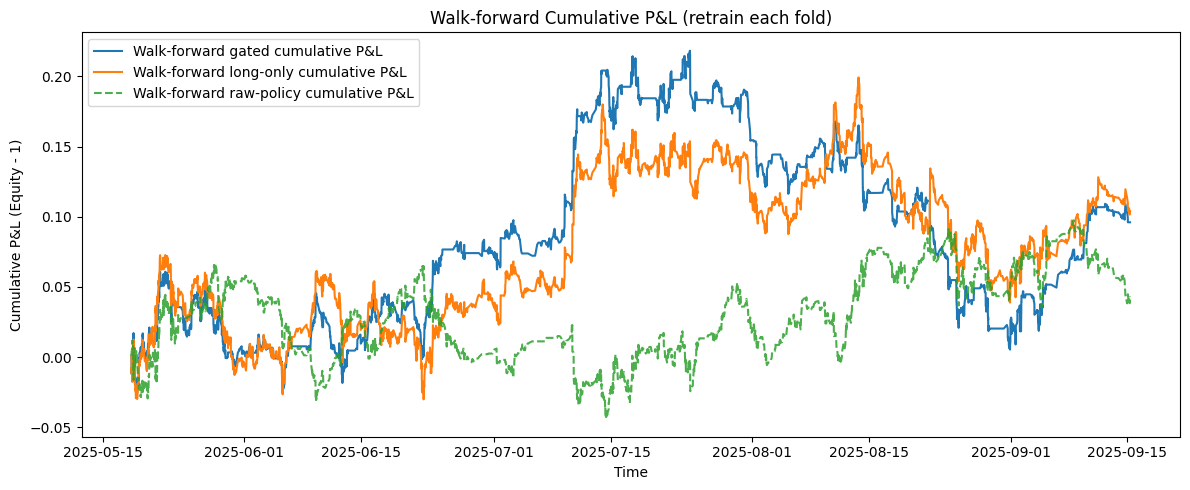

In [10]:
# ---- 7K) Walk-forward retrain + stitched final PnL ----
# Goal:
# 1) retrain on past-only window each fold
# 2) predict next rebalancing window
# 3) stitch fold PnL into one cumulative curve

USE_WALK_FORWARD_FINAL_PNL = True

# Data split to run walk-forward on
WF_SOURCE_SPLIT = "test"         # "oos" | "test"
WF_USE_PRE_SOURCE_HISTORY = True  # if True, use earlier history for train/val while testing only on WF_SOURCE_SPLIT

# Windowing
WF_STYLE = "rolling"            # "expanding" | "rolling"
WF_TRAIN_DAYS = 150                 # used when WF_STYLE == "rolling"
WF_VAL_DAYS = 14
WF_REBALANCE_DAYS = 3             # predict this next window each fold
WF_MIN_TRAIN_ROWS = 10_000
WF_MIN_VAL_ROWS = 30
WF_MAX_FOLDS = None               # None = run through full selected source split

# Auto-scale fold minimums for short OOS/test datasets
WF_AUTO_SCALE_MIN_ROWS = True
WF_MIN_TRAIN_ROWS_FLOOR = 700
WF_MIN_VAL_ROWS_FLOOR = 30
WF_MIN_TRAIN_ROWS_RATIO = 0.04
WF_MIN_VAL_ROWS_RATIO = 0.02

# Compute budget per fold (inherit baseline training setup by default)
WF_TOTAL_TIMESTEPS = int(globals().get("BASE_TOTAL_TIMESTEPS", 60_000))
WF_EVAL_FREQ = int(globals().get("EVAL_FREQ", 6_000))
WF_PATIENCE_EVALS = int(globals().get("PATIENCE_EVALS", 5))
WF_MIN_EVALS = int(globals().get("MIN_EVALS", 3))
WF_N_VAL_EPISODES = int(globals().get("N_VAL_EPISODES", 5))

# PPO settings (inherit baseline training setup by default)
WF_N_ENVS = int(globals().get("BASE_N_ENVS", 8))
WF_TOTAL_ROLLOUT = int(globals().get("BASE_TOTAL_ROLLOUT", 4096))
WF_HORIZON = int(globals().get("BASE_TRAIN_HORIZON", 2000))
WF_N_STEPS = max(32, int(WF_TOTAL_ROLLOUT // max(1, WF_N_ENVS)))
WF_NET_ARCH = list(globals().get("BASE_NET_ARCH", [256, 256]))
WF_DEVICE = str(globals().get("DEVICE", "cpu"))

WF_LR = float(globals().get("BASE_LR", 1e-4))
WF_BATCH_SIZE = int(globals().get("BASE_BATCH_SIZE", 512))
WF_GAMMA = float(globals().get("BASE_GAMMA", 0.99))
WF_GAE_LAMBDA = float(globals().get("BASE_GAE_LAMBDA", 0.95))
WF_CLIP_RANGE = float(globals().get("BASE_CLIP_RANGE", 0.1))
WF_VF_COEF = float(globals().get("BASE_VF_COEF", 0.8))
WF_TARGET_KL = float(globals().get("BASE_TARGET_KL", 0.01))

WF_USE_LONG_BIAS_GATE = USE_LONG_BIAS_GATE
WF_USE_ACTION_GATES = bool(WF_USE_LONG_BIAS_GATE or USE_CONFIDENCE_HOLD_GATE or USE_SHORT_CONFIDENCE_GATE)

# Validation-time action guardrails
WF_VAL_RAW_SHORT_FRAC_REJECT = 0.70
WF_VAL_RAW_LONG_FRAC_REJECT = 0.35
WF_VAL_RAW_LONG_FRAC_MAX_REJECT = 0.70

# Inference-time action mix controller (final deployment rollout)
WF_USE_INFERENCE_ACTION_MIX_CONTROLLER = True
WF_ACTION_MIX_POLICY = "deterministic_ranked"

# Regime-adaptive inference mix (by validation long-only pnl)
WF_ACTION_MIX_REGIME_ADAPTIVE = True
WF_ACTION_MIX_BULL_LONG_PNL = 0.03
WF_ACTION_MIX_BEAR_LONG_PNL = -0.03

# Bullish val: min_long=0.45, max_short=0.35, max_long=0.70
WF_ACTION_MIX_BULL_MIN_LONG_FRAC = 0.45
WF_ACTION_MIX_BULL_MAX_SHORT_FRAC = 0.35
WF_ACTION_MIX_BULL_MAX_LONG_FRAC = 0.70

# Bearish val: min_long=0.40, max_short=0.60, max_long=0.60
WF_ACTION_MIX_BEAR_MIN_LONG_FRAC = 0.40
WF_ACTION_MIX_BEAR_MAX_SHORT_FRAC = 0.60
WF_ACTION_MIX_BEAR_MAX_LONG_FRAC = 0.60

# Neutral val: min_long=0.40, max_short=0.60, max_long=0.65
WF_ACTION_MIX_NEUTRAL_MIN_LONG_FRAC = 0.40
WF_ACTION_MIX_NEUTRAL_MAX_SHORT_FRAC = 0.60
WF_ACTION_MIX_NEUTRAL_MAX_LONG_FRAC = 0.65

# Fallback static mix bounds (used when regime adaptation is disabled)
WF_ACTION_MIX_MIN_LONG_FRAC = WF_ACTION_MIX_NEUTRAL_MIN_LONG_FRAC
WF_ACTION_MIX_MAX_LONG_FRAC = WF_ACTION_MIX_NEUTRAL_MAX_LONG_FRAC
WF_ACTION_MIX_MAX_SHORT_FRAC = WF_ACTION_MIX_NEUTRAL_MAX_SHORT_FRAC

# Use probability-ranked forcing only when confidence is strong.
WF_ACTION_MIX_REQUIRE_CONFIDENCE_FOR_RANKED = True
WF_ACTION_MIX_MIN_TOP_PROB = 0.55
WF_ACTION_MIX_MIN_TOP_MARGIN = 0.12

# Tighten short usage when validation indicates an uptrend, even in neutral/bearish buckets.
WF_ACTION_MIX_UPTREND_ADJUST = True
WF_ACTION_MIX_UPTREND_LONG_PNL = 0.01
WF_ACTION_MIX_UPTREND_MIN_LONG_FRAC = 0.55
WF_ACTION_MIX_UPTREND_MAX_SHORT_FRAC = 0.25
WF_ACTION_MIX_UPTREND_MAX_LONG_FRAC = 0.70

WF_RELAXED_TARGET_ACTION_INTENSITY = 0.65
WF_RELAXED_MAX_HOLD_FRAC = 0.60
WF_RELAXED_MAX_SIDE_FRAC = 0.70
WF_VAL_OVERRIDE_RATE_DISABLE_HOLD_GATE = 0.55
WF_VAL_GATE_LIFT_DISABLE_HOLD_GATE = 0

# Benchmark-aware validation selector (align model choice with long-only excess objective)
WF_VAL_SCORE_USE_BENCHMARK_AWARE = True
WF_VAL_SCORE_CB_WEIGHT = 0.10
WF_VAL_SCORE_EXCESS_WEIGHT = 1.00
WF_VAL_SCORE_AGENT_WEIGHT = 0.25
WF_VAL_SCORE_GATE_LIFT_WEIGHT = 0.10
WF_VAL_SCORE_OVERRIDE_PENALTY = 0.10
WF_VAL_SCORE_CONSTRAINT_GAP_PENALTY = 0.50
WF_VAL_SCORE_COLLAPSE_PENALTY = 0.20
WF_VAL_SCORE_BULL_UNDERPERF_PENALTY = 0.50

# Fold-level deployment fallback: if validation benchmark-relative quality is poor,
# run long-only execution for that fold instead of deploying the selected model policy.
WF_FALLBACK_TO_LONG_ONLY_ON_BAD_VAL_EXCESS = True
WF_FALLBACK_BAD_VAL_EXCESS_THRESHOLD = -0.03
WF_FALLBACK_REQUIRE_POSITIVE_VAL_LONG_PNL = True

# Retry guardrails: retrain fold with a different seed when validation action mix looks regime-misaligned
WF_VAL_LONG_PNL_RETRY_THRESHOLD = 0.05
WF_VAL_RAW_LONG_FRAC_RETRY_THRESHOLD = 0.50
WF_VAL_RAW_SHORT_FRAC_RETRY_THRESHOLD = 0.70
WF_VAL_RETRY_MAX_ATTEMPTS = 4
# If True, always run exactly WF_VAL_RETRY_MAX_ATTEMPTS retries per fold (seed sweep),
# regardless of whether retry triggers are currently active.
WF_FORCE_FIXED_RETRIES = False
WF_VAL_RETRY_EARLY_STOP_ON_VALID = True
WF_VAL_RETRY_MIN_ACCEPTABLE_SCORE = -np.inf
WF_VAL_RETRY_SEED_STRIDE = 1000

# Warm-start + normalization carry across folds
WF_WARM_START = False
WF_WARM_START_SOURCE = "selected"   # "selected" | "final"
WF_CARRY_VECNORM = False
WF_RESET_NUM_TIMESTEPS_ON_WARM_START = False

# Conditional warm-start guardrails (applied on previous fold results)
WF_WARM_START_CONDITIONAL = True
WF_WARM_START_MIN_PREV_EXCESS_PNL = -0.01
WF_WARM_START_MAX_PREV_GATED_SHORT_FRAC = 0.70
WF_WARM_START_RESET_EVERY_FOLDS = 0   # disabled; use event-driven cold-start below
WF_EVENT_COLD_START_EXCESS_THRESHOLD = -0.05
WF_EVENT_COLD_START_CONSECUTIVE_FOLDS = 2

# VecNormalize carry decay: 1.0 = full carry, lower = faster forgetting of stale stats
WF_CARRY_VECNORM_DECAY = 0.95
WF_CARRY_VECNORM_DECAY_TO_FOLD = True  # blend carried stats toward current fold feature stats

# Run output isolation (avoid confusion across notebooks/experiments)
WF_ENFORCE_EMPTY_RUN_DIR = True
# Auto-run tag from notebook name; override manually when needed.
WF_RUN_TAG_OVERRIDE = ""  # e.g. "dec90" / "dec80"
if isinstance(WF_RUN_TAG_OVERRIDE, str) and WF_RUN_TAG_OVERRIDE.strip():
    WF_RUN_TAG = WF_RUN_TAG_OVERRIDE.strip()
else:
    WF_RUN_TAG = NOTEBOOK_STEM if ("NOTEBOOK_STEM" in locals()) else "notebook"


def _wf_apply_vecnorm_decay(vec_env, fold_df, state_cols, decay=1.0, blend_to_fold=True):
    d = float(decay)
    d = min(max(d, 0.0), 1.0)
    if d >= 0.999999:
        return "disabled"
    if (not hasattr(vec_env, "obs_rms")) or (vec_env.obs_rms is None):
        return "no_obs_rms"

    rms = vec_env.obs_rms
    old_count = float(getattr(rms, "count", 1.0))

    try:
        if blend_to_fold:
            cols = [c for c in state_cols if c in fold_df.columns]
            if cols and (np.size(rms.mean) == len(cols)):
                x = fold_df.loc[:, cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
                with np.errstate(invalid="ignore"):
                    mu = np.nanmean(x, axis=0)
                    var = np.nanvar(x, axis=0)
                mu = np.where(np.isfinite(mu), mu, rms.mean)
                var = np.where(np.isfinite(var) & (var > 1e-12), var, rms.var)
                rms.mean = d * rms.mean + (1.0 - d) * mu
                rms.var = d * rms.var + (1.0 - d) * var
            else:
                # fallback: shrink variance toward 1.0 if shape doesn't match
                rms.var = d * rms.var + (1.0 - d) * np.ones_like(rms.var)

        rms.var = np.maximum(rms.var, 1e-8)
        rms.count = max(1.0, old_count * d)
        return f"decay={d:.3f}, count={old_count:.1f}->{float(rms.count):.1f}"
    except Exception as e:
        return f"decay_failed: {e}"


def _wf_make_dc_env(df_):
    return DCEventTradingEnv(
        df_.reset_index(drop=True),
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
        turnover_penalty=TURNOVER_PENALTY,
        use_active_pnl_reward=USE_ACTIVE_PNL_REWARD,
        benchmark_pos=BENCHMARK_POS,
        use_step_loss_liquidation=USE_STEP_LOSS_LIQUIDATION,
        step_loss_liquidation_pct=STEP_LOSS_LIQUIDATION_PCT,
        use_step_take_profit_liquidation=USE_STEP_TAKE_PROFIT_LIQUIDATION,
        step_take_profit_liquidation_pct=STEP_TAKE_PROFIT_LIQUIDATION_PCT,
        use_stop_tp_exec_lag_price=USE_STOP_TP_EXEC_LAG_PRICE,
        stop_tp_lag_price_col=STOP_TP_LAG_PRICE_COL,
    )


def _wf_exec_log_from_rollout(rollout_df: pd.DataFrame, base_df: pd.DataFrame) -> pd.DataFrame:
    base = base_df.reset_index(drop=True)
    if "tradable_flag" in rollout_df.columns:
        trad = rollout_df[rollout_df["tradable_flag"]].copy().reset_index(drop=True)
    else:
        trad = rollout_df.copy().reset_index(drop=True)

    t_exec = max(0, len(trad) - 1)
    if t_exec == 0:
        return pd.DataFrame()

    entry_idx = trad["idx"].iloc[:t_exec].astype(int).to_numpy()
    exit_idx = trad["idx"].iloc[1:t_exec + 1].astype(int).to_numpy()

    max_i = len(base) - 1
    entry_idx = np.clip(entry_idx, 0, max_i)
    exit_idx = np.clip(exit_idx, 0, max_i)

    decision_time = pd.to_datetime(base.loc[entry_idx, "t_confirm"].values, errors="coerce")
    if "t_execute" in base.columns:
        entry_time = pd.to_datetime(base.loc[entry_idx, "t_execute"].values, errors="coerce")
        exit_time = pd.to_datetime(base.loc[exit_idx, "t_execute"].values, errors="coerce")
    else:
        entry_time = decision_time
        exit_time = pd.to_datetime(base.loc[exit_idx, "t_confirm"].values, errors="coerce")

    if "p_t_execute" in base.columns:
        entry_price = pd.to_numeric(base.loc[entry_idx, "p_t_execute"], errors="coerce").to_numpy(dtype=float)
        exit_price = pd.to_numeric(base.loc[exit_idx, "p_t_execute"], errors="coerce").to_numpy(dtype=float)
    else:
        entry_price = pd.to_numeric(base.loc[entry_idx, "p_t"], errors="coerce").to_numpy(dtype=float)
        exit_price = pd.to_numeric(base.loc[exit_idx, "p_t"], errors="coerce").to_numpy(dtype=float)

    pos_vec = pd.to_numeric(trad["pos"].iloc[:t_exec], errors="coerce").to_numpy(dtype=float)
    raw_action_vec = pd.to_numeric(
        trad["raw_action"].iloc[:t_exec] if "raw_action" in trad.columns else trad["action"].iloc[:t_exec],
        errors="coerce",
    ).to_numpy(dtype=float)
    auto_liq_vec = trad["auto_liquidated"].iloc[:t_exec].astype(bool).to_numpy() if "auto_liquidated" in trad.columns else np.zeros(t_exec, dtype=bool)
    auto_liq_reason_vec = trad["auto_liq_reason"].iloc[:t_exec].astype(str).to_numpy() if "auto_liq_reason" in trad.columns else np.array(["" for _ in range(t_exec)], dtype=object)
    auto_liq_open_ret_vec = pd.to_numeric(trad["auto_liq_open_trade_ret"].iloc[:t_exec], errors="coerce").to_numpy(dtype=float) if "auto_liq_open_trade_ret" in trad.columns else np.full(t_exec, np.nan, dtype=float)
    auto_liq_pnl_adjust_vec = pd.to_numeric(trad["auto_liq_pnl_adjust"].iloc[:t_exec], errors="coerce").to_numpy(dtype=float) if "auto_liq_pnl_adjust" in trad.columns else np.zeros(t_exec, dtype=float)
    stop_tp_exec_price_vec = pd.to_numeric(trad["stop_tp_exec_price"].iloc[:t_exec], errors="coerce").to_numpy(dtype=float) if "stop_tp_exec_price" in trad.columns else np.full(t_exec, np.nan, dtype=float)

    valid = np.isfinite(entry_price) & np.isfinite(exit_price) & np.isfinite(pos_vec) & np.isfinite(raw_action_vec) & (entry_price != 0.0)
    if not np.any(valid):
        return pd.DataFrame()

    entry_idx = entry_idx[valid]
    exit_idx = exit_idx[valid]
    decision_time = decision_time[valid]
    entry_time = entry_time[valid]
    exit_time = exit_time[valid]
    entry_price = entry_price[valid]
    exit_price = exit_price[valid]
    pos_vec = pos_vec[valid]
    raw_action_vec = raw_action_vec[valid].astype(int)
    auto_liq_vec = auto_liq_vec[valid]
    auto_liq_reason_vec = auto_liq_reason_vec[valid]
    auto_liq_open_ret_vec = auto_liq_open_ret_vec[valid]
    auto_liq_pnl_adjust_vec = auto_liq_pnl_adjust_vec[valid]
    stop_tp_exec_price_vec = stop_tp_exec_price_vec[valid]

    # Raw policy counterfactual at the same executable intervals.
    # Mapping: action 0=SHORT->-1, 1=HOLD->0, 2=LONG->+1
    raw_pos_vec = np.where(raw_action_vec == 0, -1.0, np.where(raw_action_vec == 2, 1.0, 0.0))

    ret_interval = (exit_price / entry_price) - 1.0
    gated_base_pnl_frac = pos_vec * ret_interval
    raw_pnl_frac = raw_pos_vec * ret_interval
    pnl_frac = gated_base_pnl_frac + auto_liq_pnl_adjust_vec

    out = pd.DataFrame({
        "idx_entry": entry_idx,
        "idx_exit": exit_idx,
        "decision_time": decision_time,
        "entry_time": entry_time,
        "exit_time": exit_time,
        "position": pos_vec,
        "raw_action": raw_action_vec,
        "raw_position": raw_pos_vec,
        "auto_liquidated": auto_liq_vec,
        "auto_liq_reason": auto_liq_reason_vec,
        "auto_liq_open_trade_ret": auto_liq_open_ret_vec,
        "auto_liq_pnl_adjust": auto_liq_pnl_adjust_vec,
        "stop_tp_exec_price": stop_tp_exec_price_vec,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "ret_interval": ret_interval,
        "gated_base_pnl_frac": gated_base_pnl_frac,
        "raw_pnl_frac": raw_pnl_frac,
        "pnl_frac": pnl_frac,
    })
    return out.reset_index(drop=True)


if USE_WALK_FORWARD_FINAL_PNL:
    wf_source_key = WF_SOURCE_SPLIT.lower().strip()
    if wf_source_key == "oos":
        if "oos_df" not in locals():
            raise RuntimeError("oos_df not found. Run OOS loading cell(s) first.")
        wf_eval_df = oos_df.copy()
    elif wf_source_key == "test":
        wf_eval_df = test_df.copy()
    else:
        raise ValueError(f"Unsupported WF_SOURCE_SPLIT: {WF_SOURCE_SPLIT}")

    if "t_confirm" not in wf_eval_df.columns:
        raise ValueError("Walk-forward requires t_confirm column")

    if WF_USE_PRE_SOURCE_HISTORY and ("df" in locals()) and isinstance(df, pd.DataFrame):
        if wf_source_key == "oos":
            wf_hist_df = pd.concat([df.copy(), wf_eval_df.copy()], ignore_index=True, sort=False)
        else:
            wf_hist_df = df.copy()
    else:
        wf_hist_df = wf_eval_df.copy()

    if "t_confirm" not in wf_hist_df.columns:
        raise ValueError("Walk-forward history dataframe requires t_confirm column")

    wf_eval_df = wf_eval_df.copy()
    wf_eval_df["t_confirm"] = pd.to_datetime(wf_eval_df["t_confirm"], errors="coerce")
    wf_eval_df = wf_eval_df.dropna(subset=["t_confirm"]).sort_values("t_confirm").reset_index(drop=True)

    wf_hist_df = wf_hist_df.copy()
    wf_hist_df["t_confirm"] = pd.to_datetime(wf_hist_df["t_confirm"], errors="coerce")
    wf_hist_df = wf_hist_df.dropna(subset=["t_confirm"]).sort_values("t_confirm").reset_index(drop=True)

    if len(wf_eval_df) == 0:
        raise ValueError("Walk-forward source dataframe is empty after timestamp cleanup")
    if len(wf_hist_df) == 0:
        raise ValueError("Walk-forward history dataframe is empty after timestamp cleanup")

    if WF_AUTO_SCALE_MIN_ROWS:
        _wf_auto_train = int(max(WF_MIN_TRAIN_ROWS_FLOOR, round(float(WF_MIN_TRAIN_ROWS_RATIO) * len(wf_eval_df))))
        _wf_auto_val = int(max(WF_MIN_VAL_ROWS_FLOOR, round(float(WF_MIN_VAL_ROWS_RATIO) * len(wf_eval_df))))
        WF_MIN_TRAIN_ROWS_EFFECTIVE = min(int(WF_MIN_TRAIN_ROWS), _wf_auto_train)
        WF_MIN_VAL_ROWS_EFFECTIVE = min(int(WF_MIN_VAL_ROWS), _wf_auto_val)
    else:
        WF_MIN_TRAIN_ROWS_EFFECTIVE = int(WF_MIN_TRAIN_ROWS)
        WF_MIN_VAL_ROWS_EFFECTIVE = int(WF_MIN_VAL_ROWS)

    wf_tag = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S_%f")
    wf_run_group = RUN_GROUP
    _wf_decay_tag = f"dec{int(round(100.0 * float(WF_CARRY_VECNORM_DECAY)))}"
    _wf_cfg_tag = f"ts{int(WF_TOTAL_TIMESTEPS)}_rb{int(WF_REBALANCE_DAYS)}"
    _wf_user_tag = str(WF_RUN_TAG).strip()
    _wf_suffix = f"_{_wf_user_tag}" if _wf_user_tag else ""
    WF_RUN_DIR = os.path.join(
        ".",
        "sb3_walkforward",
        f"{wf_run_group}_{wf_tag}_{WF_SOURCE_SPLIT}_{WF_STYLE}_{_wf_decay_tag}_{_wf_cfg_tag}{_wf_suffix}",
    )

    if os.path.exists(WF_RUN_DIR):
        _wf_existing_exec = os.path.join(WF_RUN_DIR, "walkforward_exec_log.csv")
        _wf_existing_fold = os.path.join(WF_RUN_DIR, "walkforward_fold_summary.csv")
        if WF_ENFORCE_EMPTY_RUN_DIR and (os.path.exists(_wf_existing_exec) or os.path.exists(_wf_existing_fold)):
            raise RuntimeError(
                f"WF_RUN_DIR already has prior outputs: {WF_RUN_DIR}. "
                "Change WF_RUN_TAG or disable WF_ENFORCE_EMPTY_RUN_DIR."
            )

    os.makedirs(WF_RUN_DIR, exist_ok=True)

    # Persist run config for auditability/repro tracking.
    import json as _json
    _wf_cfg = {
        "run_group": wf_run_group,
        "run_tag": _wf_user_tag,
        "source_split": WF_SOURCE_SPLIT,
        "style": WF_STYLE,
        "train_days": int(WF_TRAIN_DAYS),
        "val_days": int(WF_VAL_DAYS),
        "rebalance_days": int(WF_REBALANCE_DAYS),
        "total_timesteps": int(WF_TOTAL_TIMESTEPS),
        "warm_start": bool(WF_WARM_START),
        "warm_start_source": str(WF_WARM_START_SOURCE),
        "carry_vecnorm": bool(WF_CARRY_VECNORM),
        "carry_vecnorm_decay": float(WF_CARRY_VECNORM_DECAY),
        "carry_vecnorm_decay_to_fold": bool(WF_CARRY_VECNORM_DECAY_TO_FOLD),
        "seed": int(SEED),
    }
    with open(os.path.join(WF_RUN_DIR, "wf_run_config.json"), "w", encoding="utf-8") as _f:
        _json.dump(_wf_cfg, _f, indent=2)

    t_min = wf_eval_df["t_confirm"].min()
    t_max = wf_eval_df["t_confirm"].max()
    hist_t_min = wf_hist_df["t_confirm"].min()
    hist_t_max = wf_hist_df["t_confirm"].max()

    wf_style = str(WF_STYLE).lower().strip()
    if int(WF_REBALANCE_DAYS) <= 0:
        raise ValueError(f"WF_REBALANCE_DAYS must be > 0, got {WF_REBALANCE_DAYS}")

    wf_span_days = float((t_max - t_min) / pd.Timedelta(days=1))
    if (not np.isfinite(wf_span_days)) or (wf_span_days <= 0.0):
        raise ValueError(f"Walk-forward source span is invalid: t_min={t_min}, t_max={t_max}")

    wf_train_days_effective = int(WF_TRAIN_DAYS)
    if wf_style == "rolling":
        if WF_USE_PRE_SOURCE_HISTORY:
            hist_days_before_source = float((t_min - hist_t_min) / pd.Timedelta(days=1))
            if hist_days_before_source < float(WF_VAL_DAYS):
                raise ValueError(
                    "Insufficient pre-source history for validation window in walk-forward. "
                    f"history_before_source_days={hist_days_before_source:.2f}, val_days={WF_VAL_DAYS}. "
                    "Disable WF_USE_PRE_SOURCE_HISTORY or expand historical data."
                )
            if hist_days_before_source < float(WF_VAL_DAYS + wf_train_days_effective):
                print(
                    "[WF][WARN] Pre-source history is shorter than WF_TRAIN_DAYS + WF_VAL_DAYS; earliest folds will use shorter train windows.",
                    f"(history_before_source_days={hist_days_before_source:.2f}, requested_train_days={wf_train_days_effective}, val_days={WF_VAL_DAYS})",
                )
        else:
            max_train_days_for_one_fold = int(np.floor(max(0.0, wf_span_days - float(WF_VAL_DAYS) - float(WF_REBALANCE_DAYS))))
            if max_train_days_for_one_fold < 1:
                raise ValueError(
                    "WF source window is too short for rolling walk-forward. "
                    f"span_days={wf_span_days:.2f}, val_days={WF_VAL_DAYS}, rebalance_days={WF_REBALANCE_DAYS}. "
                    "Increase source span (e.g., larger test/oos window) or reduce WF_VAL_DAYS / WF_REBALANCE_DAYS."
                )
            if wf_train_days_effective > max_train_days_for_one_fold:
                print(
                    "[WF][WARN] Reducing WF_TRAIN_DAYS for this run:",
                    f"{wf_train_days_effective} -> {max_train_days_for_one_fold}",
                    f"(source span {wf_span_days:.2f} days)",
                )
                wf_train_days_effective = max_train_days_for_one_fold

    required_history_days = int(WF_VAL_DAYS + (wf_train_days_effective if wf_style == "rolling" else 1))
    cur_start = t_min
    step = pd.Timedelta(days=int(WF_REBALANCE_DAYS))

    # Dry-run fold sizing so min-row filters do not eliminate every fold on short windows.
    _probe_start = cur_start
    _probe_fold_id = 0
    _probe_train_rows = []
    _probe_val_rows = []

    while _probe_start < t_max:
        if (WF_MAX_FOLDS is not None) and (_probe_fold_id >= int(WF_MAX_FOLDS)):
            break

        _test_start = _probe_start
        _test_end = min(_probe_start + step, t_max + pd.Timedelta(seconds=1))
        _val_start = _test_start - pd.Timedelta(days=int(WF_VAL_DAYS))

        if wf_style == "rolling":
            _train_start = _val_start - pd.Timedelta(days=int(wf_train_days_effective))
        else:
            _train_start = hist_t_min

        _fold_train = wf_hist_df[(wf_hist_df["t_confirm"] >= _train_start) & (wf_hist_df["t_confirm"] < _val_start)]
        _fold_val = wf_hist_df[(wf_hist_df["t_confirm"] >= _val_start) & (wf_hist_df["t_confirm"] < _test_start)]
        _fold_test = wf_eval_df[(wf_eval_df["t_confirm"] >= _test_start) & (wf_eval_df["t_confirm"] < _test_end)]

        _probe_start = _probe_start + step
        if len(_fold_test) == 0:
            continue

        _probe_fold_id += 1
        _probe_train_rows.append(int(len(_fold_train)))
        _probe_val_rows.append(int(len(_fold_val)))

    if len(_probe_train_rows) == 0:
        raise RuntimeError(
            "Walk-forward found no candidate folds with non-empty test slices. "
            f"source_span_days={wf_span_days:.2f}, rebalance_days={WF_REBALANCE_DAYS}. "
            "Expand WF_SOURCE_SPLIT or reduce WF_REBALANCE_DAYS."
        )

    _max_train_probe = int(max(_probe_train_rows))
    _max_val_probe = int(max(_probe_val_rows))
    if WF_MIN_TRAIN_ROWS_EFFECTIVE > _max_train_probe:
        print(
            "[WF][WARN] Lowering effective train minimum for available folds:",
            f"{WF_MIN_TRAIN_ROWS_EFFECTIVE} -> {_max_train_probe}",
        )
        WF_MIN_TRAIN_ROWS_EFFECTIVE = _max_train_probe
    if WF_MIN_VAL_ROWS_EFFECTIVE > _max_val_probe:
        print(
            "[WF][WARN] Lowering effective val minimum for available folds:",
            f"{WF_MIN_VAL_ROWS_EFFECTIVE} -> {_max_val_probe}",
        )
        WF_MIN_VAL_ROWS_EFFECTIVE = _max_val_probe

    fold_exec_logs = []
    fold_rows = []
    fold_id = 0
    folds_considered = 0
    skipped_small = 0

    prev_model_path = None
    prev_vec_path = None
    prev_fold_excess_pnl_exec = np.nan
    prev_fold_gated_short_frac = np.nan
    _event_cold_start_bad_streak = 0

    print("Walk-forward config:")
    print("[WF] training does not read prior walkforward csv outputs; it writes a new run directory each execution.")
    print("source=", WF_SOURCE_SPLIT, "style=", wf_style, "rebalance_days=", WF_REBALANCE_DAYS)
    print("eval range:", t_min, "->", t_max, f"(span_days={wf_span_days:.2f})")
    print("history range:", hist_t_min, "->", hist_t_max)
    print("output dir:", WF_RUN_DIR)
    print(
        "effective fold mins:",
        f"train>={WF_MIN_TRAIN_ROWS_EFFECTIVE} (cfg={WF_MIN_TRAIN_ROWS}), "
        f"val>={WF_MIN_VAL_ROWS_EFFECTIVE} (cfg={WF_MIN_VAL_ROWS}), auto_scale={WF_AUTO_SCALE_MIN_ROWS}",
    )
    if wf_style == "rolling":
        print(
            "effective rolling train days:",
            int(wf_train_days_effective),
            f"(configured={int(WF_TRAIN_DAYS)}, use_pre_source_history={WF_USE_PRE_SOURCE_HISTORY})",
        )
    print(
        "warm-start:",
        f"enabled={WF_WARM_START}, source={WF_WARM_START_SOURCE}, reset_num_timesteps_on_warm_start={WF_RESET_NUM_TIMESTEPS_ON_WARM_START}, carry_vecnorm={WF_CARRY_VECNORM}",
    )
    print(
        "warm-start rules:",
        f"conditional={WF_WARM_START_CONDITIONAL}, min_prev_excess_pnl>{WF_WARM_START_MIN_PREV_EXCESS_PNL}, "
        f"max_prev_gated_short_frac<{WF_WARM_START_MAX_PREV_GATED_SHORT_FRAC}, event_cold_start_if_prev_excess_pnl<{WF_EVENT_COLD_START_EXCESS_THRESHOLD} for {WF_EVENT_COLD_START_CONSECUTIVE_FOLDS} folds",
    )
    est_folds = max(0, int(np.floor(wf_span_days / float(WF_REBALANCE_DAYS))) + 1)
    print("estimated folds (before min-row filtering):", int(est_folds))
    print("required history lookback days (train+val):", int(required_history_days))
    print(
        "probe fold row ranges:",
        f"train=[{int(min(_probe_train_rows))}, {int(max(_probe_train_rows))}],",
        f"val=[{int(min(_probe_val_rows))}, {int(max(_probe_val_rows))}]",
    )

    while cur_start < t_max:
        if (WF_MAX_FOLDS is not None) and (fold_id >= int(WF_MAX_FOLDS)):
            break

        fold_test_start = cur_start
        fold_test_end = min(cur_start + step, t_max + pd.Timedelta(seconds=1))
        fold_val_start = fold_test_start - pd.Timedelta(days=int(WF_VAL_DAYS))

        if wf_style == "rolling":
            fold_train_start = fold_val_start - pd.Timedelta(days=int(wf_train_days_effective))
        else:
            fold_train_start = hist_t_min

        fold_train = wf_hist_df[(wf_hist_df["t_confirm"] >= fold_train_start) & (wf_hist_df["t_confirm"] < fold_val_start)].copy()
        fold_val = wf_hist_df[(wf_hist_df["t_confirm"] >= fold_val_start) & (wf_hist_df["t_confirm"] < fold_test_start)].copy()
        fold_test = wf_eval_df[(wf_eval_df["t_confirm"] >= fold_test_start) & (wf_eval_df["t_confirm"] < fold_test_end)].copy()

        cur_start = cur_start + step

        if len(fold_test) == 0:
            continue

        folds_considered += 1
        if len(fold_train) < int(WF_MIN_TRAIN_ROWS_EFFECTIVE) or len(fold_val) < int(WF_MIN_VAL_ROWS_EFFECTIVE):
            skipped_small += 1
            continue

        fold_dir = os.path.join(WF_RUN_DIR, f"fold_{fold_id:03d}")
        fold_best_dir = os.path.join(fold_dir, "sb3_best")
        os.makedirs(fold_best_dir, exist_ok=True)

        fold_best_path = os.path.join(fold_best_dir, "best_model.zip")
        fold_final_path = os.path.join(fold_best_dir, "final_model.zip")
        fold_vec_path = os.path.join(fold_best_dir, "vecnormalize.pkl")

        print(f"\n[WF] fold={fold_id} train={len(fold_train)} val={len(fold_val)} test={len(fold_test)}")
        print("[WF] windows:",
              f"train[{fold_train['t_confirm'].min()} -> {fold_train['t_confirm'].max()}],",
              f"val[{fold_val['t_confirm'].min()} -> {fold_val['t_confirm'].max()}],",
              f"test[{fold_test['t_confirm'].min()} -> {fold_test['t_confirm'].max()}]")

        def _make_train_env(rank: int, seed_base: int = SEED):
            def _init():
                env = _wf_make_dc_env(fold_train)
                env = RandomWindowWrapper(env, horizon=WF_HORIZON, seed=seed_base + fold_id * 100 + rank)
                return env
            return _init

        def _make_val_env(seed_base: int = SEED + 1):
            def _init():
                env = _wf_make_dc_env(fold_val)
                env = RandomWindowWrapper(env, horizon=WF_HORIZON, seed=seed_base + fold_id)
                return env
            return _init

        fold_train_env = DummyVecEnv([_make_train_env(i) for i in range(WF_N_ENVS)])
        _vecnorm_carried_from = ""
        _vecnorm_decay_msg = ""
        if WF_CARRY_VECNORM and prev_vec_path and os.path.exists(prev_vec_path):
            try:
                fold_train_env = VecNormalize.load(prev_vec_path, fold_train_env)
                fold_train_env.training = True
                fold_train_env.norm_reward = False
                _vecnorm_carried_from = str(prev_vec_path)
                print(f"[WF] carried VecNormalize from prior fold: {prev_vec_path}")

                _vecnorm_decay_msg = _wf_apply_vecnorm_decay(
                    fold_train_env,
                    fold_train,
                    STATE_COLS_SAFE,
                    decay=WF_CARRY_VECNORM_DECAY,
                    blend_to_fold=WF_CARRY_VECNORM_DECAY_TO_FOLD,
                )
                if _vecnorm_decay_msg and _vecnorm_decay_msg != "disabled":
                    print(f"[WF] applied VecNormalize decay: {_vecnorm_decay_msg}")
            except Exception as _e:
                print(f"[WF][WARN] failed to load prior VecNormalize ({prev_vec_path}): {_e}. Using fresh stats.")
                fold_train_env = VecNormalize(fold_train_env, training=True, norm_obs=True, norm_reward=False, clip_obs=10.0)
        else:
            fold_train_env = VecNormalize(fold_train_env, training=True, norm_obs=True, norm_reward=False, clip_obs=10.0)

        fold_val_env = DummyVecEnv([_make_val_env()])
        fold_val_env = VecNormalize(fold_val_env, training=False, norm_obs=True, norm_reward=False, clip_obs=10.0)
        fold_val_env.obs_rms = fold_train_env.obs_rms

        sync_cb = SyncVecNormalizeCallback(fold_train_env, fold_val_env)
        ent_cb = EntCoefScheduleCallback(
            start=float(ENT_COEF_START),
            end=float(ENT_COEF_END),
        )
        risk_cb = ExcessReturnEvalCallback(
            train_env=fold_train_env,
            eval_env=fold_val_env,
            eval_freq=int(WF_EVAL_FREQ),
            n_eval_episodes=int(WF_N_VAL_EPISODES),
            patience_evals=int(WF_PATIENCE_EVALS),
            min_evals=int(WF_MIN_EVALS),
            save_path=fold_best_dir,
            deterministic=True,
            eval_mode=str(RISK_EVAL_MODE),
            guardrail_penalty=float(RISK_SCORE_GUARDRAIL_PENALTY),
            reject_if_nonpositive_excess=bool(REJECT_NONPOS_EXCESS_CHECKPOINT),
            verbose=0,
        )

        _warm_start_from = ""
        _warm_start_reason = ""
        _use_warm_start = bool(WF_WARM_START and prev_model_path and os.path.exists(prev_model_path))
        _event_cold_start_active = bool(
            int(WF_EVENT_COLD_START_CONSECUTIVE_FOLDS) > 0
            and _event_cold_start_bad_streak >= int(WF_EVENT_COLD_START_CONSECUTIVE_FOLDS)
        )

        if _use_warm_start and bool(WF_WARM_START_CONDITIONAL):
            _ws_reasons = []

            _prev_ex = float(prev_fold_excess_pnl_exec) if np.isfinite(prev_fold_excess_pnl_exec) else np.nan
            _prev_short = float(prev_fold_gated_short_frac) if np.isfinite(prev_fold_gated_short_frac) else np.nan

            if (not np.isfinite(_prev_ex)) or (_prev_ex <= float(WF_WARM_START_MIN_PREV_EXCESS_PNL)):
                _ws_reasons.append(f"prev_excess_pnl={_prev_ex} not > {float(WF_WARM_START_MIN_PREV_EXCESS_PNL)}")

            if (not np.isfinite(_prev_short)) or (_prev_short >= float(WF_WARM_START_MAX_PREV_GATED_SHORT_FRAC)):
                _ws_reasons.append(f"prev_gated_short_frac={_prev_short} not < {float(WF_WARM_START_MAX_PREV_GATED_SHORT_FRAC)}")

            if _event_cold_start_active:
                _ws_reasons.append(
                    f"event_cold_start_prev_excess_pnl<{float(WF_EVENT_COLD_START_EXCESS_THRESHOLD):+.6f}_for_{int(WF_EVENT_COLD_START_CONSECUTIVE_FOLDS)}_consecutive_folds"
                )

            if _ws_reasons:
                _use_warm_start = False
                _warm_start_reason = "blocked: " + " | ".join(_ws_reasons)

        if _use_warm_start:
            try:
                fold_model = PPO.load(prev_model_path, env=fold_train_env, device=WF_DEVICE)
                _warm_start_from = str(prev_model_path)
                _warm_start_reason = "used"
                print(f"[WF] warm-started model from prior fold: {prev_model_path}")
            except Exception as _e:
                print(f"[WF][WARN] failed warm-start load ({prev_model_path}): {_e}. Training fold from scratch.")
                _use_warm_start = False
                _warm_start_reason = f"load_failed: {_e}"

        if not _use_warm_start:
            if not _warm_start_reason:
                _warm_start_reason = "disabled_or_missing_prior_model"
            print(f"[WF] warm-start skipped: {_warm_start_reason}")
            fold_model = PPO(
                "MlpPolicy",
                fold_train_env,
                policy_kwargs=dict(net_arch=WF_NET_ARCH),
                verbose=0,
                device=WF_DEVICE,
                learning_rate=WF_LR,
                n_steps=WF_N_STEPS,
                batch_size=WF_BATCH_SIZE,
                gamma=WF_GAMMA,
                gae_lambda=WF_GAE_LAMBDA,
                ent_coef=float(ENT_COEF_START),
                clip_range=WF_CLIP_RANGE,
                vf_coef=WF_VF_COEF,
                target_kl=WF_TARGET_KL,
                seed=int(SEED) + fold_id,
            )

        fold_model.learn(
            total_timesteps=int(WF_TOTAL_TIMESTEPS),
            callback=[sync_cb, ent_cb, risk_cb],
            reset_num_timesteps=(not _use_warm_start) or bool(WF_RESET_NUM_TIMESTEPS_ON_WARM_START),
        )

        fold_model.save(fold_final_path)
        fold_train_env.save(fold_vec_path)
        if not os.path.exists(fold_best_path):
            fold_model.save(fold_best_path)

        selected_model_path = fold_best_path if os.path.exists(fold_best_path) else fold_final_path

        _fold_hold_gate_enabled_for_test = bool(USE_CONFIDENCE_HOLD_GATE)
        _fold_short_gate_enabled_for_test = bool(USE_SHORT_CONFIDENCE_GATE)
        _val_raw_short_frac = np.nan
        _val_raw_long_frac = np.nan
        _val_override_rate = np.nan
        _val_gate_lift_pnl = np.nan
        _val_long_pnl = np.nan
        _val_retrain_attempts = 0
        _val_checkpoint_rejected = False
        _val_checkpoint_reject_reason = ""

        def _wf_build_eval_model(_model_path: str, _env, _hold_gate_enabled: bool, _short_gate_enabled: bool):
            _m = PPO.load(_model_path, env=_env, device=WF_DEVICE)
            if WF_USE_ACTION_GATES:
                _m = LongBiasModelWrapper(
                    _m,
                    long_bias_enabled=bool(WF_USE_LONG_BIAS_GATE),
                    hold_switch_margin=float(LONG_BIAS_HOLD_SWITCH_MARGIN),
                    hold_min_prob=float(LONG_BIAS_HOLD_MIN_PROB),
                    short_switch_margin=float(LONG_BIAS_SHORT_SWITCH_MARGIN),
                    short_min_prob=float(LONG_BIAS_SHORT_MIN_PROB),
                    confidence_hold_enabled=bool(_hold_gate_enabled),
                    confidence_hold_min_top_prob=float(CONF_HOLD_MIN_TOP_PROB),
                    confidence_hold_min_margin=float(CONF_HOLD_MIN_MARGIN),
                    short_confidence_enabled=bool(_short_gate_enabled),
                    short_confidence_min_prob=float(SHORT_CONF_MIN_PROB),
                    short_confidence_min_margin=float(SHORT_CONF_MIN_MARGIN),
                )
            return _m

        def _wf_eval_val_gate_metrics(_model_path: str, _hold_gate_enabled: bool, _short_gate_enabled: bool):
            _val_env = DummyVecEnv([lambda: _wf_make_dc_env(fold_val)])
            _val_env = VecNormalize(_val_env, training=False, norm_obs=True, norm_reward=False, clip_obs=10.0)
            _val_env.obs_rms = fold_train_env.obs_rms

            _model = _wf_build_eval_model(_model_path, _val_env, _hold_gate_enabled, _short_gate_enabled)
            _rollout, _, _ = evaluate_with_action_stats(_model, _val_env, deterministic=True)

            _raw_short = np.nan
            _raw_long = np.nan
            _ovr_rate = np.nan
            _gate_lift = np.nan
            _long_pnl = np.nan
            _agent_pnl = np.nan
            _excess_pnl = np.nan

            if len(_rollout):
                _raw_vc = _rollout["raw_action"].value_counts(normalize=True)
                _raw_short = float(_raw_vc.get(0, 0.0))
                _raw_long = float(_raw_vc.get(2, 0.0))

                _n = int(len(_rollout))
                _n_ovr = int(pd.to_numeric(_rollout.get("gate_overrode", 0), errors="coerce").fillna(0).astype(int).sum()) if _n else 0
                _ovr_rate = (float(_n_ovr) / float(_n)) if _n else np.nan

                _val_exec = _wf_exec_log_from_rollout(_rollout, fold_val)
                if len(_val_exec):
                    _g = pd.to_numeric(_val_exec["pnl_frac"], errors="coerce").to_numpy(dtype=float)
                    _r = pd.to_numeric(_val_exec.get("raw_pnl_frac", np.nan), errors="coerce").to_numpy(dtype=float)
                    _l = pd.to_numeric(_val_exec.get("ret_interval", np.nan), errors="coerce").to_numpy(dtype=float)
                    _vg = np.isfinite(_g)
                    _vr = np.isfinite(_r)
                    _vl = np.isfinite(_l)

                    _g_pnl = np.nan
                    if np.any(_vg):
                        _g_pnl = float(np.prod(1.0 + _g[_vg]) - 1.0)
                        _agent_pnl = float(_g_pnl)

                    if np.any(_vg) and np.any(_vr):
                        _r_pnl = float(np.prod(1.0 + _r[_vr]) - 1.0)
                        _gate_lift = float(_g_pnl - _r_pnl)

                    if np.any(_vl):
                        _long_pnl = float(np.prod(1.0 + _l[_vl]) - 1.0)

                    if np.isfinite(_agent_pnl) and np.isfinite(_long_pnl):
                        _excess_pnl = float(_agent_pnl - _long_pnl)

            _val_env.close()
            return _raw_short, _raw_long, _ovr_rate, _gate_lift, _long_pnl, _agent_pnl, _excess_pnl

        _val_raw_short_frac, _val_raw_long_frac, _val_override_rate, _val_gate_lift_pnl, _val_long_pnl, _val_agent_pnl, _val_excess_pnl = _wf_eval_val_gate_metrics(
            selected_model_path,
            _fold_hold_gate_enabled_for_test,
            _fold_short_gate_enabled_for_test,
        )

        def _wf_score_to_key(_score: float):
            return float(_score) if np.isfinite(_score) else -1e18

        def _wf_resolve_val_score(
            _cb_score: float,
            _raw_short: float,
            _raw_long: float,
            _ovr_rate: float,
            _gate_lift: float,
            _long_pnl: float,
            _agent_pnl: float,
            _excess_pnl: float,
        ):
            _rs = float(_raw_short) if np.isfinite(_raw_short) else 1.0
            _rl = float(_raw_long) if np.isfinite(_raw_long) else 0.0
            _ov = float(_ovr_rate) if np.isfinite(_ovr_rate) else 1.0
            _gl = float(_gate_lift) if np.isfinite(_gate_lift) else 0.0
            _lp = float(_long_pnl) if np.isfinite(_long_pnl) else 0.0
            _ap = float(_agent_pnl) if np.isfinite(_agent_pnl) else 0.0
            _xp = float(_excess_pnl) if np.isfinite(_excess_pnl) else float(_ap - _lp)

            _short_gap = max(0.0, _rs - float(WF_VAL_RAW_SHORT_FRAC_REJECT))
            _long_low_gap = max(0.0, float(WF_VAL_RAW_LONG_FRAC_REJECT) - _rl)
            _long_high_gap = max(0.0, _rl - float(WF_VAL_RAW_LONG_FRAC_MAX_REJECT))
            _constraint_gap = float(_short_gap + _long_low_gap + _long_high_gap)

            _hold_frac = float(max(0.0, 1.0 - (_rs + _rl)))
            _side_max = float(max(_rs, _rl))
            _collapse_pen = float(
                max(0.0, _hold_frac - float(WF_RELAXED_MAX_HOLD_FRAC))
                + max(0.0, _side_max - float(WF_RELAXED_MAX_SIDE_FRAC))
            )

            if bool(WF_VAL_SCORE_USE_BENCHMARK_AWARE):
                _cb = float(_cb_score) if np.isfinite(_cb_score) else 0.0
                _score = (
                    float(WF_VAL_SCORE_EXCESS_WEIGHT) * _xp
                    + float(WF_VAL_SCORE_AGENT_WEIGHT) * _ap
                    + float(WF_VAL_SCORE_CB_WEIGHT) * _cb
                    + float(WF_VAL_SCORE_GATE_LIFT_WEIGHT) * _gl
                    - float(WF_VAL_SCORE_OVERRIDE_PENALTY) * _ov
                    - float(WF_VAL_SCORE_CONSTRAINT_GAP_PENALTY) * _constraint_gap
                    - float(WF_VAL_SCORE_COLLAPSE_PENALTY) * _collapse_pen
                )
                if (_lp > float(WF_VAL_LONG_PNL_RETRY_THRESHOLD)) and (_xp < 0.0):
                    _score -= float(WF_VAL_SCORE_BULL_UNDERPERF_PENALTY) * abs(_xp)
                return float(_score)

            if np.isfinite(_cb_score):
                return float(_cb_score)

            _score_fb = (
                (1.5 * _rl)
                - (1.5 * _rs)
                + (0.5 * _gl)
                - (0.25 * _ov)
                + (0.25 * np.sign(_lp) * (_rl - _rs))
            )
            return float(_score_fb)

        def _wf_copy_file(_src: str, _dst: str):
            try:
                if (not _src) or (not os.path.exists(_src)):
                    return False
                with open(_src, "rb") as _fi, open(_dst, "wb") as _fo:
                    _fo.write(_fi.read())
                return True
            except Exception as _e:
                print(f"[WF][WARN] failed to copy artifact: {_src} -> {_dst}: {_e}")
                return False

        def _wf_snapshot_best_candidate(_model_src: str, _final_src: str, _vec_src: str):
            _wf_copy_file(_model_src, _best_candidate_model_path)
            _wf_copy_file(_final_src, _best_candidate_final_path)
            _wf_copy_file(_vec_src, _best_candidate_vec_path)

        def _wf_snapshot_best_valid_candidate(_model_src: str, _final_src: str, _vec_src: str):
            _wf_copy_file(_model_src, _best_valid_candidate_model_path)
            _wf_copy_file(_final_src, _best_valid_candidate_final_path)
            _wf_copy_file(_vec_src, _best_valid_candidate_vec_path)

        def _wf_snapshot_best_relaxed_candidate(_model_src: str, _final_src: str, _vec_src: str):
            _wf_copy_file(_model_src, _best_relaxed_candidate_model_path)
            _wf_copy_file(_final_src, _best_relaxed_candidate_final_path)
            _wf_copy_file(_vec_src, _best_relaxed_candidate_vec_path)

        def _wf_candidate_is_valid(_raw_short: float, _raw_long: float, _long_pnl: float):
            if not (
                np.isfinite(_raw_short)
                and (_raw_short <= float(WF_VAL_RAW_SHORT_FRAC_REJECT))
            ):
                return False
            if not (
                np.isfinite(_raw_long)
                and (_raw_long >= float(WF_VAL_RAW_LONG_FRAC_REJECT))
            ):
                return False
            if not (
                np.isfinite(_raw_long)
                and (_raw_long <= float(WF_VAL_RAW_LONG_FRAC_MAX_REJECT))
            ):
                return False

            # In strongly bullish validation regimes, require candidate alignment
            # (sufficient LONG participation and non-short-dominant mix).
            if np.isfinite(_long_pnl) and (_long_pnl > float(WF_VAL_LONG_PNL_RETRY_THRESHOLD)):
                if not np.isfinite(_raw_long):
                    return False
                if _raw_long < float(WF_VAL_RAW_LONG_FRAC_RETRY_THRESHOLD):
                    return False
                if np.isfinite(_raw_short) and (_raw_short > _raw_long):
                    return False

            return True

        def _wf_hard_reject_reasons(_raw_short: float, _raw_long: float):
            _reasons = []
            if (not np.isfinite(_raw_short)) or (_raw_short > float(WF_VAL_RAW_SHORT_FRAC_REJECT)):
                _reasons.append(
                    f"val_raw_short_frac={_raw_short:.4f} > {float(WF_VAL_RAW_SHORT_FRAC_REJECT):.4f}"
                )
            if (not np.isfinite(_raw_long)) or (_raw_long < float(WF_VAL_RAW_LONG_FRAC_REJECT)):
                _reasons.append(
                    f"val_raw_long_frac={_raw_long:.4f} < {float(WF_VAL_RAW_LONG_FRAC_REJECT):.4f}"
                )
            if (not np.isfinite(_raw_long)) or (_raw_long > float(WF_VAL_RAW_LONG_FRAC_MAX_REJECT)):
                _reasons.append(
                    f"val_raw_long_frac={_raw_long:.4f} > {float(WF_VAL_RAW_LONG_FRAC_MAX_REJECT):.4f}"
                )
            return _reasons

        def _wf_constraint_gap(_raw_short: float, _raw_long: float):
            _short_gap = (
                max(0.0, float(_raw_short) - float(WF_VAL_RAW_SHORT_FRAC_REJECT))
                if np.isfinite(_raw_short) else 1.0
            )
            _long_low_gap = (
                max(0.0, float(WF_VAL_RAW_LONG_FRAC_REJECT) - float(_raw_long))
                if np.isfinite(_raw_long) else float(WF_VAL_RAW_LONG_FRAC_REJECT)
            )
            _long_high_gap = (
                max(0.0, float(_raw_long) - float(WF_VAL_RAW_LONG_FRAC_MAX_REJECT))
                if np.isfinite(_raw_long) else 1.0
            )
            return float(_short_gap + _long_low_gap + _long_high_gap)

        def _wf_hold_frac(_raw_short: float, _raw_long: float):
            _s = float(_raw_short) if np.isfinite(_raw_short) else 1.0
            _l = float(_raw_long) if np.isfinite(_raw_long) else 0.0
            _s = min(max(_s, 0.0), 1.0)
            _l = min(max(_l, 0.0), 1.0)
            return float(max(0.0, 1.0 - (_s + _l)))

        def _wf_action_intensity(_raw_short: float, _raw_long: float):
            _s = float(_raw_short) if np.isfinite(_raw_short) else 1.0
            _l = float(_raw_long) if np.isfinite(_raw_long) else 0.0
            _s = min(max(_s, 0.0), 1.0)
            _l = min(max(_l, 0.0), 1.0)
            return float(_s + _l)

        def _wf_collapse_penalty(_raw_short: float, _raw_long: float):
            _s = float(_raw_short) if np.isfinite(_raw_short) else 1.0
            _l = float(_raw_long) if np.isfinite(_raw_long) else 0.0
            _s = min(max(_s, 0.0), 1.0)
            _l = min(max(_l, 0.0), 1.0)
            _h = _wf_hold_frac(_s, _l)
            _side_max = max(_s, _l)
            _hold_pen = max(0.0, _h - float(WF_RELAXED_MAX_HOLD_FRAC))
            _side_pen = max(0.0, _side_max - float(WF_RELAXED_MAX_SIDE_FRAC))
            return float(_hold_pen + _side_pen)

        def _wf_relaxed_select_key(_raw_short: float, _raw_long: float, _val_score: float):
            # Priority:
            # 1) smallest hard-constraint gap
            # 2) lowest collapse penalty (HOLD-heavy or one-sided concentration)
            # 3) closest to target action intensity (avoid over/under-trading collapse)
            # 4) better val score
            _gap = _wf_constraint_gap(_raw_short, _raw_long)
            _collapse = _wf_collapse_penalty(_raw_short, _raw_long)
            _intensity = _wf_action_intensity(_raw_short, _raw_long)
            _intensity_dev = abs(_intensity - float(WF_RELAXED_TARGET_ACTION_INTENSITY))
            return (
                _gap,
                _collapse,
                _intensity_dev,
                -_wf_score_to_key(_val_score),
            )

        def _wf_retry_reasons(_raw_short: float, _raw_long: float, _long_pnl: float):
            _reasons = []
            if (
                np.isfinite(_long_pnl)
                and np.isfinite(_raw_long)
                and (_long_pnl > float(WF_VAL_LONG_PNL_RETRY_THRESHOLD))
                and (_raw_long < float(WF_VAL_RAW_LONG_FRAC_RETRY_THRESHOLD))
            ):
                _reasons.append(
                    f"val_long_pnl={_long_pnl:+.6f} > {float(WF_VAL_LONG_PNL_RETRY_THRESHOLD):+.6f} "
                    f"and val_raw_long_frac={_raw_long:.4f} < {float(WF_VAL_RAW_LONG_FRAC_RETRY_THRESHOLD):.4f}"
                )
            if (
                np.isfinite(_raw_long)
                and (_raw_long > float(WF_VAL_RAW_LONG_FRAC_MAX_REJECT))
            ):
                _reasons.append(
                    f"val_raw_long_frac={_raw_long:.4f} > {float(WF_VAL_RAW_LONG_FRAC_MAX_REJECT):.4f}"
                )
            if (
                np.isfinite(_raw_short)
                and (_raw_short > float(WF_VAL_RAW_SHORT_FRAC_RETRY_THRESHOLD))
            ):
                _reasons.append(
                    f"val_raw_short_frac={_raw_short:.4f} > {float(WF_VAL_RAW_SHORT_FRAC_RETRY_THRESHOLD):.4f}"
                )
            return _reasons

        _selected_vec_path = fold_vec_path
        _selected_final_model_path = fold_final_path
        _best_candidate_model_path = os.path.join(fold_best_dir, "best_candidate_model.zip")
        _best_candidate_final_path = os.path.join(fold_best_dir, "best_candidate_final_model.zip")
        _best_candidate_vec_path = os.path.join(fold_best_dir, "best_candidate_vecnormalize.pkl")
        _best_valid_candidate_model_path = os.path.join(fold_best_dir, "best_valid_candidate_model.zip")
        _best_valid_candidate_final_path = os.path.join(fold_best_dir, "best_valid_candidate_final_model.zip")
        _best_valid_candidate_vec_path = os.path.join(fold_best_dir, "best_valid_candidate_vecnormalize.pkl")
        _best_relaxed_candidate_model_path = os.path.join(fold_best_dir, "best_relaxed_candidate_model.zip")
        _best_relaxed_candidate_final_path = os.path.join(fold_best_dir, "best_relaxed_candidate_final_model.zip")
        _best_relaxed_candidate_vec_path = os.path.join(fold_best_dir, "best_relaxed_candidate_vecnormalize.pkl")

        _initial_val_score = _wf_resolve_val_score(
            float(getattr(risk_cb, "best_score", np.nan)),
            _val_raw_short_frac,
            _val_raw_long_frac,
            _val_override_rate,
            _val_gate_lift_pnl,
            _val_long_pnl,
            _val_agent_pnl,
            _val_excess_pnl,
        )
        _best_val_score = _initial_val_score
        _best_val_score_key = _wf_score_to_key(_initial_val_score)
        _best_val_raw_short_frac = _val_raw_short_frac
        _best_val_raw_long_frac = _val_raw_long_frac
        _best_val_override_rate = _val_override_rate
        _best_val_gate_lift_pnl = _val_gate_lift_pnl
        _best_val_long_pnl = _val_long_pnl
        _best_val_agent_pnl = _val_agent_pnl
        _best_val_excess_pnl = _val_excess_pnl
        _best_relaxed_found = False
        _best_relaxed_select_key = (np.inf, np.inf, np.inf)
        _best_relaxed_val_score = np.nan
        _best_relaxed_val_raw_short_frac = np.nan
        _best_relaxed_val_raw_long_frac = np.nan
        _best_relaxed_val_override_rate = np.nan
        _best_relaxed_val_gate_lift_pnl = np.nan
        _best_relaxed_val_long_pnl = np.nan
        _best_relaxed_val_agent_pnl = np.nan
        _best_relaxed_val_excess_pnl = np.nan
        _best_valid_found = False
        _best_valid_val_score = -np.inf
        _best_valid_val_score_key = -1e18
        _best_valid_val_raw_short_frac = np.nan
        _best_valid_val_raw_long_frac = np.nan
        _best_valid_val_override_rate = np.nan
        _best_valid_val_gate_lift_pnl = np.nan
        _best_valid_val_long_pnl = np.nan
        _best_valid_val_agent_pnl = np.nan
        _best_valid_val_excess_pnl = np.nan

        _wf_snapshot_best_candidate(selected_model_path, fold_final_path, fold_vec_path)
        _best_relaxed_found = True
        _best_relaxed_select_key = _wf_relaxed_select_key(_val_raw_short_frac, _val_raw_long_frac, _initial_val_score)
        _best_relaxed_val_score = _initial_val_score
        _best_relaxed_val_raw_short_frac = _val_raw_short_frac
        _best_relaxed_val_raw_long_frac = _val_raw_long_frac
        _best_relaxed_val_override_rate = _val_override_rate
        _best_relaxed_val_gate_lift_pnl = _val_gate_lift_pnl
        _best_relaxed_val_long_pnl = _val_long_pnl
        _wf_snapshot_best_relaxed_candidate(selected_model_path, fold_final_path, fold_vec_path)
        if _wf_candidate_is_valid(_val_raw_short_frac, _val_raw_long_frac, _val_long_pnl):
            _best_valid_found = True
            _best_valid_val_score = _initial_val_score
            _best_valid_val_score_key = _wf_score_to_key(_initial_val_score)
            _best_valid_val_raw_short_frac = _val_raw_short_frac
            _best_valid_val_raw_long_frac = _val_raw_long_frac
            _best_valid_val_override_rate = _val_override_rate
            _best_valid_val_gate_lift_pnl = _val_gate_lift_pnl
            _best_valid_val_long_pnl = _val_long_pnl
            _best_valid_val_agent_pnl = _val_agent_pnl
            _best_valid_val_excess_pnl = _val_excess_pnl
            _wf_snapshot_best_valid_candidate(selected_model_path, fold_final_path, fold_vec_path)


        _val_retry_reasons = _wf_retry_reasons(_val_raw_short_frac, _val_raw_long_frac, _val_long_pnl)
        _force_seed_sweep_retries = bool(_event_cold_start_active)
        _force_fixed_retries = bool(WF_FORCE_FIXED_RETRIES)
        _retry_max_attempts = int(WF_VAL_RETRY_MAX_ATTEMPTS)
        if _force_fixed_retries and (_retry_max_attempts > 0):
            print(
                f"[WF] fold={fold_id} fixed retry budget enabled: attempts={_retry_max_attempts}"
            )
        while _val_retrain_attempts < _retry_max_attempts:
            _retry_should_run = bool(_val_retry_reasons) or _force_seed_sweep_retries or _force_fixed_retries
            if not _retry_should_run:
                break
            _val_retrain_attempts += 1
            _retry_seed = int(SEED) + fold_id + _val_retrain_attempts * int(WF_VAL_RETRY_SEED_STRIDE)
            _retry_reason_txt = " | ".join(_val_retry_reasons) if _val_retry_reasons else ""
            if _force_fixed_retries:
                _retry_reason_txt = (
                    "fixed_retry_budget"
                    if not _retry_reason_txt
                    else f"fixed_retry_budget | {_retry_reason_txt}"
                )
            if _force_seed_sweep_retries:
                _retry_reason_txt = (
                    "event_cold_start_forced_seed_sweep"
                    if not _retry_reason_txt
                    else f"event_cold_start_forced_seed_sweep | {_retry_reason_txt}"
                )
            print(
                f"[WF] fold={fold_id} retry={_val_retrain_attempts}: {_retry_reason_txt}; "
                f"retraining with seed={_retry_seed}"
            )

            try:
                fold_val_env.close()
            except Exception:
                pass
            try:
                fold_train_env.close()
            except Exception:
                pass

            fold_train_env = DummyVecEnv([_make_train_env(i, seed_base=_retry_seed) for i in range(WF_N_ENVS)])
            _vecnorm_carried_from = ""
            _vecnorm_decay_msg = ""
            if WF_CARRY_VECNORM and prev_vec_path and os.path.exists(prev_vec_path):
                try:
                    fold_train_env = VecNormalize.load(prev_vec_path, fold_train_env)
                    fold_train_env.training = True
                    fold_train_env.norm_reward = False
                    _vecnorm_carried_from = str(prev_vec_path)
                    print(f"[WF] carried VecNormalize from prior fold: {prev_vec_path}")

                    _vecnorm_decay_msg = _wf_apply_vecnorm_decay(
                        fold_train_env,
                        fold_train,
                        STATE_COLS_SAFE,
                        decay=WF_CARRY_VECNORM_DECAY,
                        blend_to_fold=WF_CARRY_VECNORM_DECAY_TO_FOLD,
                    )
                    if _vecnorm_decay_msg and _vecnorm_decay_msg != "disabled":
                        print(f"[WF] applied VecNormalize decay: {_vecnorm_decay_msg}")
                except Exception as _e:
                    print(f"[WF][WARN] failed to load prior VecNormalize ({prev_vec_path}): {_e}. Using fresh stats.")
                    fold_train_env = VecNormalize(fold_train_env, training=True, norm_obs=True, norm_reward=False, clip_obs=10.0)
            else:
                fold_train_env = VecNormalize(fold_train_env, training=True, norm_obs=True, norm_reward=False, clip_obs=10.0)

            fold_val_env = DummyVecEnv([_make_val_env(seed_base=_retry_seed + 1)])
            fold_val_env = VecNormalize(fold_val_env, training=False, norm_obs=True, norm_reward=False, clip_obs=10.0)
            fold_val_env.obs_rms = fold_train_env.obs_rms

            sync_cb = SyncVecNormalizeCallback(fold_train_env, fold_val_env)
            ent_cb = EntCoefScheduleCallback(
                start=float(ENT_COEF_START),
                end=float(ENT_COEF_END),
            )
            risk_cb = ExcessReturnEvalCallback(
                train_env=fold_train_env,
                eval_env=fold_val_env,
                eval_freq=int(WF_EVAL_FREQ),
                n_eval_episodes=int(WF_N_VAL_EPISODES),
                patience_evals=int(WF_PATIENCE_EVALS),
                min_evals=int(WF_MIN_EVALS),
                save_path=fold_best_dir,
                deterministic=True,
                eval_mode=str(RISK_EVAL_MODE),
                guardrail_penalty=float(RISK_SCORE_GUARDRAIL_PENALTY),
                reject_if_nonpositive_excess=bool(REJECT_NONPOS_EXCESS_CHECKPOINT),
                verbose=0,
            )

            for _p in (fold_best_path, fold_final_path):
                try:
                    if os.path.exists(_p):
                        os.remove(_p)
                except Exception:
                    pass

            _warm_start_from = ""
            _warm_start_reason = f"retry_from_scratch_seed={_retry_seed}"
            fold_model = PPO(
                "MlpPolicy",
                fold_train_env,
                policy_kwargs=dict(net_arch=WF_NET_ARCH),
                verbose=0,
                device=WF_DEVICE,
                learning_rate=WF_LR,
                n_steps=WF_N_STEPS,
                batch_size=WF_BATCH_SIZE,
                gamma=WF_GAMMA,
                gae_lambda=WF_GAE_LAMBDA,
                ent_coef=float(ENT_COEF_START),
                clip_range=WF_CLIP_RANGE,
                vf_coef=WF_VF_COEF,
                target_kl=WF_TARGET_KL,
                seed=int(_retry_seed),
            )
            fold_model.learn(
                total_timesteps=int(WF_TOTAL_TIMESTEPS),
                callback=[sync_cb, ent_cb, risk_cb],
                reset_num_timesteps=True,
            )

            fold_model.save(fold_final_path)
            fold_train_env.save(fold_vec_path)
            if not os.path.exists(fold_best_path):
                fold_model.save(fold_best_path)

            selected_model_path = fold_best_path if os.path.exists(fold_best_path) else fold_final_path
            _fold_hold_gate_enabled_for_test = bool(USE_CONFIDENCE_HOLD_GATE)
            _fold_short_gate_enabled_for_test = bool(USE_SHORT_CONFIDENCE_GATE)
            _val_checkpoint_rejected = False
            _val_checkpoint_reject_reason = ""

            _val_raw_short_frac, _val_raw_long_frac, _val_override_rate, _val_gate_lift_pnl, _val_long_pnl, _val_agent_pnl, _val_excess_pnl = _wf_eval_val_gate_metrics(
                selected_model_path,
                _fold_hold_gate_enabled_for_test,
                _fold_short_gate_enabled_for_test,
            )

            _retry_val_score = _wf_resolve_val_score(
                float(getattr(risk_cb, "best_score", np.nan)),
                _val_raw_short_frac,
                _val_raw_long_frac,
                _val_override_rate,
                _val_gate_lift_pnl,
                _val_long_pnl,
                _val_agent_pnl,
                _val_excess_pnl,
            )
            _retry_val_score_key = _wf_score_to_key(_retry_val_score)
            if _retry_val_score_key > _best_val_score_key:
                _best_val_score = _retry_val_score
                _best_val_score_key = _retry_val_score_key
                _best_val_raw_short_frac = _val_raw_short_frac
                _best_val_raw_long_frac = _val_raw_long_frac
                _best_val_override_rate = _val_override_rate
                _best_val_gate_lift_pnl = _val_gate_lift_pnl
                _best_val_long_pnl = _val_long_pnl
                _best_val_agent_pnl = _val_agent_pnl
                _best_val_excess_pnl = _val_excess_pnl
                _wf_snapshot_best_candidate(selected_model_path, fold_final_path, fold_vec_path)
                print(
                    f"[WF] fold={fold_id} retry={_val_retrain_attempts} promoted as best candidate by val_score={_best_val_score:+.6f}"
                )
            _retry_relaxed_select_key = _wf_relaxed_select_key(_val_raw_short_frac, _val_raw_long_frac, _retry_val_score)
            if (not _best_relaxed_found) or (_retry_relaxed_select_key < _best_relaxed_select_key):
                _best_relaxed_found = True
                _best_relaxed_select_key = _retry_relaxed_select_key
                _best_relaxed_val_score = _retry_val_score
                _best_relaxed_val_raw_short_frac = _val_raw_short_frac
                _best_relaxed_val_raw_long_frac = _val_raw_long_frac
                _best_relaxed_val_override_rate = _val_override_rate
                _best_relaxed_val_gate_lift_pnl = _val_gate_lift_pnl
                _best_relaxed_val_long_pnl = _val_long_pnl
                _best_relaxed_val_agent_pnl = _val_agent_pnl
                _best_relaxed_val_excess_pnl = _val_excess_pnl
                _wf_snapshot_best_relaxed_candidate(selected_model_path, fold_final_path, fold_vec_path)
            _retry_is_valid = _wf_candidate_is_valid(_val_raw_short_frac, _val_raw_long_frac, _val_long_pnl)
            if _retry_is_valid and ((not _best_valid_found) or (_retry_val_score_key > _best_valid_val_score_key)):
                _best_valid_found = True
                _best_valid_val_score = _retry_val_score
                _best_valid_val_score_key = _retry_val_score_key
                _best_valid_val_raw_short_frac = _val_raw_short_frac
                _best_valid_val_raw_long_frac = _val_raw_long_frac
                _best_valid_val_override_rate = _val_override_rate
                _best_valid_val_gate_lift_pnl = _val_gate_lift_pnl
                _best_valid_val_long_pnl = _val_long_pnl
                _best_valid_val_agent_pnl = _val_agent_pnl
                _best_valid_val_excess_pnl = _val_excess_pnl
                _wf_snapshot_best_valid_candidate(selected_model_path, fold_final_path, fold_vec_path)
                print(
                    f"[WF] fold={fold_id} retry={_val_retrain_attempts} promoted as best VALID candidate by val_score={_best_valid_val_score:+.6f}"
                )

            print(
                f"[WF] fold={fold_id} retry={_val_retrain_attempts} val metrics: "
                f"raw_long_frac={_val_raw_long_frac:.4f}, long_pnl={_val_long_pnl:+.6f}, agent_pnl={_val_agent_pnl:+.6f}, excess_pnl={_val_excess_pnl:+.6f}, "
                f"raw_short_frac={_val_raw_short_frac:.4f}, override_rate={_val_override_rate:.2%}, gate_lift_pnl={_val_gate_lift_pnl:+.6f}, "
                f"val_score={_retry_val_score:+.6f}"
            )
            _val_retry_reasons = _wf_retry_reasons(_val_raw_short_frac, _val_raw_long_frac, _val_long_pnl)
            if (
                bool(WF_VAL_RETRY_EARLY_STOP_ON_VALID)
                and (not _force_fixed_retries)
                and (not _force_seed_sweep_retries)
                and bool(_retry_is_valid)
                and (not _val_retry_reasons)
            ):
                _score_floor_key = _wf_score_to_key(float(WF_VAL_RETRY_MIN_ACCEPTABLE_SCORE))
                if _retry_val_score_key >= _score_floor_key:
                    print(
                        f"[WF] fold={fold_id} retry={_val_retrain_attempts} early-stop: strict-valid candidate with no active retry triggers"
                    )
                    break

        if _best_valid_found and os.path.exists(_best_valid_candidate_model_path):
            selected_model_path = _best_valid_candidate_model_path
            _selected_vec_path = _best_valid_candidate_vec_path if os.path.exists(_best_valid_candidate_vec_path) else fold_vec_path
            _selected_final_model_path = _best_valid_candidate_final_path if os.path.exists(_best_valid_candidate_final_path) else fold_final_path
            _val_raw_short_frac = _best_valid_val_raw_short_frac
            _val_raw_long_frac = _best_valid_val_raw_long_frac
            _val_override_rate = _best_valid_val_override_rate
            _val_gate_lift_pnl = _best_valid_val_gate_lift_pnl
            _val_long_pnl = _best_valid_val_long_pnl
            _val_agent_pnl = _best_valid_val_agent_pnl
            _val_excess_pnl = _best_valid_val_excess_pnl
            _best_val_score = _best_valid_val_score
            print(
                f"[WF] fold={fold_id} selecting best VALID candidate by val_score={_best_valid_val_score:+.6f}"
            )
        else:
            selected_model_path = _best_candidate_model_path if os.path.exists(_best_candidate_model_path) else selected_model_path
            _selected_vec_path = _best_candidate_vec_path if os.path.exists(_best_candidate_vec_path) else fold_vec_path
            _selected_final_model_path = _best_candidate_final_path if os.path.exists(_best_candidate_final_path) else fold_final_path
            _val_raw_short_frac = _best_val_raw_short_frac
            _val_raw_long_frac = _best_val_raw_long_frac
            _val_override_rate = _best_val_override_rate
            _val_gate_lift_pnl = _best_val_gate_lift_pnl
            _val_long_pnl = _best_val_long_pnl
            _val_agent_pnl = _best_val_agent_pnl
            _val_excess_pnl = _best_val_excess_pnl

        try:
            fold_train_env.close()
        except Exception:
            pass
        fold_train_env = DummyVecEnv([_make_train_env(i) for i in range(WF_N_ENVS)])
        if os.path.exists(_selected_vec_path):
            try:
                fold_train_env = VecNormalize.load(_selected_vec_path, fold_train_env)
                fold_train_env.training = True
                fold_train_env.norm_reward = False
            except Exception as _e:
                print(f"[WF][WARN] failed to restore selected VecNormalize ({_selected_vec_path}): {_e}")
                fold_train_env = VecNormalize(fold_train_env, training=True, norm_obs=True, norm_reward=False, clip_obs=10.0)
        _val_reject_reasons = _wf_hard_reject_reasons(_val_raw_short_frac, _val_raw_long_frac)
        if _val_reject_reasons:
            _val_checkpoint_rejected = True
            _val_checkpoint_reject_reason = " | ".join(_val_reject_reasons)
            if _best_valid_found and os.path.exists(_best_valid_candidate_model_path) and (selected_model_path != _best_valid_candidate_model_path):
                print(
                    f"[WF] fold={fold_id} checkpoint rejected by val hard validity filters; "
                    f"switching to best VALID retry candidate ({_val_checkpoint_reject_reason})"
                )
                selected_model_path = _best_valid_candidate_model_path
                _selected_vec_path = _best_valid_candidate_vec_path if os.path.exists(_best_valid_candidate_vec_path) else _selected_vec_path
                _selected_final_model_path = _best_valid_candidate_final_path if os.path.exists(_best_valid_candidate_final_path) else _selected_final_model_path
                _val_raw_short_frac, _val_raw_long_frac, _val_override_rate, _val_gate_lift_pnl, _val_long_pnl, _val_agent_pnl, _val_excess_pnl = _wf_eval_val_gate_metrics(
                    selected_model_path,
                    _fold_hold_gate_enabled_for_test,
                    _fold_short_gate_enabled_for_test,
                )
            elif selected_model_path != _selected_final_model_path:
                print(
                    f"[WF] fold={fold_id} checkpoint rejected by val hard validity filters; "
                    f"switching to final model ({_val_checkpoint_reject_reason})"
                )
                selected_model_path = _selected_final_model_path
                _val_raw_short_frac, _val_raw_long_frac, _val_override_rate, _val_gate_lift_pnl, _val_long_pnl, _val_agent_pnl, _val_excess_pnl = _wf_eval_val_gate_metrics(
                    selected_model_path,
                    _fold_hold_gate_enabled_for_test,
                    _fold_short_gate_enabled_for_test,
                )
            else:
                print(
                    f"[WF] fold={fold_id} checkpoint rejected by val hard validity filters "
                    f"({_val_checkpoint_reject_reason}); final model already selected"
                )
            _val_reject_reasons = _wf_hard_reject_reasons(_val_raw_short_frac, _val_raw_long_frac)
            if (
                _val_reject_reasons
                and _best_relaxed_found
                and os.path.exists(_best_relaxed_candidate_model_path)
                and (selected_model_path != _best_relaxed_candidate_model_path)
            ):
                _relaxed_gap = _wf_constraint_gap(_best_relaxed_val_raw_short_frac, _best_relaxed_val_raw_long_frac)
                _relaxed_act = _wf_action_intensity(_best_relaxed_val_raw_short_frac, _best_relaxed_val_raw_long_frac)
                _relaxed_hold = _wf_hold_frac(_best_relaxed_val_raw_short_frac, _best_relaxed_val_raw_long_frac)
                _relaxed_collapse = _wf_collapse_penalty(_best_relaxed_val_raw_short_frac, _best_relaxed_val_raw_long_frac)
                print(
                    f"[WF] fold={fold_id} no strict-valid model found; selecting closest candidate "
                    f"(gap={_relaxed_gap:.4f}, collapse_pen={_relaxed_collapse:.4f}, hold_frac={_relaxed_hold:.4f}, "
                    f"action_intensity={_relaxed_act:.4f}, val_score={_best_relaxed_val_score:+.6f})"
                )
                selected_model_path = _best_relaxed_candidate_model_path
                _selected_vec_path = _best_relaxed_candidate_vec_path if os.path.exists(_best_relaxed_candidate_vec_path) else _selected_vec_path
                _selected_final_model_path = _best_relaxed_candidate_final_path if os.path.exists(_best_relaxed_candidate_final_path) else _selected_final_model_path
                _val_raw_short_frac, _val_raw_long_frac, _val_override_rate, _val_gate_lift_pnl, _val_long_pnl, _val_agent_pnl, _val_excess_pnl = _wf_eval_val_gate_metrics(
                    selected_model_path,
                    _fold_hold_gate_enabled_for_test,
                    _fold_short_gate_enabled_for_test,
                )
            _val_reject_reasons = _wf_hard_reject_reasons(_val_raw_short_frac, _val_raw_long_frac)
            if _val_reject_reasons:
                print(
                    f"[WF][WARN] fold={fold_id} final selected model still violates hard validity filters: "
                    f"{' | '.join(_val_reject_reasons)}"
                )

        _disable_by_override = bool(
            np.isfinite(_val_override_rate)
            and (_val_override_rate > float(WF_VAL_OVERRIDE_RATE_DISABLE_HOLD_GATE))
        )
        _disable_by_val_lift = bool(
            np.isfinite(_val_gate_lift_pnl)
            and (_val_gate_lift_pnl < float(WF_VAL_GATE_LIFT_DISABLE_HOLD_GATE))
        )
        _should_disable_conf_gates = bool(_disable_by_override and _disable_by_val_lift)

        _disable_reasons = []
        if _disable_by_override:
            _disable_reasons.append(
                f"val_override_rate={_val_override_rate:.2%} > {float(WF_VAL_OVERRIDE_RATE_DISABLE_HOLD_GATE):.2%}"
            )
        if _disable_by_val_lift:
            _disable_reasons.append(
                f"val_gate_lift_pnl={_val_gate_lift_pnl:+.6f} < {float(WF_VAL_GATE_LIFT_DISABLE_HOLD_GATE):+.6f}"
            )
        _disable_reason_txt = " | ".join(_disable_reasons) if _disable_reasons else "n/a"

        if _should_disable_conf_gates and bool(_fold_hold_gate_enabled_for_test):
            _fold_hold_gate_enabled_for_test = False
            print(
                f"[WF] fold={fold_id} disabling HOLD gate for test: {_disable_reason_txt}"
            )

        if _should_disable_conf_gates and bool(_fold_short_gate_enabled_for_test):
            _fold_short_gate_enabled_for_test = False
            print(
                f"[WF] fold={fold_id} disabling SHORT gate for test: {_disable_reason_txt}"
            )

        print(
            f"[WF] fold={fold_id} val guardrails: raw_short_frac={_val_raw_short_frac:.4f}, raw_long_frac={_val_raw_long_frac:.4f}, "
            f"long_pnl={_val_long_pnl:+.6f}, agent_pnl={_val_agent_pnl:+.6f}, excess_pnl={_val_excess_pnl:+.6f}, override_rate={_val_override_rate:.2%}, gate_lift_pnl={_val_gate_lift_pnl:+.6f}, "
            f"hold_gate_for_test={_fold_hold_gate_enabled_for_test}, short_gate_for_test={_fold_short_gate_enabled_for_test}, "
            f"retrain_attempts={int(_val_retrain_attempts)}"
        )

        _force_long_only_fallback_for_test = False
        if bool(WF_FALLBACK_TO_LONG_ONLY_ON_BAD_VAL_EXCESS):
            _fallback_by_excess = bool(np.isfinite(_val_excess_pnl) and (_val_excess_pnl <= float(WF_FALLBACK_BAD_VAL_EXCESS_THRESHOLD)))
            _fallback_by_long = (not bool(WF_FALLBACK_REQUIRE_POSITIVE_VAL_LONG_PNL)) or bool(np.isfinite(_val_long_pnl) and (_val_long_pnl > 0.0))
            _force_long_only_fallback_for_test = bool(_fallback_by_excess and _fallback_by_long)
            if _force_long_only_fallback_for_test:
                print(
                    f"[WF] fold={fold_id} activating LONG-only fallback for test: "
                    f"val_excess_pnl={_val_excess_pnl:+.6f} <= {float(WF_FALLBACK_BAD_VAL_EXCESS_THRESHOLD):+.6f}, "
                    f"val_long_pnl={_val_long_pnl:+.6f}"
                )

        _next_model_path = _selected_final_model_path if str(WF_WARM_START_SOURCE).lower().strip() == "final" else selected_model_path

        fold_eval_env = DummyVecEnv([lambda: _wf_make_dc_env(fold_test)])
        fold_eval_env = VecNormalize(fold_eval_env, training=False, norm_obs=True, norm_reward=False, clip_obs=10.0)
        fold_eval_env.obs_rms = fold_train_env.obs_rms

        fold_eval_model = _wf_build_eval_model(
            selected_model_path,
            fold_eval_env,
            _fold_hold_gate_enabled_for_test,
            _fold_short_gate_enabled_for_test,
        )

        _force_long_floor_for_test = bool(
            (not _best_valid_found)
            and np.isfinite(_val_long_pnl)
            and (_val_long_pnl > float(WF_VAL_LONG_PNL_RETRY_THRESHOLD))
        )
        _force_long_floor_target = float(WF_VAL_RAW_LONG_FRAC_RETRY_THRESHOLD)
        if _force_long_floor_for_test:
            print(
                f"[WF] fold={fold_id} forcing LONG floor on test: min_long_frac={_force_long_floor_target:.4f} "
                f"(bullish val & no valid candidate)"
            )

        _mix_min_long_for_test = float(WF_ACTION_MIX_MIN_LONG_FRAC)
        _mix_max_long_for_test = float(WF_ACTION_MIX_MAX_LONG_FRAC)
        _mix_max_short_for_test = float(WF_ACTION_MIX_MAX_SHORT_FRAC)
        _mix_regime_label = "static"
        if bool(WF_ACTION_MIX_REGIME_ADAPTIVE) and np.isfinite(_val_long_pnl):
            if _val_long_pnl >= float(WF_ACTION_MIX_BULL_LONG_PNL):
                _mix_min_long_for_test = float(WF_ACTION_MIX_BULL_MIN_LONG_FRAC)
                _mix_max_long_for_test = float(WF_ACTION_MIX_BULL_MAX_LONG_FRAC)
                _mix_max_short_for_test = float(WF_ACTION_MIX_BULL_MAX_SHORT_FRAC)
                _mix_regime_label = "bullish"
            elif _val_long_pnl <= float(WF_ACTION_MIX_BEAR_LONG_PNL):
                _mix_min_long_for_test = float(WF_ACTION_MIX_BEAR_MIN_LONG_FRAC)
                _mix_max_long_for_test = float(WF_ACTION_MIX_BEAR_MAX_LONG_FRAC)
                _mix_max_short_for_test = float(WF_ACTION_MIX_BEAR_MAX_SHORT_FRAC)
                _mix_regime_label = "bearish"
            else:
                _mix_min_long_for_test = float(WF_ACTION_MIX_NEUTRAL_MIN_LONG_FRAC)
                _mix_max_long_for_test = float(WF_ACTION_MIX_NEUTRAL_MAX_LONG_FRAC)
                _mix_max_short_for_test = float(WF_ACTION_MIX_NEUTRAL_MAX_SHORT_FRAC)
                _mix_regime_label = "neutral"

            if bool(WF_ACTION_MIX_UPTREND_ADJUST) and (_val_long_pnl >= float(WF_ACTION_MIX_UPTREND_LONG_PNL)):
                _mix_min_long_for_test = max(_mix_min_long_for_test, float(WF_ACTION_MIX_UPTREND_MIN_LONG_FRAC))
                _mix_max_short_for_test = min(_mix_max_short_for_test, float(WF_ACTION_MIX_UPTREND_MAX_SHORT_FRAC))
                _mix_max_long_for_test = max(_mix_max_long_for_test, float(WF_ACTION_MIX_UPTREND_MAX_LONG_FRAC))
                if _mix_regime_label in {"neutral", "bearish"}:
                    _mix_regime_label = f"{_mix_regime_label}_uptrend_tightened"
        if _force_long_only_fallback_for_test:
            _mix_min_long_for_test = 1.0
            _mix_max_long_for_test = 1.0
            _mix_max_short_for_test = 0.0
            _mix_regime_label = f"{_mix_regime_label}_long_only_fallback"

        if bool(WF_USE_INFERENCE_ACTION_MIX_CONTROLLER) or _force_long_only_fallback_for_test:
            print(
                f"[WF] fold={fold_id} action-mix regime={_mix_regime_label}: "
                f"min_long={_mix_min_long_for_test:.4f}, max_short={_mix_max_short_for_test:.4f}, max_long={_mix_max_long_for_test:.4f}"
            )

        fold_rollout, fold_per_action, fold_overall = evaluate_with_action_stats(
            fold_eval_model,
            fold_eval_env,
            deterministic=True,
            max_steps=int(max(1, len(fold_test) - 1)),
            force_long_min_frac=(_force_long_floor_target if _force_long_floor_for_test else None),
            action_mix_enabled=bool(WF_USE_INFERENCE_ACTION_MIX_CONTROLLER or _force_long_only_fallback_for_test),
            action_mix_min_long_frac=float(_mix_min_long_for_test),
            action_mix_max_long_frac=float(_mix_max_long_for_test),
            action_mix_max_short_frac=float(_mix_max_short_for_test),
            action_mix_policy=str(WF_ACTION_MIX_POLICY),
            action_mix_min_top_prob=float(WF_ACTION_MIX_MIN_TOP_PROB),
            action_mix_min_top_margin=float(WF_ACTION_MIX_MIN_TOP_MARGIN),
            action_mix_require_confidence_for_ranked=bool(WF_ACTION_MIX_REQUIRE_CONFIDENCE_FOR_RANKED),
        )

        # Gate diagnostics per fold
        _n_steps_fold = int(len(fold_rollout))
        _n_gate_override = int(pd.to_numeric(fold_rollout.get("gate_overrode", 0), errors="coerce").fillna(0).astype(int).sum()) if _n_steps_fold else 0
        _gate_override_rate = (float(_n_gate_override) / float(_n_steps_fold)) if _n_steps_fold else np.nan
        _n_mix_override = int(pd.to_numeric(fold_rollout.get("mix_overrode", 0), errors="coerce").fillna(0).astype(int).sum()) if _n_steps_fold else 0
        _mix_override_rate = (float(_n_mix_override) / float(_n_steps_fold)) if _n_steps_fold else np.nan

        _raw_mix = {}
        _gated_mix = {}
        _mean_p_short = np.nan
        _mean_p_hold = np.nan
        _mean_p_long = np.nan
        _mean_gate_margin = np.nan
        if _n_steps_fold:
            _raw_vc = fold_rollout["raw_action"].value_counts(normalize=True)
            _gated_vc = fold_rollout["action"].value_counts(normalize=True)
            for _aid, _nm in ACTION_NAME.items():
                _raw_mix[_nm] = float(_raw_vc.get(_aid, 0.0))
                _gated_mix[_nm] = float(_gated_vc.get(_aid, 0.0))

            _mean_p_short = float(pd.to_numeric(fold_rollout.get("p_short"), errors="coerce").mean())
            _mean_p_hold = float(pd.to_numeric(fold_rollout.get("p_hold"), errors="coerce").mean())
            _mean_p_long = float(pd.to_numeric(fold_rollout.get("p_long"), errors="coerce").mean())
            _mean_gate_margin = float(pd.to_numeric(fold_rollout.get("gate_margin"), errors="coerce").mean())

        print(
            f"[WF] fold={fold_id} gate diagnostics: overrides={_n_gate_override}/{_n_steps_fold} "
            f"({(_gate_override_rate if np.isfinite(_gate_override_rate) else 0.0):.2%}), "
            f"mix_overrides={_n_mix_override}/{_n_steps_fold} "
            f"({(_mix_override_rate if np.isfinite(_mix_override_rate) else 0.0):.2%}), "
            f"raw_mix={_raw_mix}, gated_mix={_gated_mix}, "
            f"mean_probs={{'SHORT': {_mean_p_short:.4f}, 'HOLD': {_mean_p_hold:.4f}, 'LONG': {_mean_p_long:.4f}}}, "
            f"mean_gate_margin={_mean_gate_margin:.4f}"
        )

        fold_exec = _wf_exec_log_from_rollout(fold_rollout, fold_test)

        _fold_agent_equity = np.nan
        _fold_long_equity = np.nan
        _fold_agent_pnl = np.nan
        _fold_long_pnl = np.nan
        _fold_excess_equity = np.nan
        _fold_excess_pnl = np.nan
        _fold_raw_equity = np.nan
        _fold_raw_pnl = np.nan
        _fold_gate_lift_pnl = np.nan

        if len(fold_exec):
            fold_exec["fold_id"] = fold_id
            fold_exec["model_path"] = selected_model_path
            fold_exec_logs.append(fold_exec)

            _a = pd.to_numeric(fold_exec["pnl_frac"], errors="coerce").to_numpy(dtype=float)
            _l = pd.to_numeric(fold_exec["ret_interval"], errors="coerce").to_numpy(dtype=float)
            _r = pd.to_numeric(fold_exec.get("raw_pnl_frac", np.nan), errors="coerce").to_numpy(dtype=float)

            _v = np.isfinite(_a) & np.isfinite(_l)
            if np.any(_v):
                _fold_agent_equity = float(np.prod(1.0 + _a[_v]))
                _fold_long_equity = float(np.prod(1.0 + _l[_v]))
                _fold_agent_pnl = float(_fold_agent_equity - 1.0)
                _fold_long_pnl = float(_fold_long_equity - 1.0)
                _fold_excess_equity = float(_fold_agent_equity - _fold_long_equity)
                _fold_excess_pnl = float(_fold_agent_pnl - _fold_long_pnl)

                print(
                    f"[WF] fold={fold_id} benchmark compare: "
                    f"agent_pnl={_fold_agent_pnl:+.6f}, long_pnl={_fold_long_pnl:+.6f}, "
                    f"excess_pnl={_fold_excess_pnl:+.6f}"
                )

                _v_raw = np.isfinite(_r)
                if np.any(_v_raw):
                    _fold_raw_equity = float(np.prod(1.0 + _r[_v_raw]))
                    _fold_raw_pnl = float(_fold_raw_equity - 1.0)
                    if np.isfinite(_fold_agent_pnl):
                        _fold_gate_lift_pnl = float(_fold_agent_pnl - _fold_raw_pnl)
                    print(
                        f"[WF] fold={fold_id} raw-vs-gated: "
                        f"raw_policy_pnl={_fold_raw_pnl:+.6f}, gated_pnl={_fold_agent_pnl:+.6f}, "
                        f"gate_lift_pnl={_fold_gate_lift_pnl:+.6f}"
                    )
                else:
                    print(f"[WF] fold={fold_id} raw-vs-gated: insufficient raw policy intervals.")
            else:
                print(f"[WF] fold={fold_id} benchmark compare: insufficient finite interval returns.")
        else:
            print(f"[WF] fold={fold_id} benchmark compare: no executable intervals in test slice.")

        fold_rows.append({
            "fold_id": fold_id,
            "train_rows": int(len(fold_train)),
            "val_rows": int(len(fold_val)),
            "test_rows": int(len(fold_test)),
            "train_start": fold_train["t_confirm"].min(),
            "train_end": fold_train["t_confirm"].max(),
            "val_start": fold_val["t_confirm"].min(),
            "val_end": fold_val["t_confirm"].max(),
            "test_start": fold_test["t_confirm"].min(),
            "test_end": fold_test["t_confirm"].max(),
            "selected_model_path": selected_model_path,
            "selected_vecnorm_path": _selected_vec_path,
            "selected_best_dir": fold_best_dir,
            "warm_started_from": _warm_start_from,
            "warm_start_reason": _warm_start_reason,
            "warm_start_next_model_path": _next_model_path,
            "vecnorm_carried_from": _vecnorm_carried_from,
            "vecnorm_decay": _vecnorm_decay_msg,
            "fold_n_steps": _n_steps_fold,
            "fold_n_gate_override": _n_gate_override,
            "fold_gate_override_rate": _gate_override_rate,
            "fold_raw_long_frac": float(_raw_mix.get("LONG", np.nan)) if _raw_mix else np.nan,
            "fold_raw_hold_frac": float(_raw_mix.get("HOLD", np.nan)) if _raw_mix else np.nan,
            "fold_raw_short_frac": float(_raw_mix.get("SHORT", np.nan)) if _raw_mix else np.nan,
            "fold_gated_long_frac": float(_gated_mix.get("LONG", np.nan)) if _gated_mix else np.nan,
            "fold_gated_hold_frac": float(_gated_mix.get("HOLD", np.nan)) if _gated_mix else np.nan,
            "fold_gated_short_frac": float(_gated_mix.get("SHORT", np.nan)) if _gated_mix else np.nan,
            "fold_mean_p_short": _mean_p_short,
            "fold_mean_p_hold": _mean_p_hold,
            "fold_mean_p_long": _mean_p_long,
            "fold_mean_gate_margin": _mean_gate_margin,
            "val_raw_short_frac": _val_raw_short_frac,
            "val_raw_long_frac": _val_raw_long_frac,
            "val_long_pnl": _val_long_pnl,
            "val_agent_pnl": _val_agent_pnl,
            "val_excess_pnl": _val_excess_pnl,
            "val_override_rate": _val_override_rate,
            "val_gate_lift_pnl": _val_gate_lift_pnl,
            "val_retrain_attempts": int(_val_retrain_attempts),
            "val_selection_score": _best_val_score,
            "val_checkpoint_rejected": bool(_val_checkpoint_rejected),
            "val_checkpoint_reject_reason": _val_checkpoint_reject_reason,
            "hold_gate_enabled_for_test": bool(_fold_hold_gate_enabled_for_test),
            "short_gate_enabled_for_test": bool(_fold_short_gate_enabled_for_test),
            "fold_agent_equity_exec": _fold_agent_equity,
            "fold_long_equity_exec": _fold_long_equity,
            "fold_excess_equity_exec": _fold_excess_equity,
            "fold_agent_pnl_exec": _fold_agent_pnl,
            "fold_long_pnl_exec": _fold_long_pnl,
            "fold_excess_pnl_exec": _fold_excess_pnl,
            "fold_raw_equity_exec": _fold_raw_equity,
            "fold_raw_pnl_exec": _fold_raw_pnl,
            "fold_gate_lift_pnl_exec": _fold_gate_lift_pnl,
            "fold_final_equity": float(fold_overall.get("final_equity", np.nan)),
            "fold_avg_reward": float(fold_overall.get("avg_reward", np.nan)),
        })

        prev_fold_excess_pnl_exec = float(_fold_excess_pnl) if np.isfinite(_fold_excess_pnl) else np.nan
        prev_fold_gated_short_frac = float(_gated_mix.get("SHORT", np.nan)) if _gated_mix else np.nan
        if np.isfinite(prev_fold_excess_pnl_exec) and (prev_fold_excess_pnl_exec < float(WF_EVENT_COLD_START_EXCESS_THRESHOLD)):
            _event_cold_start_bad_streak += 1
        else:
            _event_cold_start_bad_streak = 0

        prev_model_path = _next_model_path if WF_WARM_START else None
        prev_vec_path = _selected_vec_path if WF_CARRY_VECNORM else None

        fold_eval_env.close()
        fold_val_env.close()
        fold_train_env.close()

        fold_id += 1

    if not fold_exec_logs:
        raise RuntimeError(
            "Walk-forward produced no executable intervals. "
            f"folds_considered={folds_considered}, skipped_small={skipped_small}, "
            f"source_span_days={wf_span_days:.2f}, rebalance_days={WF_REBALANCE_DAYS}, "
            f"effective_mins=(train>={WF_MIN_TRAIN_ROWS_EFFECTIVE}, val>={WF_MIN_VAL_ROWS_EFFECTIVE}). "
            "Try lowering WF_* mins, reducing WF_TRAIN_DAYS/WF_VAL_DAYS, increasing WF_MAX_FOLDS, or expanding WF_SOURCE_SPLIT."
        )

    wf_exec_log = pd.concat(fold_exec_logs, ignore_index=True)
    wf_exec_log = wf_exec_log.sort_values("entry_time").reset_index(drop=True)

    wf_exec_log["agent_equity"] = (1.0 + wf_exec_log["pnl_frac"].astype(float)).cumprod()
    wf_exec_log["agent_pnl"] = wf_exec_log["agent_equity"] - 1.0
    wf_exec_log["long_equity"] = (1.0 + wf_exec_log["ret_interval"].astype(float)).cumprod()
    wf_exec_log["long_pnl"] = wf_exec_log["long_equity"] - 1.0

    _raw_series = pd.to_numeric(wf_exec_log.get("raw_pnl_frac", np.nan), errors="coerce")
    if _raw_series.notna().any():
        wf_exec_log["raw_policy_equity"] = (1.0 + _raw_series.fillna(0.0).astype(float)).cumprod()
        wf_exec_log["raw_policy_pnl"] = wf_exec_log["raw_policy_equity"] - 1.0
        wf_exec_log["gate_lift_pnl"] = wf_exec_log["agent_pnl"] - wf_exec_log["raw_policy_pnl"]
    else:
        wf_exec_log["raw_policy_equity"] = np.nan
        wf_exec_log["raw_policy_pnl"] = np.nan
        wf_exec_log["gate_lift_pnl"] = np.nan

    wf_fold_summary = pd.DataFrame(fold_rows)

    wf_exec_csv = os.path.join(WF_RUN_DIR, "walkforward_exec_log.csv")
    wf_fold_csv = os.path.join(WF_RUN_DIR, "walkforward_fold_summary.csv")
    wf_exec_log.to_csv(wf_exec_csv, index=False)
    wf_fold_summary.to_csv(wf_fold_csv, index=False)

    print("\n=== Walk-forward stitched summary ===")
    print("Folds used:", int(wf_fold_summary.shape[0]))
    print("Intervals:", int(wf_exec_log.shape[0]))
    print("Agent final equity:", float(wf_exec_log["agent_equity"].iloc[-1]))
    print("Long-only final equity:", float(wf_exec_log["long_equity"].iloc[-1]))
    print("Agent final PnL:", float(wf_exec_log["agent_pnl"].iloc[-1]))
    print("Long-only final PnL:", float(wf_exec_log["long_pnl"].iloc[-1]))
    if "raw_policy_pnl" in wf_exec_log.columns and np.isfinite(float(pd.to_numeric(wf_exec_log["raw_policy_pnl"], errors="coerce").iloc[-1])):
        _wf_raw_final = float(pd.to_numeric(wf_exec_log["raw_policy_pnl"], errors="coerce").iloc[-1])
        _wf_gate_lift_final = float(wf_exec_log["agent_pnl"].iloc[-1] - _wf_raw_final)
        print("Raw-policy final PnL (counterfactual):", _wf_raw_final)
        print("Gate lift final PnL (gated - raw):", _wf_gate_lift_final)
    print("Saved:", wf_exec_csv)
    print("Saved:", wf_fold_csv)

    _wf_x = pd.to_datetime(wf_exec_log["entry_time"])
    plt.figure(figsize=(12, 5))
    plt.plot(_wf_x, wf_exec_log["agent_pnl"], label="Walk-forward gated cumulative P&L")
    plt.plot(_wf_x, wf_exec_log["long_pnl"], label="Walk-forward long-only cumulative P&L")
    if "raw_policy_pnl" in wf_exec_log.columns and pd.to_numeric(wf_exec_log["raw_policy_pnl"], errors="coerce").notna().any():
        plt.plot(_wf_x, wf_exec_log["raw_policy_pnl"], linestyle="--", alpha=0.85, label="Walk-forward raw-policy cumulative P&L")

    if "auto_liq_reason" in wf_exec_log.columns:
        _sl = wf_exec_log["auto_liq_reason"].astype(str).eq("step_loss")
        _tp = wf_exec_log["auto_liq_reason"].astype(str).eq("step_take_profit")
        if bool(_sl.any()):
            plt.scatter(
                _wf_x[_sl],
                wf_exec_log.loc[_sl, "agent_pnl"].astype(float),
                marker="x",
                s=55,
                color="tab:red",
                label="Stop-loss execution",
                zorder=6,
            )
        if bool(_tp.any()):
            plt.scatter(
                _wf_x[_tp],
                wf_exec_log.loc[_tp, "agent_pnl"].astype(float),
                marker="o",
                s=45,
                color="tab:green",
                label="Take-profit execution",
                zorder=6,
            )

    plt.title("Walk-forward Cumulative P&L (retrain each fold)")
    plt.xlabel("Time")
    plt.ylabel("Cumulative P&L (Equity - 1)")
    plt.legend()
    plt.tight_layout()
    plt.show()


Takeaways: 

### Test new out-of-sample data (VertexAI load block)

In [11]:
# ---- VertexAI-style OOS artifact + data loading ----
SB3_BEST_DIR = "./sb3_best"
BEST_MODEL_ZIP = os.path.join(SB3_BEST_DIR, "best_model.zip")
VECNORM_PATH = os.path.join(SB3_BEST_DIR, "vecnormalize.pkl")
FINAL_MODEL_PATH = os.path.join(SB3_BEST_DIR, "final_model.zip")

if (not os.path.exists(BEST_MODEL_ZIP)) and os.path.exists(FINAL_MODEL_PATH):
    BEST_MODEL_ZIP = FINAL_MODEL_PATH
    print("best_model.zip not found; using fallback checkpoint:", BEST_MODEL_ZIP)

print("Using SB3_BEST_DIR:", SB3_BEST_DIR)
print("Using BEST_MODEL_ZIP:", BEST_MODEL_ZIP)
print("Using VECNORM_PATH:", VECNORM_PATH)
print("Using FINAL_MODEL_PATH:", FINAL_MODEL_PATH)

# New OOS parquet file (future period)
OOS_PATH = "DC_events_1min_from_2025-07-16.parquet"

# Output directory
OOS_OUTDIR = "./oos_outputs"
os.makedirs(OOS_OUTDIR, exist_ok=True)

# Optional load preview (same preprocessing as training)
if "load_dc_events_for_rl" in locals():
    try:
        oos_df = load_dc_events_for_rl(OOS_PATH)
        print("\n=== OOS dataset preview ===")
        print("Rows:", len(oos_df))
        if len(oos_df):
            print("Time range:", oos_df["t_confirm"].min(), "->", oos_df["t_confirm"].max())
    except Exception as e:
        print(f"[WARN] Failed to load OOS via load_dc_events_for_rl('{OOS_PATH}'): {e}")
else:
    print("[WARN] load_dc_events_for_rl is not defined in current kernel.")


Using SB3_BEST_DIR: ./sb3_best
Using BEST_MODEL_ZIP: ./sb3_best/best_model.zip
Using VECNORM_PATH: ./sb3_best/vecnormalize.pkl
Using FINAL_MODEL_PATH: ./sb3_best/final_model.zip

=== OOS dataset preview ===
Rows: 5359
Time range: 2025-09-14 02:36:00+00:00 -> 2026-01-30 23:18:00+00:00


### OOS evaluation (no retraining)

Using SB3_BEST_DIR: ./sb3_best
Using BEST_MODEL_ZIP: ./sb3_best/best_model.zip
Using VECNORM_PATH: ./sb3_best/vecnormalize.pkl
Using FINAL_MODEL_PATH: ./sb3_best/final_model.zip

=== OOS dataset ===
Rows: 5359
Time range: 2025-09-14 02:36:00+00:00 -> 2026-01-30 23:18:00+00:00
WF OOS selector: using in-memory wf_fold_summary.

WF-selected OOS model:
Selected fold_id: 39
Selected fold test window: 2025-09-12 13:02:00+00:00 -> 2025-09-15 09:43:00+00:00
Selection mode: latest_test_end
Selected BEST_MODEL_ZIP: ./sb3_walkforward/v20_20260217_203321_156918_test_rolling_dec95_ts60000_rb3_test_agent_v20HFT-4-5-Copy3/fold_039/sb3_best/best_valid_candidate_model.zip
Selected VECNORM_PATH: ./sb3_walkforward/v20_20260217_203321_156918_test_rolling_dec95_ts60000_rb3_test_agent_v20HFT-4-5-Copy3/fold_039/sb3_best/best_valid_candidate_vecnormalize.pkl
Selector run glob: v20_*

Loaded VecNormalize stats from: ./sb3_walkforward/v20_20260217_203321_156918_test_rolling_dec95_ts60000_rb3_test_agent_v20HFT-4

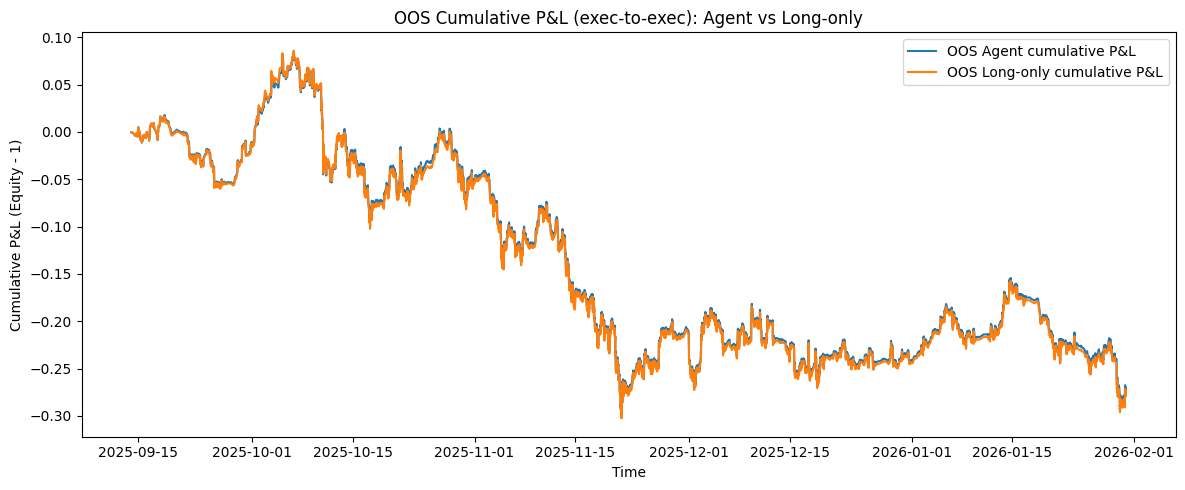

In [12]:
# ---- OOS evaluation pipeline (no retraining on OOS) ----
# This section only SELECTS/LOADS an already-trained checkpoint and evaluates on OOS.
# It does NOT call model.learn() and does NOT retrain on OOS.

# ---- 7A) Artifact paths ----
SB3_BEST_DIR = "./sb3_best"
BEST_MODEL_ZIP = os.path.join(SB3_BEST_DIR, "best_model.zip")
VECNORM_PATH = os.path.join(SB3_BEST_DIR, "vecnormalize.pkl")
FINAL_MODEL_PATH = os.path.join(SB3_BEST_DIR, "final_model.zip")

if (not os.path.exists(BEST_MODEL_ZIP)) and os.path.exists(FINAL_MODEL_PATH):
    BEST_MODEL_ZIP = FINAL_MODEL_PATH
    print("best_model.zip not found; using fallback checkpoint:", BEST_MODEL_ZIP)

print("Using SB3_BEST_DIR:", SB3_BEST_DIR)
print("Using BEST_MODEL_ZIP:", BEST_MODEL_ZIP)
print("Using VECNORM_PATH:", VECNORM_PATH)
print("Using FINAL_MODEL_PATH:", FINAL_MODEL_PATH)

# ---- 7B) Load OOS data ----
OOS_PATH = "DC_events_1min_from_2025-07-16.parquet"
OOS_OUTDIR = "./oos_outputs"
os.makedirs(OOS_OUTDIR, exist_ok=True)

oos_df = load_dc_events_for_rl(OOS_PATH)
print("\n=== OOS dataset ===")
print("Rows:", len(oos_df))
if len(oos_df):
    print("Time range:", oos_df["t_confirm"].min(), "->", oos_df["t_confirm"].max())


# ---- 7B.0) Optional: select OOS model from walk-forward folds (no OOS retraining) ----
USE_WF_SELECTED_MODEL_FOR_OOS = True
WF_OOS_SELECTION = "latest_test_end"
# selection: "latest_test_end" | "best_fold_final_equity" | "best_fold_avg_reward"
WF_OOS_RUN_DIR = WF_RUN_DIR if "WF_RUN_DIR" in locals() else ""
WF_OOS_FOLD_SUMMARY_CSV = os.path.join(WF_OOS_RUN_DIR, "walkforward_fold_summary.csv") if WF_OOS_RUN_DIR else ""

if USE_WF_SELECTED_MODEL_FOR_OOS:
    wf_summary = None
    if "wf_fold_summary" in locals() and isinstance(wf_fold_summary, pd.DataFrame) and len(wf_fold_summary):
        wf_summary = wf_fold_summary.copy()
        print("WF OOS selector: using in-memory wf_fold_summary.")
    elif WF_OOS_FOLD_SUMMARY_CSV and os.path.exists(WF_OOS_FOLD_SUMMARY_CSV):
        wf_summary = pd.read_csv(WF_OOS_FOLD_SUMMARY_CSV)
        print("WF OOS selector: loaded fold summary:", WF_OOS_FOLD_SUMMARY_CSV)
    else:
        raise FileNotFoundError(
            "WF OOS selector enabled, but walk-forward fold summary not found. "
            "Run walk-forward cell first or set WF_OOS_FOLD_SUMMARY_CSV."
        )

    if wf_summary is None or wf_summary.empty:
        raise RuntimeError("WF OOS selector found empty fold summary.")
    if "selected_model_path" not in wf_summary.columns:
        raise KeyError("walkforward fold summary missing 'selected_model_path'.")

    for _tc in ["train_start", "train_end", "val_start", "val_end", "test_start", "test_end"]:
        if _tc in wf_summary.columns:
            wf_summary[_tc] = pd.to_datetime(wf_summary[_tc], errors="coerce")

    if WF_OOS_SELECTION == "latest_test_end":
        if "test_end" in wf_summary.columns and wf_summary["test_end"].notna().any():
            sort_cols = ["test_end"] + (["fold_id"] if "fold_id" in wf_summary.columns else [])
            wf_sel = wf_summary.sort_values(sort_cols, ascending=False).iloc[0]
        elif "fold_id" in wf_summary.columns:
            wf_sel = wf_summary.sort_values("fold_id", ascending=False).iloc[0]
        else:
            wf_sel = wf_summary.iloc[-1]
    elif WF_OOS_SELECTION in ("best_fold_final_equity", "best_fold_avg_reward"):
        score_col = "fold_final_equity" if WF_OOS_SELECTION == "best_fold_final_equity" else "fold_avg_reward"
        if score_col not in wf_summary.columns:
            raise KeyError(f"walkforward fold summary missing '{score_col}' for WF_OOS_SELECTION={WF_OOS_SELECTION}")
        tmp = wf_summary.copy()
        tmp[score_col] = pd.to_numeric(tmp[score_col], errors="coerce")
        tmp = tmp.dropna(subset=[score_col])
        if tmp.empty:
            raise RuntimeError(f"No finite values in '{score_col}' for WF OOS selector.")
        sort_cols = [score_col] + (["test_end"] if "test_end" in tmp.columns else [])
        wf_sel = tmp.sort_values(sort_cols, ascending=False).iloc[0]
    else:
        raise ValueError(f"Unsupported WF_OOS_SELECTION: {WF_OOS_SELECTION}")

    wf_model_path = str(wf_sel["selected_model_path"])
    wf_vec_path = ""
    if "selected_vecnorm_path" in wf_summary.columns and pd.notna(wf_sel.get("selected_vecnorm_path", np.nan)):
        wf_vec_path = str(wf_sel["selected_vecnorm_path"])
    if not wf_vec_path:
        wf_vec_path = os.path.join(os.path.dirname(wf_model_path), "vecnormalize.pkl")

    if not os.path.exists(wf_model_path):
        raise FileNotFoundError(f"WF-selected model checkpoint not found: {wf_model_path}")
    if not os.path.exists(wf_vec_path):
        raise FileNotFoundError(f"WF-selected VecNormalize stats not found: {wf_vec_path}")

    SB3_BEST_DIR = os.path.dirname(wf_model_path)
    BEST_MODEL_ZIP = wf_model_path
    BEST_MODEL_PATH = BEST_MODEL_ZIP
    VECNORM_PATH = wf_vec_path
    FINAL_MODEL_PATH = os.path.join(SB3_BEST_DIR, "final_model.zip")

    print("\nWF-selected OOS model:")
    if "fold_id" in wf_summary.columns and pd.notna(wf_sel.get("fold_id", np.nan)):
        print("Selected fold_id:", int(wf_sel["fold_id"]))
    if "test_start" in wf_summary.columns and "test_end" in wf_summary.columns:
        print("Selected fold test window:", wf_sel.get("test_start", None), "->", wf_sel.get("test_end", None))
    print("Selection mode:", WF_OOS_SELECTION)
    print("Selected BEST_MODEL_ZIP:", BEST_MODEL_ZIP)
    print("Selected VECNORM_PATH:", VECNORM_PATH)

# ---- 7B.1) Optional cross-run selector ----
USE_CROSS_RUN_SELECTOR = False
CROSS_RUN_BASE_DIR = "./sb3_runs"
CROSS_RUN_RUN_GLOB = f"{RUN_GROUP}_*"
CROSS_RUN_EVAL_SPLIT = "val"   # "val" | "test" | "oos"
CROSS_RUN_SCORE_COL = "excess_equity"
CROSS_RUN_MAX_STEPS = None
CROSS_RUN_TOP_K_PRINT = 10
print("Selector run glob:", CROSS_RUN_RUN_GLOB)

if USE_CROSS_RUN_SELECTOR:
    if "evaluate_with_action_stats" not in locals():
        raise RuntimeError("evaluate_with_action_stats is not defined. Run earlier helper cells first.")

    from pathlib import Path

    def _selector_df(split_name: str):
        s = str(split_name).lower().strip()
        if s == "val":
            return val_df
        if s == "test":
            return test_df
        if s == "oos":
            return oos_df
        raise ValueError(f"Unsupported CROSS_RUN_EVAL_SPLIT: {split_name}")

    def _make_selector_env(df_):
        return DummyVecEnv([
            lambda: DCEventTradingEnv(
                df_,
                STATE_COLS_SAFE,
                reward_col=REWARD_COL,
                use_downside_penalty=USE_DOWNSIDE_PENALTY,
                pnl_scale=PNL_SCALE,
                downside_penalty=DOWNSIDE_PENALTY,
                use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
                roll_window_x=ROLL_WINDOW_X,
                roll_dd_threshold=ROLL_DD_THRESHOLD,
                roll_dd_penalty=ROLL_DD_PENALTY,
                roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
                use_hold_penalty=USE_HOLD_PENALTY,
                hold_penalty=HOLD_PENALTY,
                hold_signal_scale=HOLD_SIGNAL_SCALE,
        turnover_penalty=TURNOVER_PENALTY,
        use_active_pnl_reward=USE_ACTIVE_PNL_REWARD,
        benchmark_pos=BENCHMARK_POS,
        use_step_loss_liquidation=USE_STEP_LOSS_LIQUIDATION,
        step_loss_liquidation_pct=STEP_LOSS_LIQUIDATION_PCT,
        use_step_take_profit_liquidation=USE_STEP_TAKE_PROFIT_LIQUIDATION,
        step_take_profit_liquidation_pct=STEP_TAKE_PROFIT_LIQUIDATION_PCT,
        use_stop_tp_exec_lag_price=USE_STOP_TP_EXEC_LAG_PRICE,
        stop_tp_lag_price_col=STOP_TP_LAG_PRICE_COL,
            )
        ])

    eval_df_selector = _selector_df(CROSS_RUN_EVAL_SPLIT)
    run_root = Path(CROSS_RUN_BASE_DIR)
    run_dirs = sorted([d for d in run_root.glob(CROSS_RUN_RUN_GLOB) if d.is_dir()])

    if not run_dirs:
        raise FileNotFoundError(f"No run directories found in {run_root} matching {CROSS_RUN_RUN_GLOB}")

    rows = []
    skipped = []

    for run_dir in run_dirs:
        sb3_best_dir = run_dir / "sb3_best"
        vec_path = sb3_best_dir / "vecnormalize.pkl"
        best_path = sb3_best_dir / "best_model.zip"
        final_path = sb3_best_dir / "final_model.zip"

        model_path = best_path if best_path.exists() else (final_path if final_path.exists() else None)
        if (model_path is None) or (not vec_path.exists()):
            skipped.append((run_dir.name, "missing model and/or vecnormalize"))
            continue

        eval_env_i = None
        try:
            eval_env_i = _make_selector_env(eval_df_selector)
            eval_env_i = VecNormalize.load(str(vec_path), eval_env_i)
            eval_env_i.training = False
            eval_env_i.norm_reward = False

            model_i = PPO.load(str(model_path), env=eval_env_i, device=DEVICE)
            if (USE_LONG_BIAS_GATE or USE_CONFIDENCE_HOLD_GATE or USE_SHORT_CONFIDENCE_GATE):
                model_i = LongBiasModelWrapper(
                    model_i,
                    long_bias_enabled=bool(USE_LONG_BIAS_GATE),
                    hold_switch_margin=LONG_BIAS_HOLD_SWITCH_MARGIN,
                    hold_min_prob=LONG_BIAS_HOLD_MIN_PROB,
                    short_switch_margin=LONG_BIAS_SHORT_SWITCH_MARGIN,
                    short_min_prob=LONG_BIAS_SHORT_MIN_PROB,
                    confidence_hold_enabled=bool(USE_CONFIDENCE_HOLD_GATE),
                    confidence_hold_min_top_prob=float(CONF_HOLD_MIN_TOP_PROB),
                    confidence_hold_min_margin=float(CONF_HOLD_MIN_MARGIN),
                short_confidence_enabled=bool(USE_SHORT_CONFIDENCE_GATE),
                short_confidence_min_prob=float(SHORT_CONF_MIN_PROB),
                short_confidence_min_margin=float(SHORT_CONF_MIN_MARGIN),
                )

            rollout_i, _pa_i, overall_i = evaluate_with_action_stats(
                model_i,
                eval_env_i,
                deterministic=True,
                max_steps=CROSS_RUN_MAX_STEPS,
            )

            if "tradable_flag" in rollout_i.columns:
                lr = pd.to_numeric(rollout_i.loc[rollout_i["tradable_flag"], "ret_next_exec_raw"], errors="coerce").to_numpy(dtype=float)
            else:
                lr = pd.to_numeric(rollout_i["ret_next_exec_raw"], errors="coerce").to_numpy(dtype=float)
            lr = lr[np.isfinite(lr)]

            long_equity = float(np.prod(1.0 + lr)) if lr.size else np.nan
            final_equity = float(overall_i.get("final_equity", np.nan))
            avg_reward = float(overall_i.get("avg_reward", np.nan))
            excess_equity = (final_equity - long_equity) if (np.isfinite(final_equity) and np.isfinite(long_equity)) else np.nan

            score_map = {
                "excess_equity": excess_equity,
                "final_equity": final_equity,
                "avg_reward": avg_reward,
            }
            score = float(score_map.get(CROSS_RUN_SCORE_COL, np.nan))

            rows.append({
                "run_name": run_dir.name,
                "sb3_best_dir": str(sb3_best_dir),
                "model_path": str(model_path),
                "vecnorm_path": str(vec_path),
                "score": score,
                "final_equity": final_equity,
                "long_equity": long_equity,
                "excess_equity": excess_equity,
                "avg_reward": avg_reward,
                "n_steps": int(overall_i.get("n_steps", 0)),
            })
        except Exception as e:
            skipped.append((run_dir.name, str(e)))
        finally:
            if eval_env_i is not None:
                eval_env_i.close()

    if not rows:
        msg = "No valid runs produced selector scores."
        if skipped:
            msg += f" Skipped {len(skipped)} runs; first error: {skipped[0]}"
        raise RuntimeError(msg)

    leaderboard = pd.DataFrame(rows)
    leaderboard = leaderboard.replace([np.inf, -np.inf], np.nan)
    leaderboard = leaderboard.dropna(subset=["score"]).sort_values("score", ascending=False).reset_index(drop=True)

    if leaderboard.empty:
        raise RuntimeError("All selector scores are NaN/inf; adjust CROSS_RUN_SCORE_COL or check run artifacts.")

    leaderboard_path = os.path.join(OOS_OUTDIR, f"cross_run_leaderboard_{CROSS_RUN_EVAL_SPLIT}.csv")
    leaderboard.to_csv(leaderboard_path, index=False)

    print(f"\nCross-run leaderboard ({CROSS_RUN_EVAL_SPLIT}, score={CROSS_RUN_SCORE_COL})")
    print(leaderboard.head(int(CROSS_RUN_TOP_K_PRINT)).to_string(index=False))
    print("Saved leaderboard to:", leaderboard_path)
    if skipped:
        print(f"Skipped runs: {len(skipped)}")

    best_row = leaderboard.iloc[0]
    SELECTED_RUN_NAME = str(best_row["run_name"])
    SB3_BEST_DIR = str(best_row["sb3_best_dir"])
    BEST_MODEL_ZIP = str(best_row["model_path"])
    VECNORM_PATH = str(best_row["vecnorm_path"])
    FINAL_MODEL_PATH = os.path.join(SB3_BEST_DIR, "final_model.zip")

    print("\nSelected run:", SELECTED_RUN_NAME)
    print("Selected BEST_MODEL_ZIP:", BEST_MODEL_ZIP)
    print("Selected VECNORM_PATH:", VECNORM_PATH)

# ---- 7C) Build OOS env ----
def make_oos_env(df_):
    return DCEventTradingEnv(
        df_,
        STATE_COLS_SAFE,
        reward_col=REWARD_COL,
        use_downside_penalty=USE_DOWNSIDE_PENALTY,
        pnl_scale=PNL_SCALE,
        downside_penalty=DOWNSIDE_PENALTY,
        use_rolling_dd_penalty=USE_ROLLING_DD_PENALTY,
        roll_window_x=ROLL_WINDOW_X,
        roll_dd_threshold=ROLL_DD_THRESHOLD,
        roll_dd_penalty=ROLL_DD_PENALTY,
        roll_dd_penalty_pow=ROLL_DD_PENALTY_POW,
        use_hold_penalty=USE_HOLD_PENALTY,
        hold_penalty=HOLD_PENALTY,
        hold_signal_scale=HOLD_SIGNAL_SCALE,
        turnover_penalty=TURNOVER_PENALTY,
        use_active_pnl_reward=USE_ACTIVE_PNL_REWARD,
        benchmark_pos=BENCHMARK_POS,
        use_step_loss_liquidation=USE_STEP_LOSS_LIQUIDATION,
        step_loss_liquidation_pct=STEP_LOSS_LIQUIDATION_PCT,
        use_step_take_profit_liquidation=USE_STEP_TAKE_PROFIT_LIQUIDATION,
        step_take_profit_liquidation_pct=STEP_TAKE_PROFIT_LIQUIDATION_PCT,
        use_stop_tp_exec_lag_price=USE_STOP_TP_EXEC_LAG_PRICE,
        stop_tp_lag_price_col=STOP_TP_LAG_PRICE_COL,
    )

oos_env = DummyVecEnv([lambda: make_oos_env(oos_df)])

# ---- 7D) Load VecNormalize stats + attach to OOS env ----
if not os.path.exists(VECNORM_PATH):
    raise FileNotFoundError(f"VecNormalize stats not found: {VECNORM_PATH}")
if not os.path.exists(BEST_MODEL_ZIP):
    if model is not None:
        print(f"Model checkpoint not found on disk ({BEST_MODEL_ZIP}); falling back to in-memory model.")
    else:
        raise FileNotFoundError(f"Model checkpoint not found: {BEST_MODEL_ZIP}")

oos_env = VecNormalize.load(VECNORM_PATH, oos_env)
oos_env.training = False
oos_env.norm_reward = False

print("\nLoaded VecNormalize stats from:", VECNORM_PATH)

# ---- 7E) Load model checkpoint ----
if os.path.exists(BEST_MODEL_ZIP):
    oos_model = PPO.load(BEST_MODEL_ZIP, env=oos_env, device=DEVICE)
    print("Loaded model from:", BEST_MODEL_ZIP)
elif model is not None:
    oos_model = model
    print("Using in-memory model from current kernel.")
else:
    raise FileNotFoundError(f"No model available for OOS evaluation. Missing checkpoint: {BEST_MODEL_ZIP}")

if (USE_LONG_BIAS_GATE or USE_CONFIDENCE_HOLD_GATE or USE_SHORT_CONFIDENCE_GATE) and (not isinstance(oos_model, LongBiasModelWrapper)):
    _lb_hold_switch = float(LONG_BIAS_HOLD_SWITCH_MARGIN)
    _lb_hold_min = float(LONG_BIAS_HOLD_MIN_PROB)
    _lb_short_switch = float(LONG_BIAS_SHORT_SWITCH_MARGIN)
    _lb_short_min = float(LONG_BIAS_SHORT_MIN_PROB)

    oos_model = LongBiasModelWrapper(
        oos_model,
        long_bias_enabled=bool(USE_LONG_BIAS_GATE),
        hold_switch_margin=_lb_hold_switch,
        hold_min_prob=_lb_hold_min,
        short_switch_margin=_lb_short_switch,
        short_min_prob=_lb_short_min,
    confidence_hold_enabled=bool(USE_CONFIDENCE_HOLD_GATE),
    confidence_hold_min_top_prob=float(CONF_HOLD_MIN_TOP_PROB),
    confidence_hold_min_margin=float(CONF_HOLD_MIN_MARGIN),
    short_confidence_enabled=bool(USE_SHORT_CONFIDENCE_GATE),
    short_confidence_min_prob=float(SHORT_CONF_MIN_PROB),
    short_confidence_min_margin=float(SHORT_CONF_MIN_MARGIN),
    )

print("OOS model ready.")

# ---- 7F) Full-period OOS evaluation (deterministic) ----
oos_rollout, oos_per_action, oos_overall = evaluate_with_action_stats(
    oos_model, oos_env, deterministic=True
)

print("\n=== OOS Overall (deterministic) ===")
for k, v in oos_overall.items():
    print(f"{k}: {v}")

print("\n=== OOS Per-action stats (deterministic) ===")
print(oos_per_action)

# ---- 7H) Build OOS execution log (exec-to-exec) ----
_oos_exec = oos_df.reset_index(drop=True).copy()

if "tradable_flag" in oos_rollout.columns:
    oos_trad = oos_rollout[oos_rollout["tradable_flag"]].copy().reset_index(drop=True)
else:
    oos_trad = oos_rollout.copy().reset_index(drop=True)

T_trad = len(oos_trad)
T_exec = max(0, T_trad - 1)

if T_exec == 0:
    print("\n[OOS Execution log] Not enough tradable points to form entry/exit intervals.")
else:
    entry_idx = oos_trad["idx"].iloc[:T_exec].astype(int).to_numpy()
    exit_idx = oos_trad["idx"].iloc[1:T_exec+1].astype(int).to_numpy()

    decision_time = pd.to_datetime(_oos_exec.loc[entry_idx, "t_confirm"].values)

    if "t_execute" in _oos_exec.columns:
        entry_time = pd.to_datetime(_oos_exec.loc[entry_idx, "t_execute"].values)
        exit_time = pd.to_datetime(_oos_exec.loc[exit_idx,  "t_execute"].values)
    else:
        entry_time = decision_time
        exit_time = pd.to_datetime(_oos_exec.loc[exit_idx, "t_confirm"].values)

    if "p_t" in _oos_exec.columns:
        decision_price = pd.to_numeric(_oos_exec.loc[entry_idx, "p_t"], errors="coerce").to_numpy(dtype=float)
    else:
        decision_price = np.full(len(entry_idx), np.nan, dtype=float)

    if "p_t_execute" in _oos_exec.columns:
        entry_price = pd.to_numeric(_oos_exec.loc[entry_idx, "p_t_execute"], errors="coerce").to_numpy(dtype=float)
        exit_price = pd.to_numeric(_oos_exec.loc[exit_idx,  "p_t_execute"], errors="coerce").to_numpy(dtype=float)
    else:
        entry_price = pd.to_numeric(_oos_exec.loc[entry_idx, "p_t"], errors="coerce").to_numpy(dtype=float)
        exit_price = pd.to_numeric(_oos_exec.loc[exit_idx,  "p_t"], errors="coerce").to_numpy(dtype=float)

    pos_vec = pd.to_numeric(oos_trad["pos"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float)
    auto_liq_vec = oos_trad["auto_liquidated"].iloc[:T_exec].astype(bool).to_numpy() if "auto_liquidated" in oos_trad.columns else np.zeros(T_exec, dtype=bool)
    auto_liq_reason_vec = oos_trad["auto_liq_reason"].iloc[:T_exec].astype(str).to_numpy() if "auto_liq_reason" in oos_trad.columns else np.array(["" for _ in range(T_exec)], dtype=object)
    auto_liq_open_ret_vec = pd.to_numeric(oos_trad["auto_liq_open_trade_ret"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float) if "auto_liq_open_trade_ret" in oos_trad.columns else np.full(T_exec, np.nan, dtype=float)
    auto_liq_pnl_adjust_vec = pd.to_numeric(oos_trad["auto_liq_pnl_adjust"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float) if "auto_liq_pnl_adjust" in oos_trad.columns else np.zeros(T_exec, dtype=float)
    stop_tp_exec_price_vec = pd.to_numeric(oos_trad["stop_tp_exec_price"].iloc[:T_exec], errors="coerce").to_numpy(dtype=float) if "stop_tp_exec_price" in oos_trad.columns else np.full(T_exec, np.nan, dtype=float)

    valid = np.isfinite(entry_price) & np.isfinite(exit_price) & np.isfinite(pos_vec) & (entry_price != 0.0)
    entry_idx = entry_idx[valid]
    exit_idx = exit_idx[valid]
    decision_time = decision_time[valid]
    entry_time = entry_time[valid]
    exit_time = exit_time[valid]
    decision_price = decision_price[valid]
    entry_price = entry_price[valid]
    exit_price = exit_price[valid]
    pos_vec = pos_vec[valid]
    auto_liq_vec = auto_liq_vec[valid]
    auto_liq_reason_vec = auto_liq_reason_vec[valid]
    auto_liq_open_ret_vec = auto_liq_open_ret_vec[valid]
    auto_liq_pnl_adjust_vec = auto_liq_pnl_adjust_vec[valid]
    stop_tp_exec_price_vec = stop_tp_exec_price_vec[valid]

    ret_interval = (exit_price / entry_price) - 1.0
    pnl_frac = pos_vec * ret_interval + auto_liq_pnl_adjust_vec

    equity_end = (1.0 + pd.Series(pnl_frac)).cumprod().to_numpy(dtype=float)
    equity_start = np.r_[1.0, equity_end[:-1]]
    pnl_interval = equity_end - equity_start
    pnl_curve = equity_end - 1.0

    lag_minutes = ((entry_time - decision_time) / np.timedelta64(1, "m")).astype(float)

    oos_exec_log = pd.DataFrame({
        "k": np.arange(len(ret_interval), dtype=int),
        "idx_entry": entry_idx,
        "idx_exit": exit_idx,
        "decision_time": decision_time,
        "entry_time": entry_time,
        "exit_time": exit_time,
        "lag_minutes": lag_minutes,
        "position": pos_vec,
        "auto_liquidated": auto_liq_vec,
        "auto_liq_reason": auto_liq_reason_vec,
        "auto_liq_open_trade_ret": auto_liq_open_ret_vec,
        "auto_liq_pnl_adjust": auto_liq_pnl_adjust_vec,
        "stop_tp_exec_price": stop_tp_exec_price_vec,
        "decision_price": decision_price,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "ret_interval": ret_interval,
        "pnl_frac": pnl_frac,
        "equity_start": equity_start,
        "equity_end": equity_end,
        "equity": equity_end,
        "pnl_interval": pnl_interval,
        "pnl": pnl_curve,
        "action": oos_trad["action"].iloc[:len(ret_interval)].values,
        "action_name": oos_trad["action_name"].iloc[:len(ret_interval)].values,
    })

    print("\n=== OOS Execution log (head) ===")
    print(oos_exec_log.head(10))

    # ---- 7I) OOS long-only baseline ----
    long_rewards = ret_interval.copy()
    long_equity_curve = (1.0 + pd.Series(long_rewards)).cumprod().reset_index(drop=True)
    long_pnl_curve = long_equity_curve - 1.0

    if "auto_liquidated" in oos_exec_log.columns:
        _n_liq = int(pd.to_numeric(oos_exec_log["auto_liquidated"], errors="coerce").fillna(0).astype(int).sum())
        _n_sl = int((oos_exec_log["auto_liq_reason"] == "step_loss").sum()) if "auto_liq_reason" in oos_exec_log.columns else 0
        _n_tp = int((oos_exec_log["auto_liq_reason"] == "step_take_profit").sum()) if "auto_liq_reason" in oos_exec_log.columns else 0
        print(f"Auto-liquidations: {_n_liq} (stop_loss={_n_sl}, take_profit={_n_tp})")

    print("\n=== OOS Baseline: LONG-only (exec-to-exec) ===")
    print("Intervals:", int(len(long_rewards)))
    print("Toy equity (start=1):", float(long_equity_curve.iloc[-1]) if len(long_equity_curve) else np.nan)
    print("Win rate:", float(np.mean(long_rewards > 0)) if len(long_rewards) else np.nan)

    # ---- 7J) Plot: OOS agent vs long-only ----
    x = pd.to_datetime(oos_exec_log["entry_time"].values)

    plt.figure(figsize=(12, 5))
    plt.plot(x, oos_exec_log["pnl"].values, label="OOS Agent cumulative P&L")
    plt.plot(x, long_pnl_curve.values, label="OOS Long-only cumulative P&L")

    if "auto_liq_reason" in oos_exec_log.columns:
        _sl = oos_exec_log["auto_liq_reason"].astype(str).eq("step_loss")
        _tp = oos_exec_log["auto_liq_reason"].astype(str).eq("step_take_profit")
        if bool(_sl.any()):
            plt.scatter(
                x[_sl],
                oos_exec_log.loc[_sl, "pnl"].astype(float),
                marker="x",
                s=55,
                color="tab:red",
                label="Stop-loss execution",
                zorder=6,
            )
        if bool(_tp.any()):
            plt.scatter(
                x[_tp],
                oos_exec_log.loc[_tp, "pnl"].astype(float),
                marker="o",
                s=45,
                color="tab:green",
                label="Take-profit execution",
                zorder=6,
            )

    plt.title("OOS Cumulative P&L (exec-to-exec): Agent vs Long-only")
    plt.xlabel("Time")
    plt.ylabel("Cumulative P&L (Equity - 1)")
    plt.legend()
    plt.tight_layout()
    plt.show()
